In [1]:
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression  
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from scipy import interpolate
import re
from abc import ABC, abstractmethod
from sklearn.base import clone
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import TimeSeriesSplit, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, make_scorer
# 図のスタイル設定
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

import pickle
import japanize_matplotlib
from scipy.stats import pearsonr

import joblib
import plotly
# ▼▼▼ これを追加 ▼▼▼

In [2]:
import importlib
import my_module4 as mm  # ★ 作成したモジュールを読み込む
# モジュールの変更を反映させる
importlib.reload(mm)
plt.rcParams['font.family'] = 'MS Gothic'

In [3]:

# # より良い中間表現
# df_all['前後接触バランス'] = df_all['接触 %_1'] - df_all['接触 %_2']
# df_all['前後荷重バランス'] = df_all['荷重(N)_1'] - df_all['荷重(N)_2']
# df_all['ねじれ'] = df_all['圧力中心列_1'] - df_all['圧力中心列_2']
# df_all['Mx'] = df_all['荷重(N)_1'] * df_all['圧力中心列_1'] + df_all['荷重(N)_2'] * df_all['圧力中心列_2']
# df_all['My'] = df_all['荷重(N)_1'] * df_all['圧力中心行_1'] - df_all['荷重(N)_2'] * df_all['圧力中心行_2']
# df_all['Mx_norm'] = (df_all['荷重(N)_1'] * df_all['圧力中心列_1'] + df_all['荷重(N)_2'] * df_all['圧力中心列_2']) / (df_all['荷重(N)_1']+df_all['荷重(N)_2'] )
# df_all['My_norm'] = (df_all['荷重(N)_1'] * df_all['圧力中心行_1'] - df_all['荷重(N)_2'] * df_all['圧力中心行_2']) / (df_all['荷重(N)_1']+df_all['荷重(N)_2'] )
# df_all['全身_圧力中心行'] = (df_all['荷重(N)_1'] * df_all['圧力中心行_1'] + df_all['荷重(N)_2'] * df_all['圧力中心行_2']) / (df_all['荷重(N)_1']+df_all['荷重(N)_2'])
# N = 60
# eps = 1e-8
# base = df_all.groupby('subject_id')['圧力中心行_2'].transform(lambda s: s.iloc[:N].mean())
# df_all['座面_前後シフト'] = df_all['圧力中心行_2'] - base
# base = df_all.groupby('subject_id')['圧力中心行_2'].transform(lambda s: s.iloc[:N].mean())
# df_all['座面_前後モーメント'] = df_all['荷重(N)_2'] * (df_all['圧力中心行_2'] - base)
# base = df_all.groupby('subject_id')['圧力中心行_2'].transform(lambda s: s.iloc[:N].mean())
# df_all['座面_前後モーメント_norm'] = (df_all['荷重(N)_2'] * (df_all['圧力中心行_2'] - base)) / (df_all['荷重(N)_2'] + eps)
# # ほぼ (row2-base) だけど、荷重が小さい区間の暴れを抑えられる
# # timeが等間隔なら diff() でOK。等間隔でないなら / dt を入れる。
# base = df_all.groupby('subject_id')['圧力中心行_2'].transform(lambda s: s.iloc[:N].mean())
# shift = df_all['圧力中心行_2'] - base
# df_all['座面_前後速度'] = shift.groupby(df_all['subject_id']).diff().fillna(0)
# df_all['前後圧力バランス'] = df_all['平均圧力_1'] - df_all['平均圧力_2']

In [8]:

with open(r"C:\Users\youli\Desktop\code\20251118_COPモドキ\20251214home\modelA_df_proc.pkl", "rb") as f:
    df_all = pickle.load(f)

df_all['W_absolute'] = df_all['W']


# df_all = df_all[~df_all['subject_id'].isin([12, 20,17,24,25,26,27])].copy()
# df_all = df_all[~df_all['subject_id'].isin([19,20,24,25,26,27])].copy()
df_all = df_all[df_all['subject_id'].isin([12,13,14,16,17,18,21,25])].copy()
# df_all = df_all[df_all['subject_id'].isin([13,14,16,17,21,12,18])].copy()
print('使用subject : ', df_all.subject_id.unique())
# ==========================================
# 1. データ準備 (既存の DataFrame を使用)
# ==========================================

mock_sensor_cols = ['subject_id',
    'F1', 'F2', 'F3', 'F4', 'steer', 'pedal', 'W', 
    'F1_fnorm', 'F2_fnorm', 'F3_fnorm', 'F4_fnorm',
    'COP_X_phys', 'COP_Y_phys', 'phys_pitch', 'phys_roll', 'phys_torsion',
    'COP_radius', 'COP_angle', 'op_magnitude', 'interact_steer_pedal',
    'steer_COPx', 'steer_COPy', 'pedal_COPx', 'pedal_COPy',
    'COP_X_phys_vel', 'COP_Y_phys_vel', 'W_vel', 'phys_pitch_vel',
    'phys_roll_vel', 'steer_vel', 'pedal_vel', 'interact_steer_vel_COP',
    'F1_hysteresis', 'F2_hysteresis', 'F3_hysteresis', 'F4_hysteresis',
    'W_hysteresis', 'COP_X_phys_hysteresis', 'COP_Y_phys_hysteresis',
    'Interaction_COPX_W', 'Interaction_COPY_W', 
    'W_Power', 'COP_X_phys_Power', 'COP_Y_phys_Power',
    'COP_X_phys_vel_integ', 'COP_X_phys_vel_ma30', 
    'COP_Y_phys_vel_integ', 'COP_Y_phys_vel_ma30', 
    'W_vel_integ', 'W_vel_ma30',
    'phys_pitch_vel_integ', 'phys_pitch_vel_ma30', 
    'phys_roll_vel_integ', 'phys_roll_vel_ma30',
    'F1_init', 'F2_init', 'F3_init', 'F4_init',
    'W_init', 'LR_balance_init', 'FB_balance_init','W_absolute'
]

target_features_A = [
    '圧力中心行_1', 
    '圧力中心行_2', 
    #   '荷重(N)_1', '荷重(N)_2', 
    # '平均圧力_2', 
    # '平均圧力_1'
    # '接触 %_1',
    # '圧力中心列_1', 
    # '圧力中心列_2', 
]

# データ抽出
available_cols = df_all.columns.tolist()
X_cols = [c for c in mock_sensor_cols if c in available_cols]
Y_cols = [c for c in target_features_A if c in available_cols]

df_raw = df_all[X_cols + Y_cols].dropna()
X_raw = df_raw[X_cols]
y_raw = df_raw[Y_cols]

print(f"✅ Data loaded: {len(df_raw)} samples")
print(f"   Features: {len(X_cols)-1} (excluding subject_id)")
print(f"   Targets: {len(Y_cols)}")
print(f"   Subjects: {sorted(X_raw['subject_id'].unique())}")

# ==========================================
# 2. 設定 (Configs)
# ==========================================
PREPROCESSING_CONFIGS = {
    'standard_pls':     {'scale_x': True,  'n_components': 14}, 
    'hierarchical_pls': {'scale_x': False, 'n_components':14},     
    'pls_ridge':        {'scale_x': True,  'n_components':14,'scale_state2':False}, 
    'hierarchical_hybrid': {'scale_x': False, 'n_components':14,'scale_stage2': False}, 
}

# ==========================================
# 特徴量の定義
# ==========================================
# 1. 静的特徴量 (Stage 2: Ridge用 / Hierarchical用) # ※ これらは初期値引きしない！
STATIC_FEATURES = [
    'W_init', 'W_absolute',
    'F1_init', 'F2_init', 'F3_init', 'F4_init',
    'LR_balance_init', 'FB_balance_init',
    'phys_pitch_init', 'phys_roll_init', 'phys_torsion_init'
        'COP_X_phys_init', 'COP_Y_phys_init'
]
# 2. 初期値引きしない動的特徴量 (速度など) # ※ SubjectAwareInitialBiasSubtractor で除外対象にする判定に使う
NO_BIAS_COLS = [
    # 速度系
    'COP_X_phys_vel', 'COP_Y_phys_vel', 'W_vel', 
    'phys_pitch_vel', 'phys_roll_vel',
    'steer_vel', 'pedal_vel',
    'interact_steer_vel_COP',
    # ヒステリシス系
    'F1_hysteresis', 'F2_hysteresis', 'F3_hysteresis', 'F4_hysteresis',
    'W_hysteresis', 'COP_X_phys_hysteresis', 'COP_Y_phys_hysteresis',
    # Power系
    'W_Power', 'COP_X_phys_Power', 'COP_Y_phys_Power',
]
# 初期値引き（Bias Subtraction）を除外するキーワードの定義
# これらが列名に含まれている場合、その列は「初期値を引かずそのまま」モデルに入力されます
SKIP_BIAS_KEYWORDS = [
    'subject_id',   # 必須: ID列
    '_init',        # 静的特徴量 (W_init, F1_initなど)
    '_vel',         # 速度・微分系 (COP_X_phys_velなど)
    '_hysteresis',  # ヒステリシス系
    '_CLR',         # 対数比 (正規化済みのため不要)
    '_Power',        # パワー系 (速度を含むためゼロ中心)
    '_absolute'
]

# ダミーの前処理実行
comparator_temp = mm.ModelComparator(
    [mm.HierarchicalPLSStrategy({'scale_x': False, 'n_components': 10})],
    smooth_y=True, 
    skip_bias_cols=SKIP_BIAS_KEYWORDS
)
X_proc_temp = comparator_temp.preprocess_common(X_raw)

# すべての _init 列を取得
STATIC_FEATURES_EXTENDED = [col for col in X_proc_temp.columns if '_init' in col]

print(f"\n✅ Found {len(STATIC_FEATURES_EXTENDED)} extended static features:")
for i, feat in enumerate(STATIC_FEATURES_EXTENDED):
    print(f"   {i+1}. {feat}")


# ==========================================
# 3. 戦略の定義 (ここをいじるだけで実験が変わる！)
# ==========================================
strategies = [
    mm.StandardPLSStrategy(
        config=PREPROCESSING_CONFIGS['standard_pls'], 
    ),
    
    # mm.HierarchicalPLSStrategy(
    #     config=PREPROCESSING_CONFIGS['hierarchical_pls'], 
    # ),
    
    mm.StackingPLS2RidgeStrategy(
        config=PREPROCESSING_CONFIGS['pls_ridge'],
        ridge_alpha=1.0, 
        static_cols=STATIC_FEATURES
    ),

    mm.HierarchicalRidgeHybridStrategy(
        config=PREPROCESSING_CONFIGS['hierarchical_hybrid'],
        static_cols=STATIC_FEATURES
    ),

    mm.HierarchicalRidgeHybridPlusOffset(
        config=PREPROCESSING_CONFIGS['hierarchical_hybrid'],
        static_cols=STATIC_FEATURES_EXTENDED  # RFは特徴量が多くても頑健なのでEXTENDEDを使う
    ),

    # # --- ★本命: アンサンブル ---
    # mm.EnsembleHybridStrategy(
    #     config=PREPROCESSING_CONFIGS['hierarchical_hybrid'],
    #     static_cols=STATIC_FEATURES_EXTENDED,
    #     ridge_alpha=1.0  # Ridgeの強さ (必要に応じて10.0などに調整)
    # )

    #  (Offsetのみ予測)
    mm.HierarchicalPLSStrategyZeroShotOffsetOnly(
        name="Zero-shot (Offset Only)",
        config=PREPROCESSING_CONFIGS['hierarchical_pls'],
        static_features_cols=STATIC_FEATURES_EXTENDED,
        ridge_alpha=1.0
    ),

    mm.GlobalPLSPlusOffsetStrategy(
        config=PREPROCESSING_CONFIGS['standard_pls'], # standardの設定を使用
        static_cols=STATIC_FEATURES_EXTENDED
    )
]

# ==========================================
# 4. 実行 & 比較
# ==========================================

# comparator = mm.ModelComparator(strategies,smooth_y=True,skip_bias_cols=SKIP_BIAS_KEYWORDS)

# results = comparator.run_comparison(
#     X_raw, 
#     y_raw, 
#     target_col=target_features_A, 
#     holdout_subject_id=14
# )

# # ==========================================
# # 5. 結果表示
# # ==========================================
# print("\n🏆 Final Ranking:")
# print(results.sort_values('R2', ascending=False)[['Model', 'R2', 'RMSE']])



使用subject :  [12 13 14 16 17 18 21 25]
✅ Data loaded: 64501 samples
   Features: 45 (excluding subject_id)
   Targets: 2
   Subjects: [np.int64(12), np.int64(13), np.int64(14), np.int64(16), np.int64(17), np.int64(18), np.int64(21), np.int64(25)]
   Running Common Preprocessing (X)...

✅ Found 45 extended static features:
   1. F1_init
   2. F2_init
   3. F3_init
   4. F4_init
   5. steer_init
   6. pedal_init
   7. W_init
   8. F1_fnorm_init
   9. F2_fnorm_init
   10. F3_fnorm_init
   11. F4_fnorm_init
   12. COP_X_phys_init
   13. COP_Y_phys_init
   14. phys_pitch_init
   15. phys_roll_init
   16. phys_torsion_init
   17. COP_radius_init
   18. COP_angle_init
   19. op_magnitude_init
   20. interact_steer_pedal_init
   21. steer_COPx_init
   22. steer_COPy_init
   23. pedal_COPx_init
   24. pedal_COPy_init
   25. COP_X_phys_vel_init
   26. COP_Y_phys_vel_init
   27. W_vel_init
   28. phys_pitch_vel_init
   29. phys_roll_vel_init
   30. steer_vel_init
   31. pedal_vel_init
   32. inte


🎨 Starting Full Visualization Report for: 圧力中心行_1
   Running Common Preprocessing (X)...
   ✨ Smoothing Target Variable: 圧力中心行_1
⚙️ Visualizer: Re-fitting models for target '圧力中心行_1'...
   🏃 Training 5. Hybrid + RF Offset...
      ✅ Offset Residual Corrector Trained (R2=0.488)
   🏃 Training Zero-shot (Offset Only) (Offset Only)...
   🌲 Training Random Forest for Offset prediction...
   🏃 Training 8. Global PLS + RF Offset...

📊 [1/5] Generating Time Series Grid...


C:\Users\youli\AppData\Local\Temp\ipykernel_5088\3936075092.py:85: UserWarning: Glyph 12304 (\N{LEFT BLACK LENTICULAR BRACKET}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_5088\3936075092.py:85: UserWarning: Glyph 12305 (\N{RIGHT BLACK LENTICULAR BRACKET}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\youli\Desktop\code\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9312 (\N{CIRCLED DIGIT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\youli\Desktop\code\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22311 (\N{CJK UNIFIED IDEOGRAPH-5727}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\youli\Desktop\code\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\youli\Desk

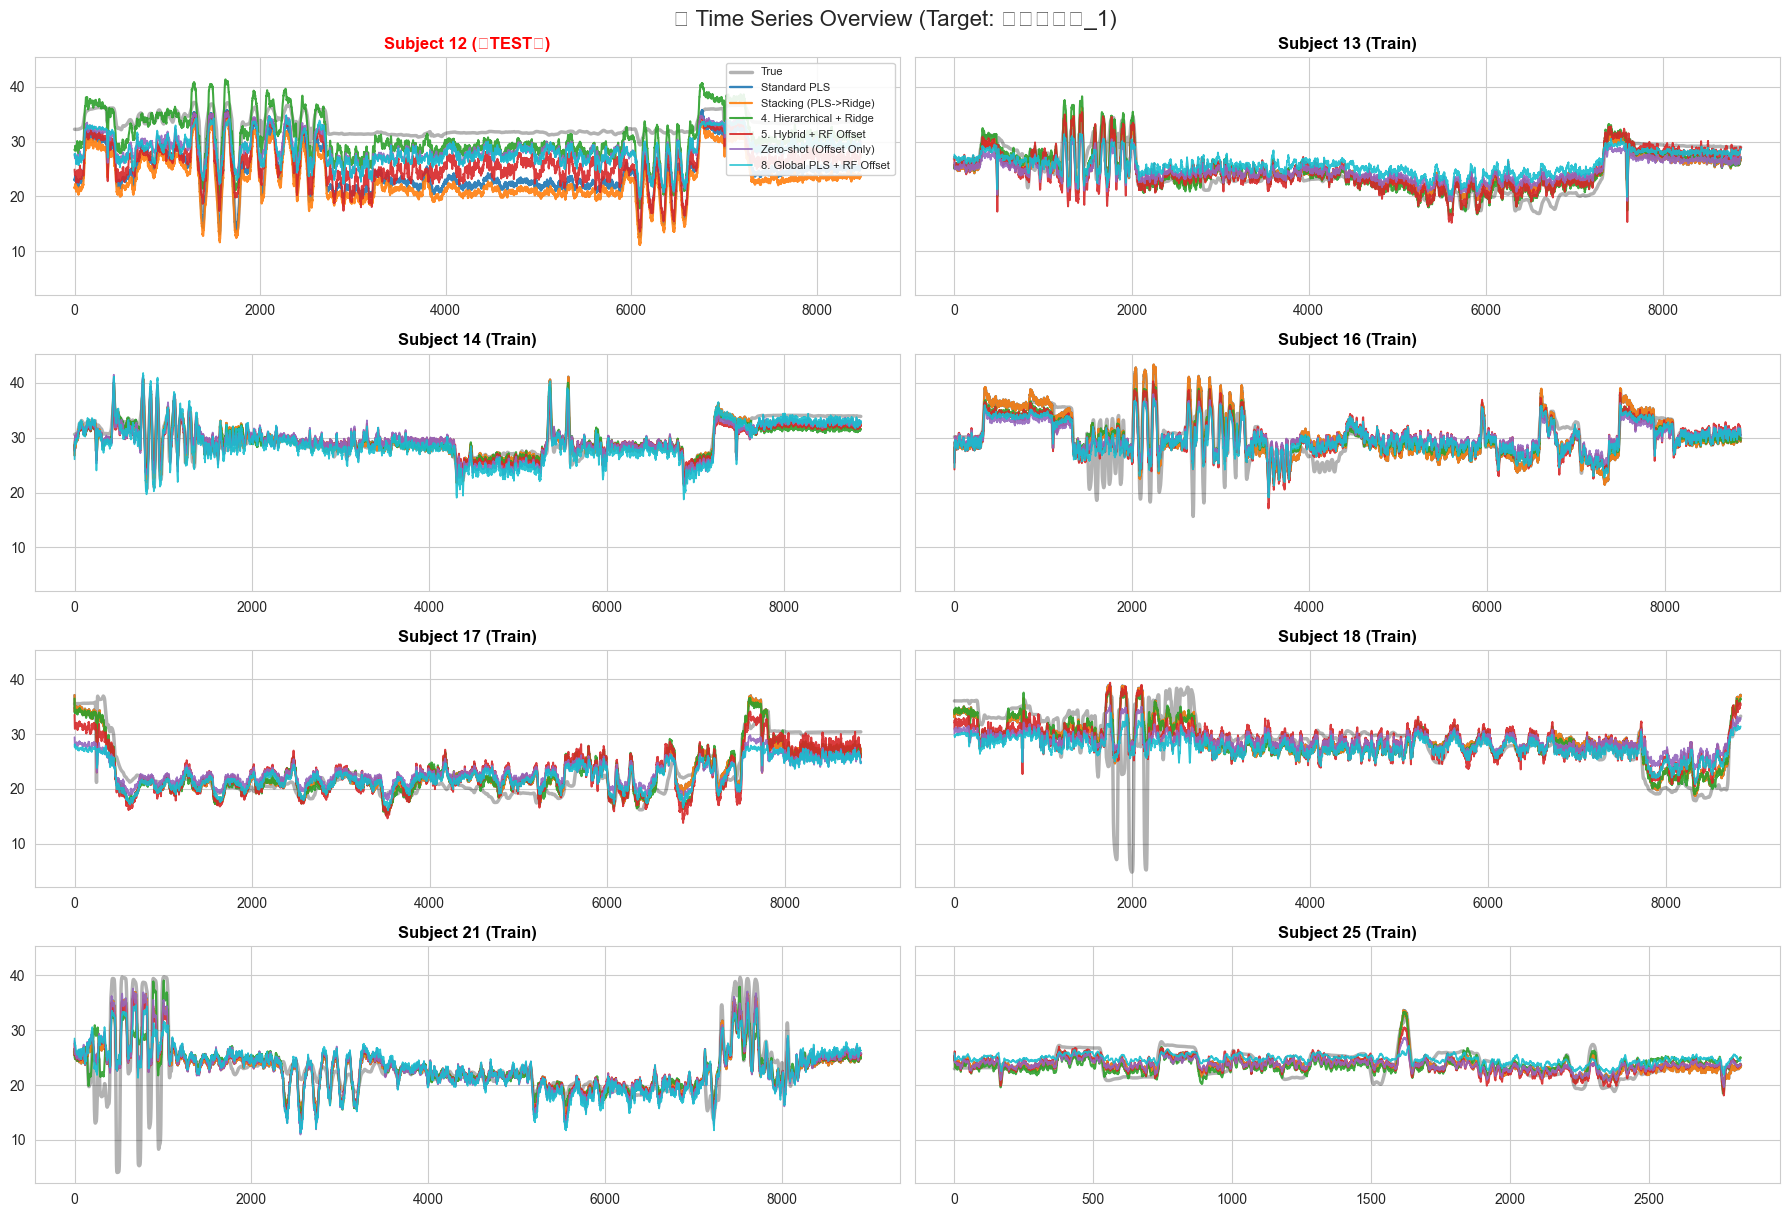

📊 [2/5] Generating Scatter Plots...


c:\Users\youli\Desktop\code\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9313 (\N{CIRCLED DIGIT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\youli\Desktop\code\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22311 (\N{CJK UNIFIED IDEOGRAPH-5727}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\youli\Desktop\code\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\youli\Desktop\code\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\youli\Desktop\code\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24515 (\N{CJK UNIFIED IDEOGRAPH-5FC3}) missing from font(s)

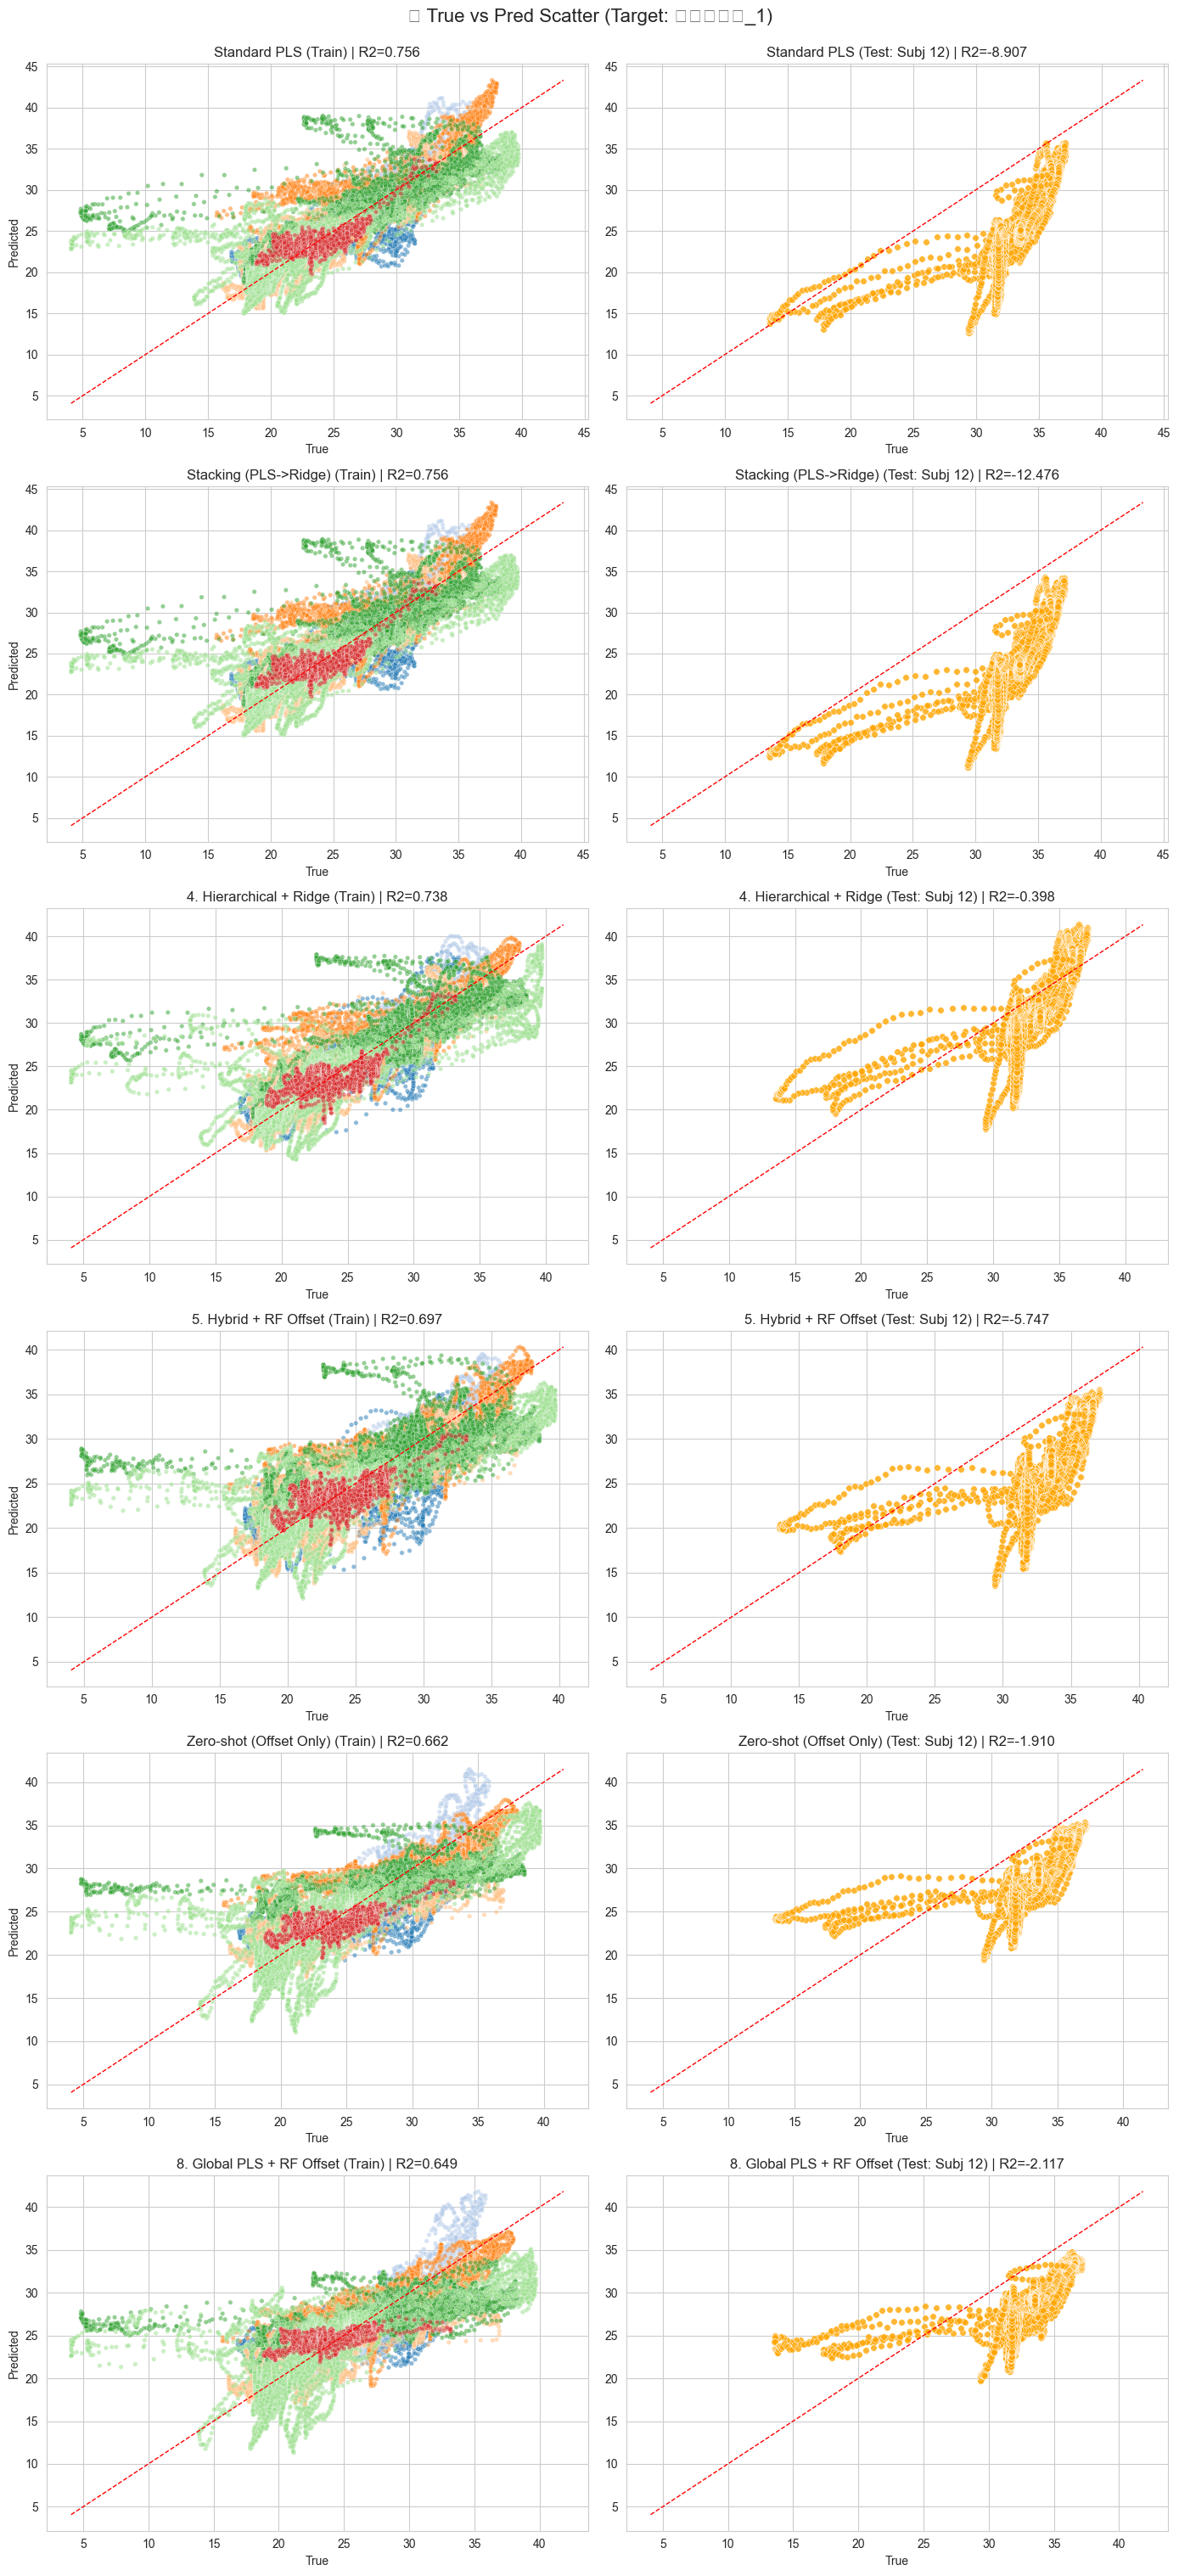

📊 [3/5] Generating Subject-wise R2 Comparison...


C:\Users\youli\AppData\Local\Temp\ipykernel_5088\3936075092.py:165: UserWarning: Glyph 9314 (\N{CIRCLED DIGIT THREE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_5088\3936075092.py:165: UserWarning: Glyph 22311 (\N{CJK UNIFIED IDEOGRAPH-5727}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_5088\3936075092.py:165: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_5088\3936075092.py:165: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_5088\3936075092.py:165: UserWarning: Glyph 24515 (\N{CJK UNIFIED IDEOGRAPH-5FC3}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_5088\3936075092.py:165: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing

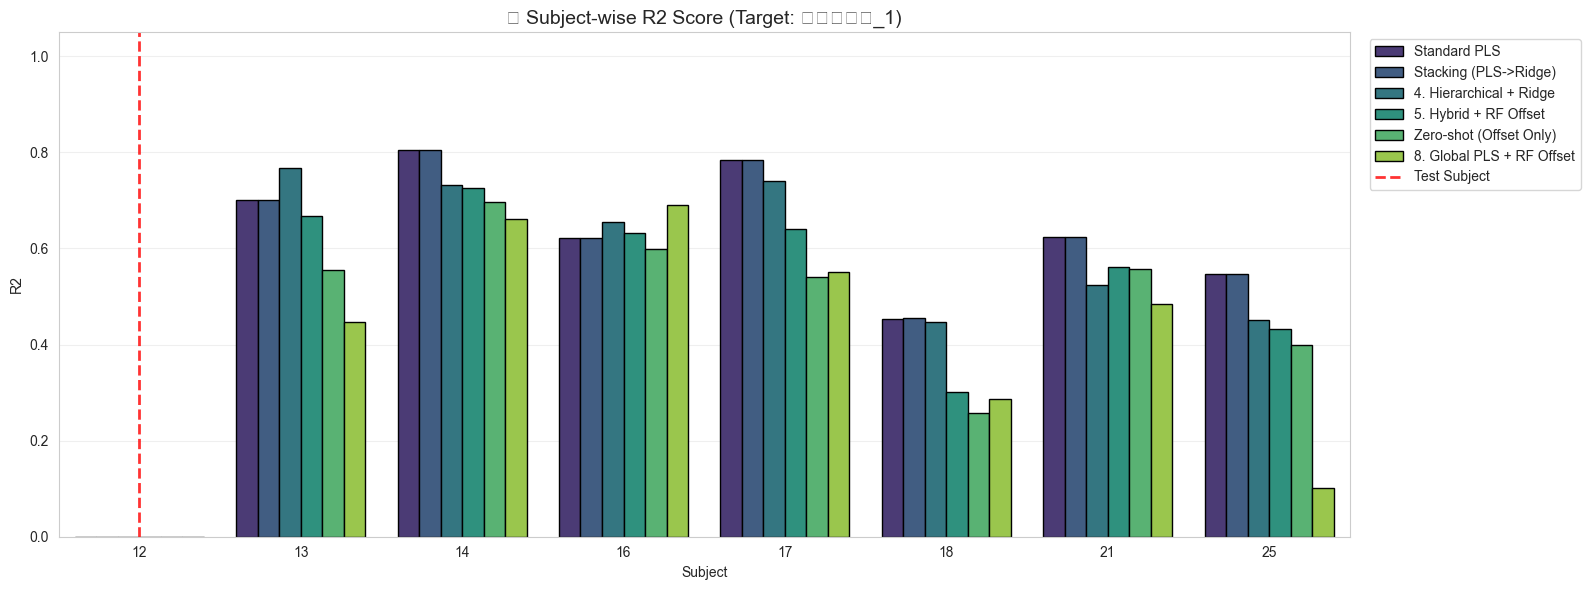

📊 [4/5] Generating Residual Distributions...


C:\Users\youli\AppData\Local\Temp\ipykernel_5088\3936075092.py:198: UserWarning: Glyph 9315 (\N{CIRCLED DIGIT FOUR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_5088\3936075092.py:198: UserWarning: Glyph 22311 (\N{CJK UNIFIED IDEOGRAPH-5727}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_5088\3936075092.py:198: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_5088\3936075092.py:198: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_5088\3936075092.py:198: UserWarning: Glyph 24515 (\N{CJK UNIFIED IDEOGRAPH-5FC3}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_5088\3936075092.py:198: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing 

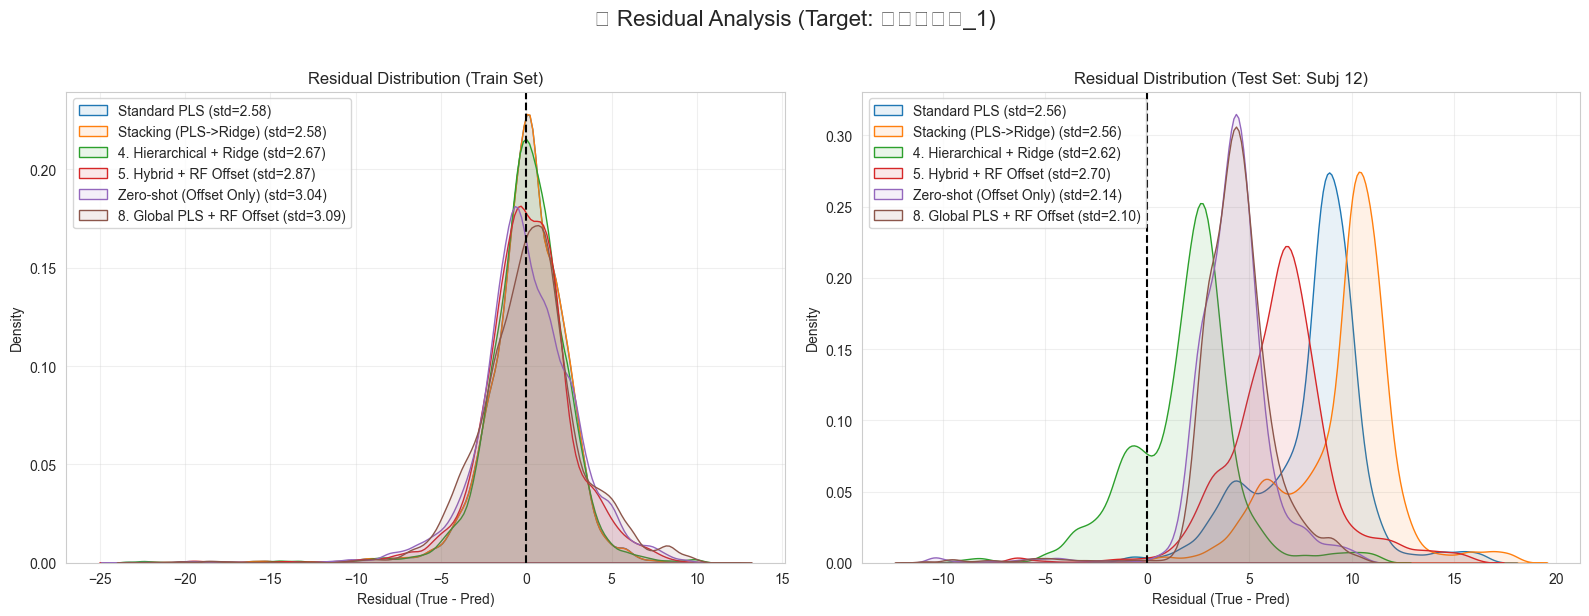

C:\Users\youli\AppData\Local\Temp\ipykernel_5088\3936075092.py:252: UserWarning: Glyph 9316 (\N{CIRCLED DIGIT FIVE}) missing from font(s) Arial.
  plt.tight_layout()


📊 [5/5] Checking for Hierarchical Parameters...
 ✅ Found Hierarchical Model: 4. Hierarchical + Ridge


c:\Users\youli\Desktop\code\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9316 (\N{CIRCLED DIGIT FIVE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


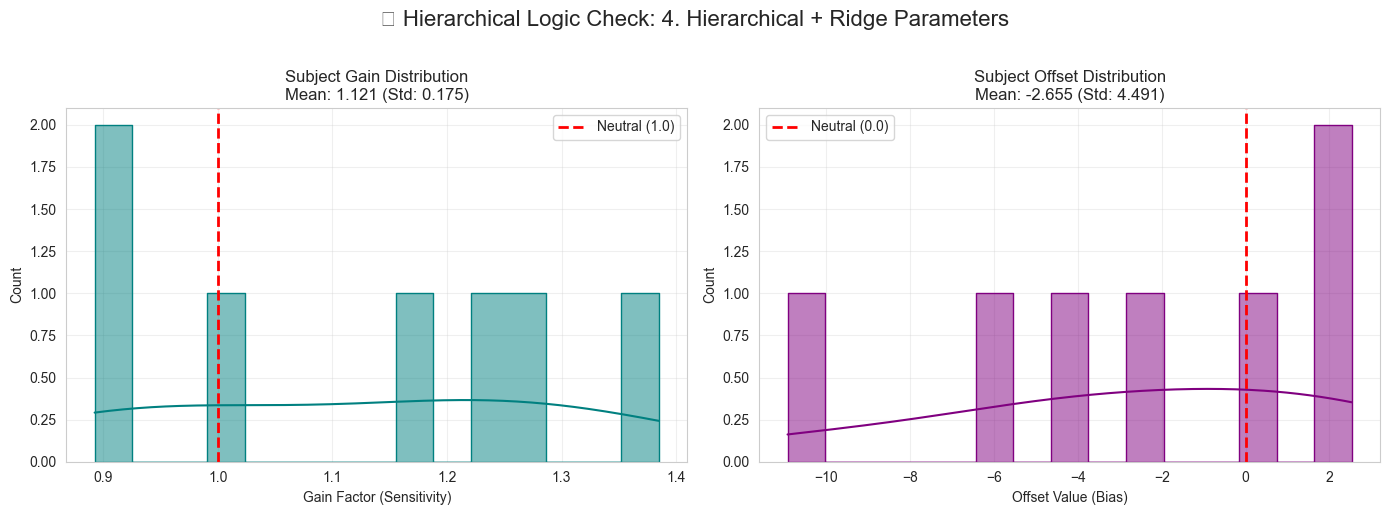

In [9]:

# ==========================================
# 📊 6. 統合可視化クラス (The "Full House" Visualizer)
# ==========================================
class PLSVisualizer:
    def __init__(self, strategies, X_raw, y_raw, target_col, holdout_subject_id):
        """
        全5種類の診断図を一括生成するクラス
        """
        self.strategies = strategies
        self.X_raw = X_raw
        self.y_raw = y_raw
        self.target_col = target_col
        self.holdout_id = holdout_subject_id
        
        # コンパレーターのロジックを借用してデータを前処理
        # (ModelComparatorのインスタンス化には strategiesが必要ですが、ここでは前処理機能だけ使います)
        self.comparator = mm.ModelComparator(strategies, smooth_y=True, skip_bias_cols=SKIP_BIAS_KEYWORDS)
        
        self.X_proc = self.comparator.preprocess_common(X_raw)
        self.y_target = self.comparator._get_y_target(y_raw, X_raw, target_col)
        self.subjects = X_raw['subject_id'].values
        
        # Train/Test Split
        self.mask_test = self.subjects == holdout_subject_id
        self.mask_train = ~self.mask_test
        
        # 予測の実行とキャッシュ
        self.preds = {}
        self._run_predictions()

    def _run_predictions(self):
        """全戦略でTrainにて学習し、全データに対する予測値を保存"""
        print(f"⚙️ Visualizer: Re-fitting models for target '{self.target_col}'...")
        X_train = self.X_proc[self.mask_train]
        y_train = self.y_target[self.mask_train]
        sub_train = self.subjects[self.mask_train]
        
        for strategy in self.strategies:
            # 可視化用にその場のHold-outで再学習
            strategy.fit(X_train, y_train, sub_train)
            self.preds[strategy.name] = strategy.predict(self.X_proc, self.subjects)

    def generate_full_report(self):
        """全5種類のグラフを一括生成"""
        sns.set_style("whitegrid")
        self.plot_1_timeseries_grid()
        self.plot_2_scatter_train_test()
        self.plot_3_subject_r2_bar()
        self.plot_4_residual_distribution()
        self.plot_5_hierarchical_params()

    # -------------------------------------------------------------------------
    # ① 時系列波形 (全被験者・全戦略重ね)
    # -------------------------------------------------------------------------
    def plot_1_timeseries_grid(self):
        print("\n📊 [1/5] Generating Time Series Grid...")
        unique_subjects = np.sort(np.unique(self.subjects))
        n_cols = 2
        n_rows = (len(unique_subjects) + 1) // 2
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows), sharey=True)
        axes = axes.flatten()
        
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#17becf'] # Blue, Orange, Green, Red
        
        for i, subj in enumerate(unique_subjects):
            if i >= len(axes): break
            ax = axes[i]
            mask = self.subjects == subj
            
            # True Value
            ax.plot(self.y_target[mask], label='True', color='black', lw=2.5, alpha=0.3)
            
            # Predictions
            for j, (name, pred) in enumerate(self.preds.items()):
                ax.plot(pred[mask], label=name, color=colors[j%len(colors)], lw=1.7-(0.1*j), alpha=0.9)
            
            status = "【TEST】" if subj == self.holdout_id else "Train"
            title_color = "red" if subj == self.holdout_id else "black"
            ax.set_title(f"Subject {subj} ({status})", fontweight='bold', color=title_color)
            
            if i == 0: ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
        
        for j in range(i+1, len(axes)): axes[j].axis('off')
        plt.tight_layout()
        plt.suptitle(f"① Time Series Overview (Target: {self.target_col})", y=1.01, fontsize=16)
        plt.show()

    # -------------------------------------------------------------------------
    # ② Train/Test 散布図
    # -------------------------------------------------------------------------
    def plot_2_scatter_train_test(self):
        print("📊 [2/5] Generating Scatter Plots...")
        fig, axes = plt.subplots(len(self.strategies), 2, figsize=(14, 5 * len(self.strategies)))
        if len(self.strategies) == 1: axes = axes.reshape(1, -1)
        
        for i, strategy in enumerate(self.strategies):
            pred = self.preds[strategy.name]
            
            # Train Scatter
            ax_tr = axes[i, 0]
            # データ点が多い場合は alpha を下げる
            sns.scatterplot(x=self.y_target[self.mask_train], y=pred[self.mask_train], 
                            hue=self.subjects[self.mask_train], palette='tab20', 
                            alpha=0.5, s=15, ax=ax_tr, legend=False)
            
            min_val = min(self.y_target.min(), pred.min())
            max_val = max(self.y_target.max(), pred.max())
            ax_tr.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1)
            
            r2_tr = r2_score(self.y_target[self.mask_train], pred[self.mask_train])
            ax_tr.set_title(f"{strategy.name} (Train) | R2={r2_tr:.3f}")
            ax_tr.set_ylabel("Predicted")
            ax_tr.set_xlabel("True")

            # Test Scatter
            ax_te = axes[i, 1]
            sns.scatterplot(x=self.y_target[self.mask_test], y=pred[self.mask_test], 
                            color='orange', alpha=0.8, s=30, ax=ax_te)
            ax_te.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1)
            
            r2_te = r2_score(self.y_target[self.mask_test], pred[self.mask_test])
            ax_te.set_title(f"{strategy.name} (Test: Subj {self.holdout_id}) | R2={r2_te:.3f}")
            ax_te.set_xlabel("True")
            
        plt.tight_layout()
        plt.suptitle(f"② True vs Pred Scatter (Target: {self.target_col})", y=1.01, fontsize=16)
        plt.show()

    # -------------------------------------------------------------------------
    # ③ 被験者ごと・戦略ごとの R2 バー図
    # -------------------------------------------------------------------------
    def plot_3_subject_r2_bar(self):
        print("📊 [3/5] Generating Subject-wise R2 Comparison...")
        results = []
        unique_subjects = np.unique(self.subjects)
        
        for subj in unique_subjects:
            mask = self.subjects == subj
            y_true_s = self.y_target[mask]
            
            if len(y_true_s) < 2: continue # データ不足回避

            for strategy in self.strategies:
                y_pred_s = self.preds[strategy.name][mask]
                r2 = r2_score(y_true_s, y_pred_s)
                results.append({'Subject': str(subj), 'Model': strategy.name, 'R2': r2})
                
        df_res = pd.DataFrame(results)
        
        plt.figure(figsize=(16, 6))
        sns.barplot(data=df_res, x='Subject', y='R2', hue='Model', palette='viridis', edgecolor='black')
        
        # Test被験者を強調
        try:
            idx = list(map(str, unique_subjects)).index(str(self.holdout_id))
            plt.axvline(x=idx, color='red', linestyle='--', alpha=0.8, lw=2, label='Test Subject')
        except ValueError:
            pass # Test被験者がリストにない場合 (稀)
        
        plt.ylim(0, 1.05)
        plt.title(f"③ Subject-wise R2 Score (Target: {self.target_col})", fontsize=14)
        plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

    # -------------------------------------------------------------------------
    # ④ 残差分布 (KDE Plot)
    # -------------------------------------------------------------------------
    def plot_4_residual_distribution(self):
        print("📊 [4/5] Generating Residual Distributions...")
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Train Residuals
        for strategy in self.strategies:
            resid = self.y_target[self.mask_train] - self.preds[strategy.name][self.mask_train]
            sns.kdeplot(resid, ax=axes[0], label=f"{strategy.name} (std={np.std(resid):.2f})", fill=True, alpha=0.1)
            
        axes[0].set_title("Residual Distribution (Train Set)")
        axes[0].set_xlabel("Residual (True - Pred)")
        axes[0].axvline(0, color='black', linestyle='--')
        axes[0].legend()
        axes[0].grid(alpha=0.3)
        
        # Test Residuals
        for strategy in self.strategies:
            resid = self.y_target[self.mask_test] - self.preds[strategy.name][self.mask_test]
            sns.kdeplot(resid, ax=axes[1], label=f"{strategy.name} (std={np.std(resid):.2f})", fill=True, alpha=0.1)
            
        axes[1].set_title(f"Residual Distribution (Test Set: Subj {self.holdout_id})")
        axes[1].set_xlabel("Residual (True - Pred)")
        axes[1].axvline(0, color='black', linestyle='--')
        axes[1].legend()
        axes[1].grid(alpha=0.3)
        
        plt.suptitle(f"④ Residual Analysis (Target: {self.target_col})", y=1.02, fontsize=16)
        plt.tight_layout()
        plt.show()

    # -------------------------------------------------------------------------
    # ⑤ Gain / Offset 分布 (Hierarchical PLS Only) - ★ここが重要
    # -------------------------------------------------------------------------
    def plot_5_hierarchical_params(self):
        print("📊 [5/5] Checking for Hierarchical Parameters...")
        
        # Hierarchical系のモデルを探す
        target_strat = None
        for strat in self.strategies:
            # 純粋なHierarchicalPLSStrategyの場合
            model = getattr(strat, 'model', None)
            if hasattr(model, 'subject_gains') and hasattr(model, 'subject_offsets'):
                target_strat = strat
                break
            
            # Hybrid (Ridge) の場合、中身のmodel_hplsを見る
            if hasattr(strat, 'model_hpls'):
                model_h = getattr(strat, 'model_hpls', None)
                if hasattr(model_h, 'subject_gains'):
                    target_strat = strat
                    # model変数を差し替え
                    model = model_h 
                    break
        
        if target_strat is None:
            print("   ⚠️ No Hierarchical PLS model found among strategies. Skipping Plot ⑤.")
            return

        print(f" ✅ Found Hierarchical Model: {target_strat.name}")
        
        gains = list(model.subject_gains.values())
        offsets = list(model.subject_offsets.values())
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        # Gain Histogram
        sns.histplot(gains, bins=15, kde=True, ax=axes[0], color='teal', element="step")
        axes[0].axvline(1.0, color='red', linestyle='--', lw=2, label='Neutral (1.0)')
        axes[0].set_title(f"Subject Gain Distribution\nMean: {np.mean(gains):.3f} (Std: {np.std(gains):.3f})")
        axes[0].set_xlabel("Gain Factor (Sensitivity)")
        axes[0].legend()
        axes[0].grid(alpha=0.3)
        
        # Offset Histogram
        sns.histplot(offsets, bins=15, kde=True, ax=axes[1], color='purple', element="step")
        axes[1].axvline(0.0, color='red', linestyle='--', lw=2, label='Neutral (0.0)')
        axes[1].set_title(f"Subject Offset Distribution\nMean: {np.mean(offsets):.3f} (Std: {np.std(offsets):.3f})")
        axes[1].set_xlabel("Offset Value (Bias)")
        axes[1].legend()
        axes[1].grid(alpha=0.3)
        
        plt.suptitle(f"⑤ Hierarchical Logic Check: {target_strat.name} Parameters", y=1.02, fontsize=16)
        plt.tight_layout()
        plt.show()

# ==========================================
# 🚀 実行ブロック (Visualization Execution)
# ==========================================

# 1つだけ可視化したい場合（例：'圧力中心行_1'）# 3-8
target_vis = target_features_A[0] 
# もしくはループで回す
# for target_vis in target_features_A: ...

print(f"\n🎨 Starting Full Visualization Report for: {target_vis}")
viz = PLSVisualizer(
    strategies=strategies, 
    X_raw=X_raw, 
    y_raw=y_raw, 
    target_col=target_vis, 
    holdout_subject_id=12
)
viz.generate_full_report()

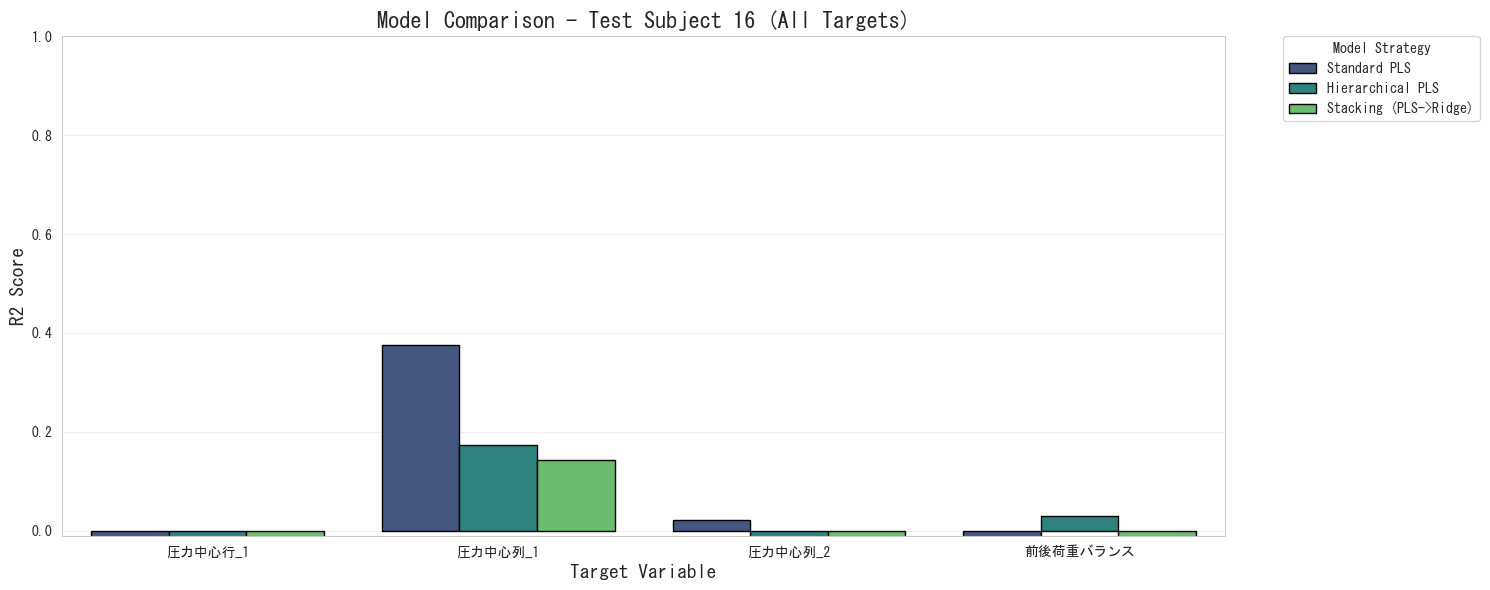

In [ ]:
# 実行例
mm.plot_model_comparison_bar(
    results, 
    title="Model Comparison - Test Subject 16 (All Targets)",
    ylim=(-0.01, 1.0) # 必要に応じて範囲を調整
)

📊 Generating Scatter Plots for 前後荷重バランス...
   Running Common Preprocessing (X)...


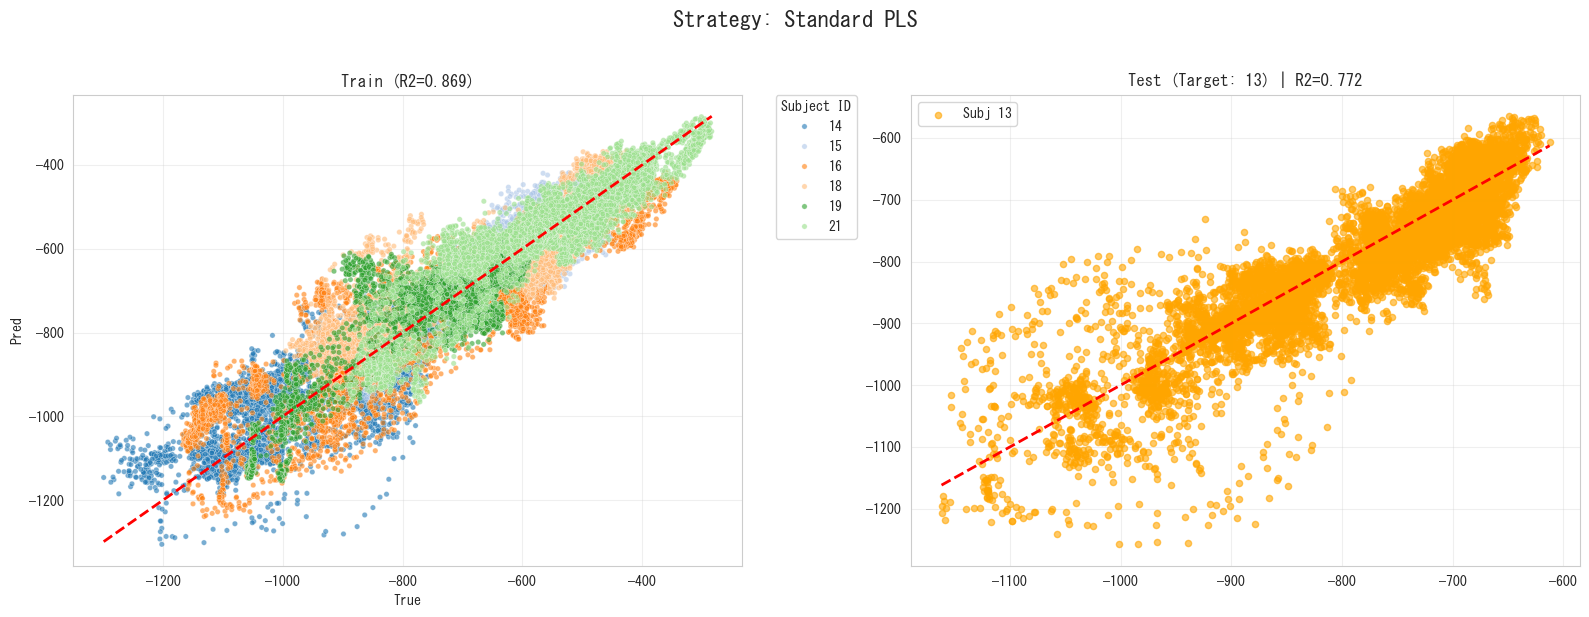

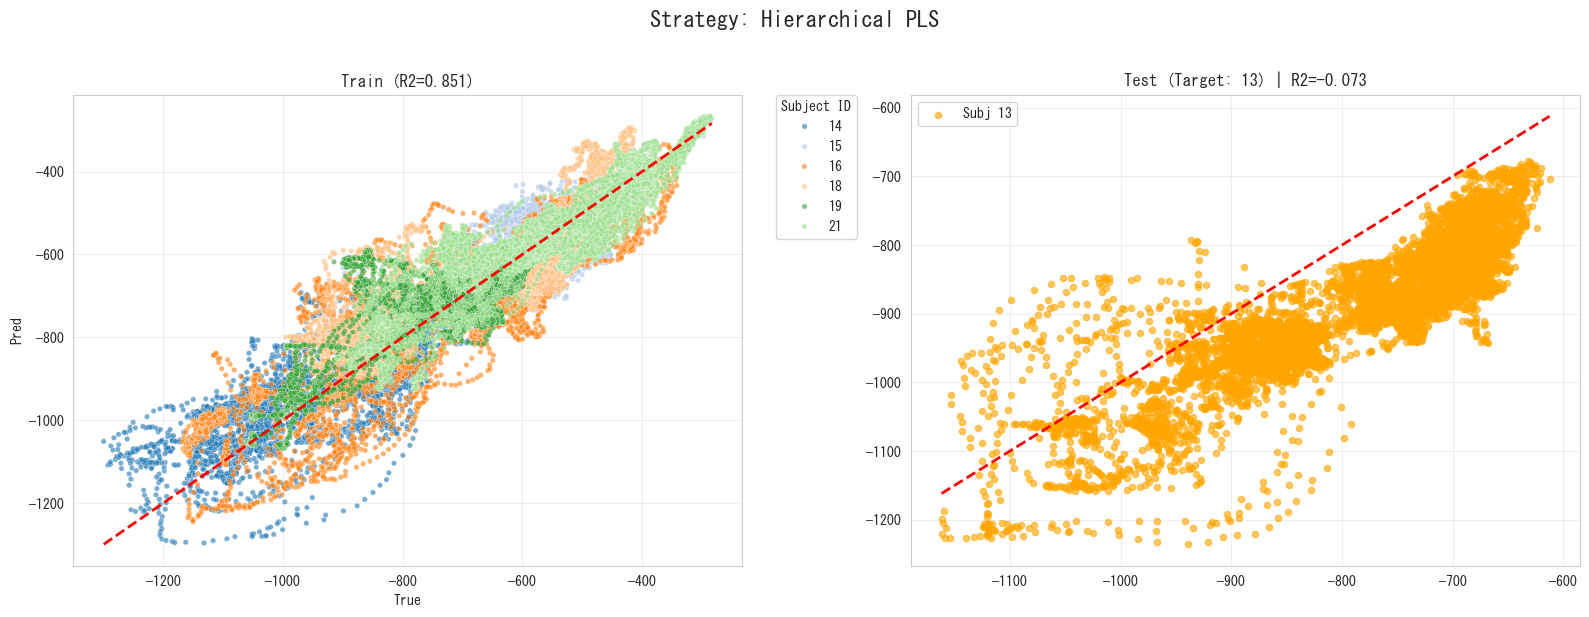

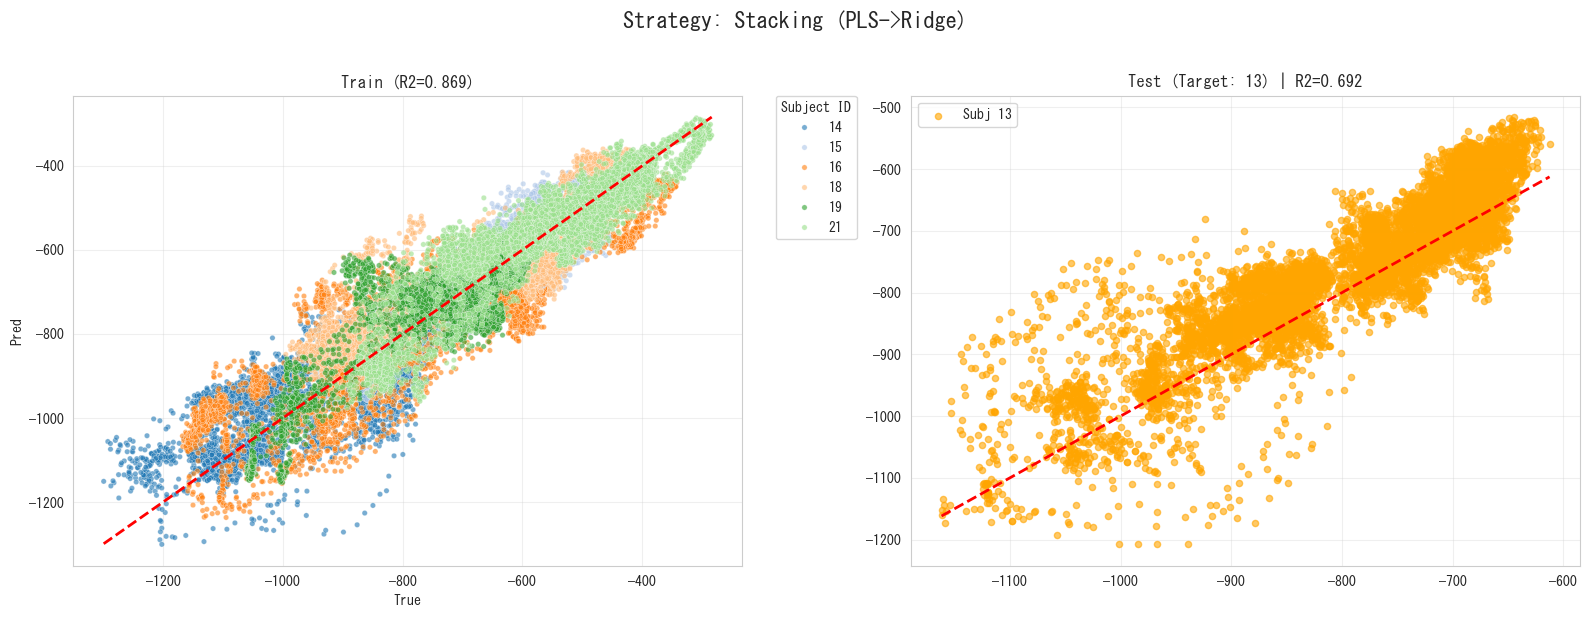

In [ ]:
mm.plot_diagnosis_scatter(strategies, X_raw, y_raw, target_features_A[3], 13)


📊 Generating Time Series Grid for 前後バランス with pedal...
   Running Common Preprocessing (X)...


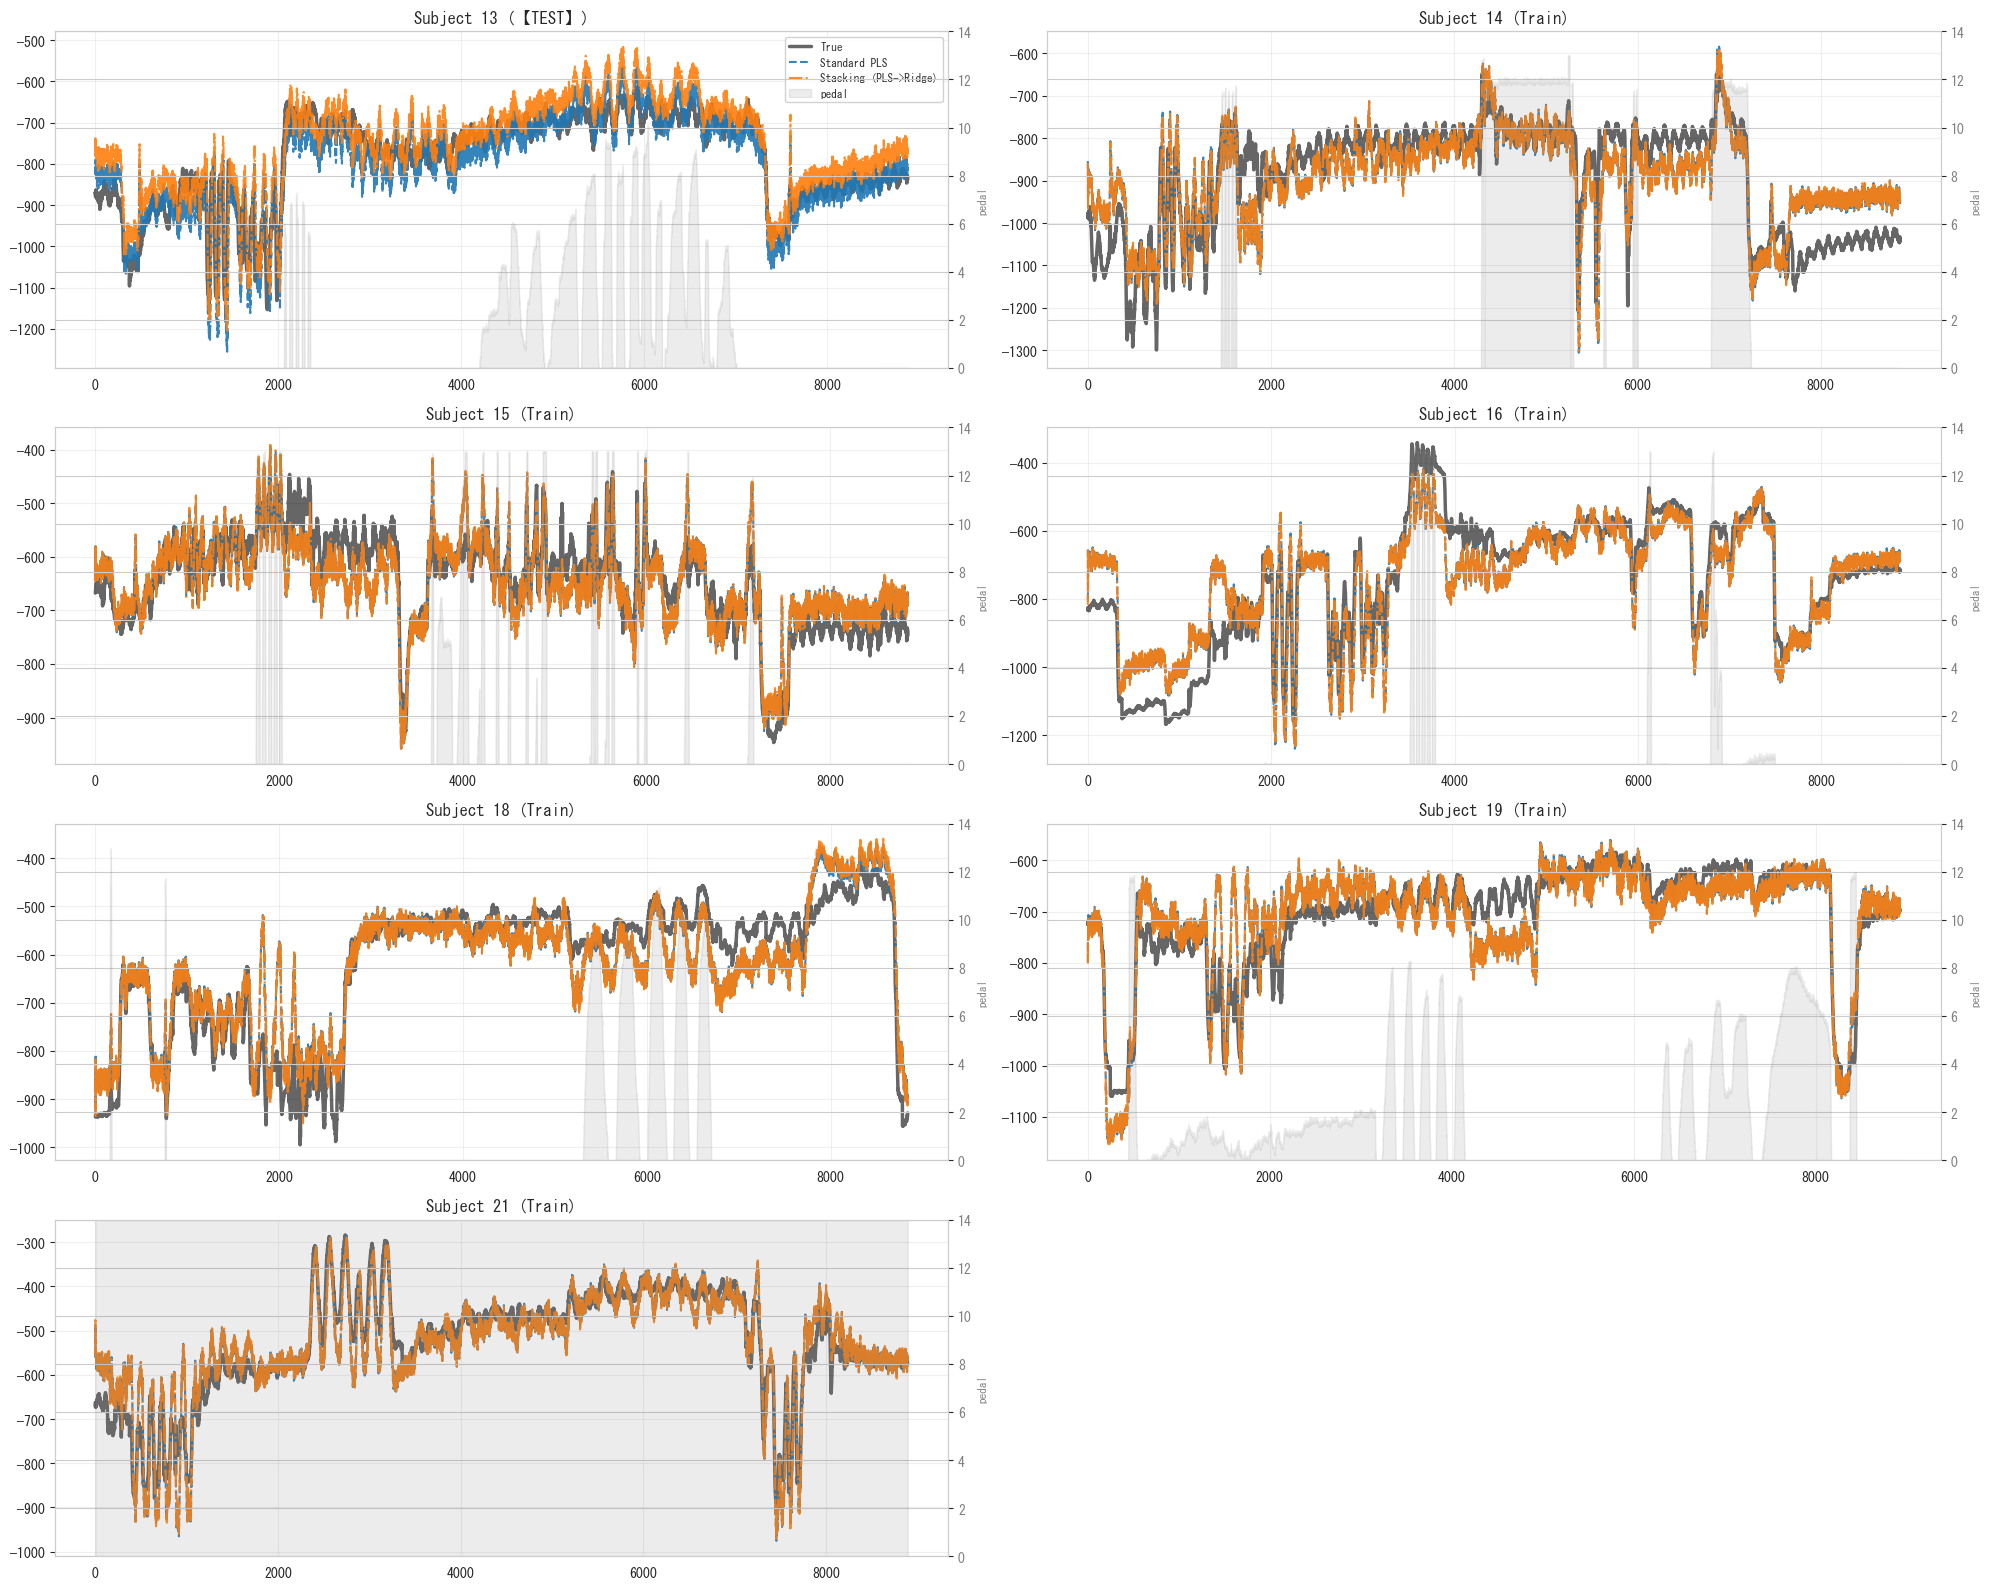

In [ ]:

PREPROCESSING_CONFIGS = {
    'standard_pls':     {'scale_x': True,  'n_components': 14}, 
    'hierarchical_pls': {'scale_x': False, 'n_components':14},     
    'pls_ridge':        {'scale_x': True,  'n_components':14,'scale_state2':False}, 
    'hierarchical_hybrid': {'scale_x': False, 'n_components':14,'scale_stage2': False}, 
}
strategies = [
    mm.StandardPLSStrategy(
        config=PREPROCESSING_CONFIGS['standard_pls'], 
    ),
    
    # mm.HierarchicalPLSStrategy(
    #     config=PREPROCESSING_CONFIGS['hierarchical_pls'], 
    # ),
    
    mm.StackingPLS2RidgeStrategy(
        config=PREPROCESSING_CONFIGS['pls_ridge'],
        ridge_alpha=1.0, 
        static_cols=STATIC_FEATURES
    ),

    # mm.HierarchicalRidgeHybridStrategy(
    #     config=PREPROCESSING_CONFIGS['hierarchical_hybrid'],
    #     static_cols=STATIC_FEATURES
    # )
]
# 2. 全員分の時系列 (巨大な1枚の図になります)
mm.plot_diagnosis_timeseries_grid2(strategies, X_raw, y_raw, target_features_A[3], 13,feature_col='pedal')

   Running Common Preprocessing (X)...
📊 Training Zero-shot models for both targets

🎯 Target: 圧力中心行_1

✅ Gain/Offset Predictors Trained:
   - Gain R²: 0.489
   - Offset R²: 0.459

📊 Feature Importance (Coefficients):
Feature                    Gain     Offset
------------------------------------------
W_init                   0.1079    -3.7387
W_absolute               0.0546    -2.9039
F1_init                  0.1063    -2.7696
F2_init                  0.1678    -4.9892
F3_init                 -0.0764     1.6818
F4_init                 -0.0897     2.3382
LR_balance_init         -0.0264     1.1992
FB_balance_init          0.3847   -10.3276

🎯 Target: 圧力中心行_2

✅ Gain/Offset Predictors Trained:
   - Gain R²: 0.169
   - Offset R²: 0.152

📊 Feature Importance (Coefficients):
Feature                    Gain     Offset
------------------------------------------
W_init                  -0.0449     0.0499
W_absolute              -0.0794     0.3123
F1_init                  0.0176    -0.4100
F2_

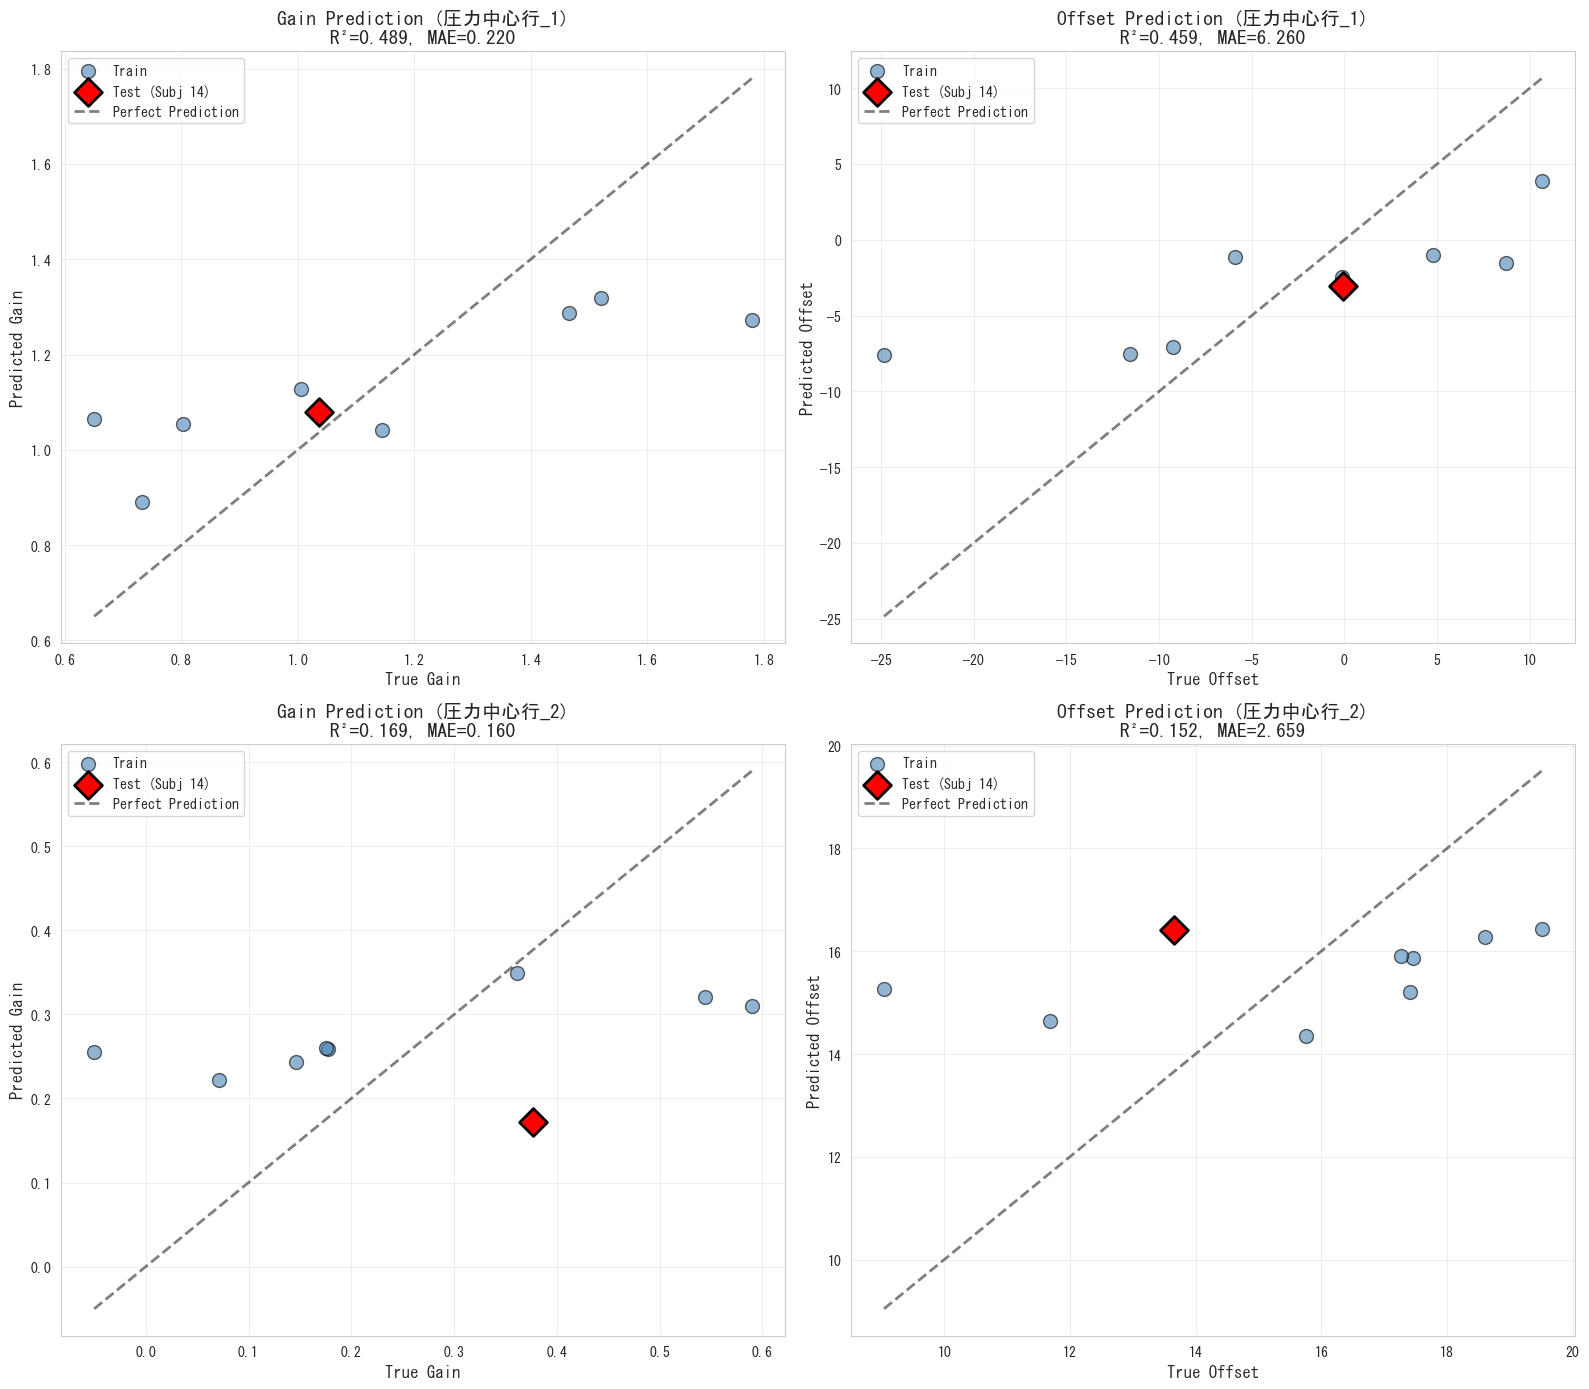

✅ Saved: static_features_vs_gain.png


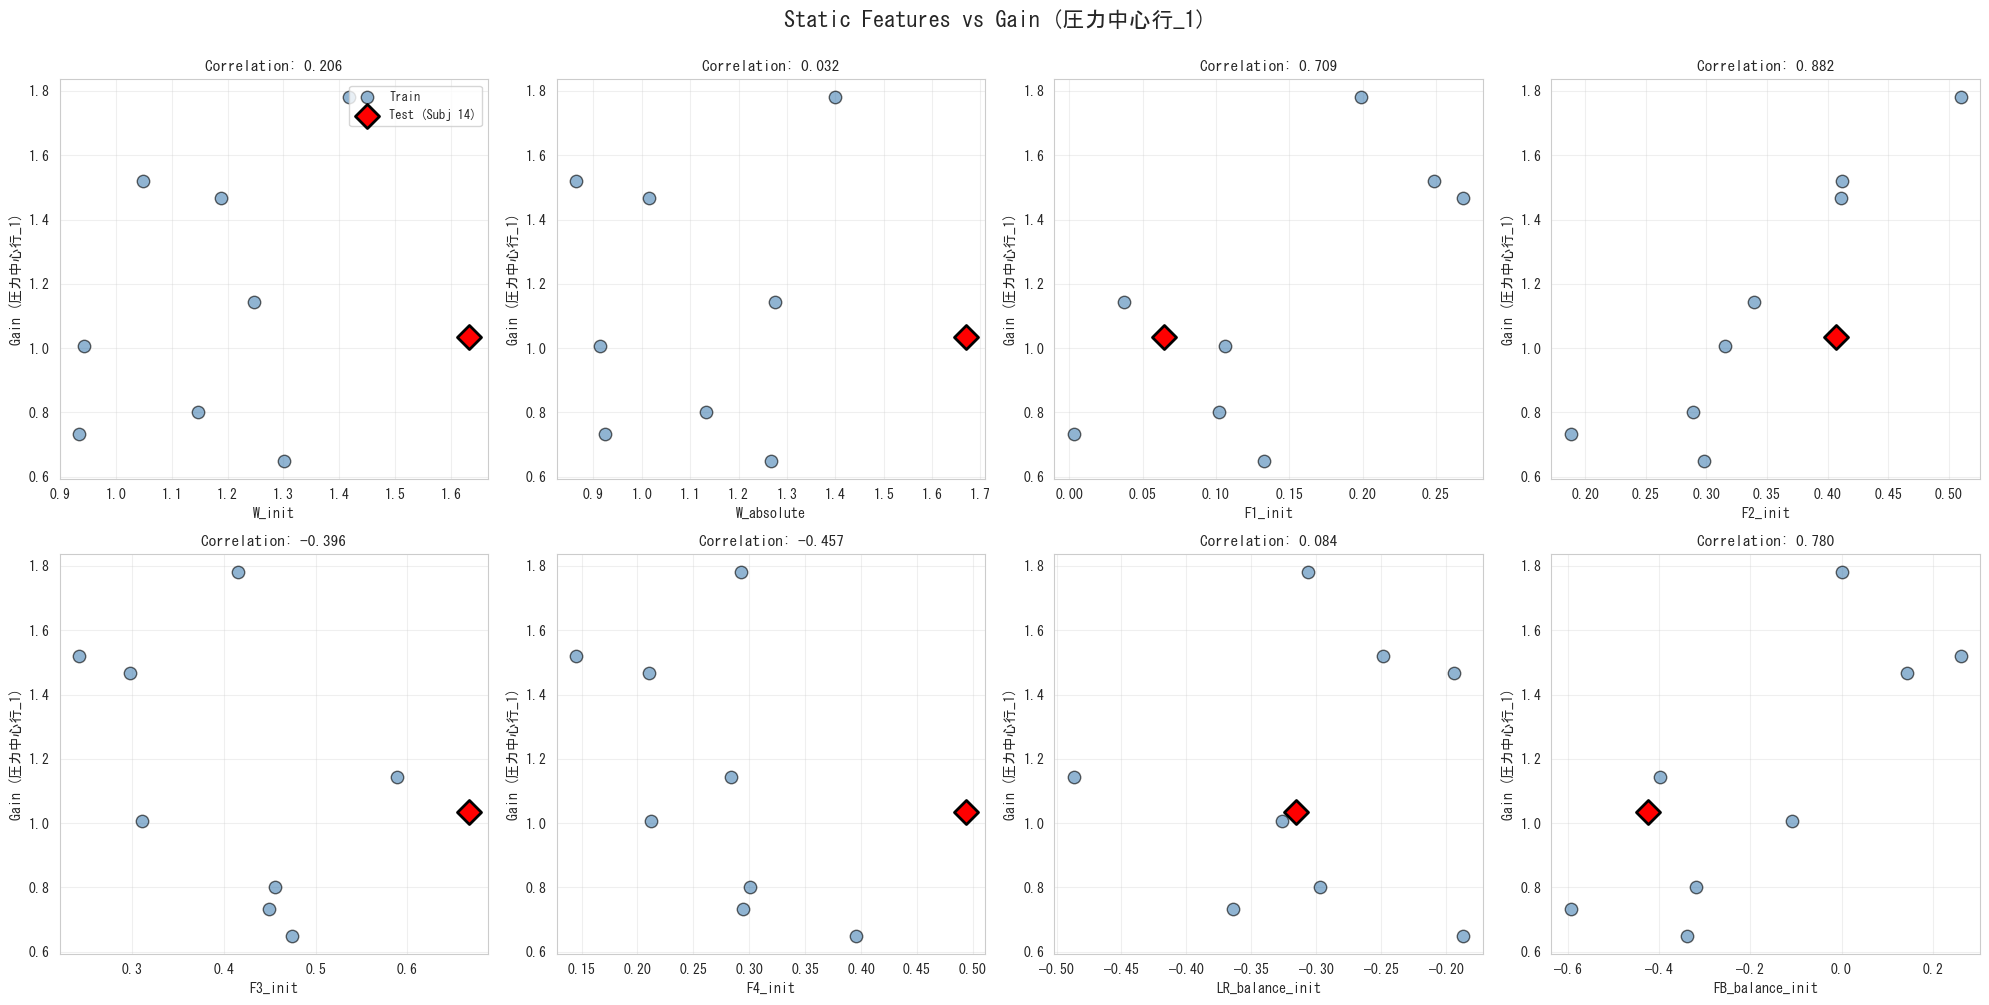

✅ Saved: subject14_correction_analysis.png


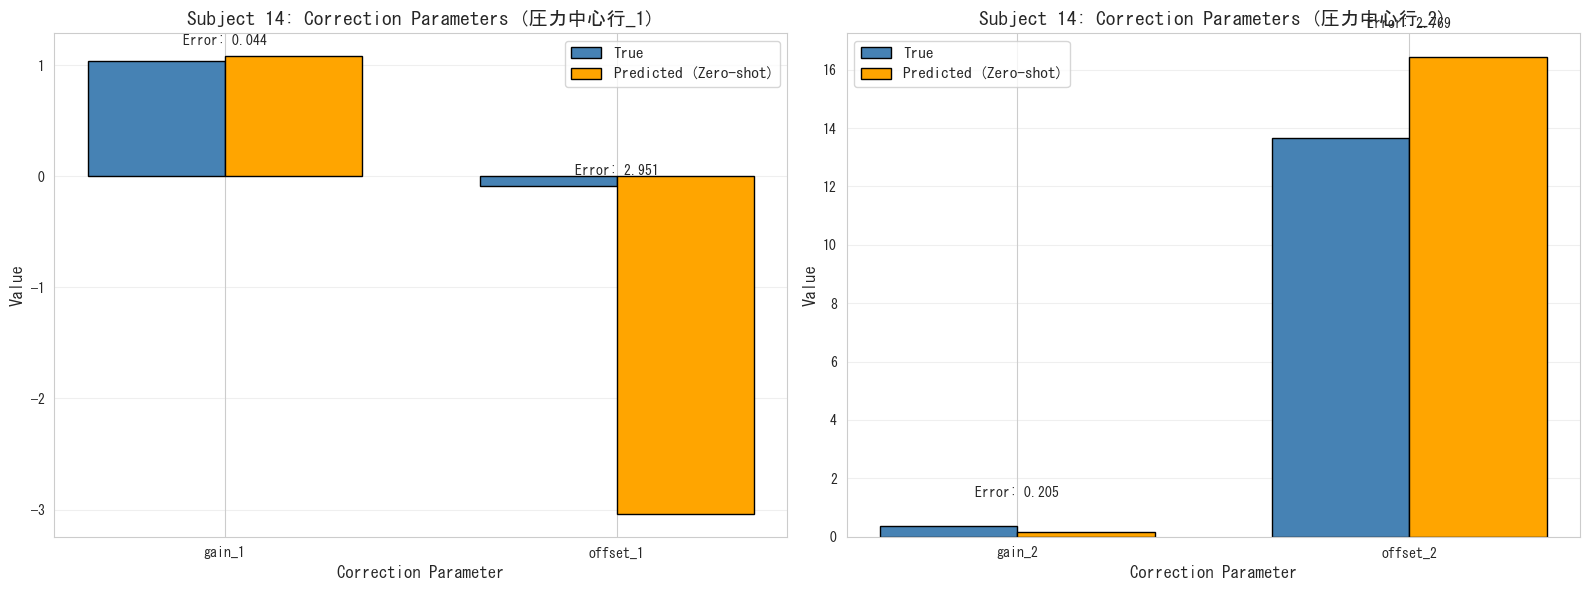


📊 Zero-shot Predictor Performance Summary

【圧力中心行_1】
  Gain  - R²: 0.489, MAE: 0.220
  Offset - R²: 0.459, MAE: 6.260

【圧力中心行_2】
  Gain  - R²: 0.169, MAE: 0.160
  Offset - R²: 0.152, MAE: 2.659

【Subject 14 (Test) の予測】

  圧力中心行_1:
    Gain:   True=1.0357, Pred=1.0798 (Error=0.0441)
    Offset: True=-0.0873, Pred=-3.0385 (Error=2.9512)

  圧力中心行_2:
    Gain:   True=0.3770, Pred=0.1724 (Error=0.2045)
    Offset: True=13.6504, Pred=16.4190 (Error=2.7686)

✅ Visualization complete!

📁 Saved: subject_corrections.csv


In [7]:
"""
ゲイン・オフセット予測の可視化
Zero-shot predictor の性能を詳しく分析
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import r2_score, mean_absolute_error
import pickle

# ==========================================
# データ読み込みと準備
# ==========================================

with open(r"C:\Users\youli\Desktop\code\20251118_COPモドキ\20251214home\modelA_df_proc.pkl", "rb") as f:
    df_all = pickle.load(f)

df_all['W_absolute'] = df_all['W']

# LR_balance と FB_balance を計算
if 'LR_balance' not in df_all.columns:
    df_all['LR_balance'] = (df_all['F1'] + df_all['F4'] - df_all['F2'] - df_all['F3']) / (df_all['W'] + 1e-8)

if 'FB_balance' not in df_all.columns:
    df_all['FB_balance'] = (df_all['F1'] + df_all['F2'] - df_all['F3'] - df_all['F4']) / (df_all['W'] + 1e-8)

df_all = df_all[~df_all['subject_id'].isin([20,24,25,26,27])].copy()

# 特徴量定義
mock_sensor_cols = [
    'subject_id',
    'F1', 'F2', 'F3', 'F4', 'steer', 'pedal', 'W', 
    'LR_balance', 'FB_balance',
    'F1_fnorm', 'F2_fnorm', 'F3_fnorm', 'F4_fnorm',
    'COP_X_phys', 'COP_Y_phys', 'phys_pitch', 'phys_roll', 'phys_torsion',
    'COP_radius', 'COP_angle', 'op_magnitude', 'interact_steer_pedal',
    'steer_COPx', 'steer_COPy', 'pedal_COPx', 'pedal_COPy',
    'COP_X_phys_vel', 'COP_Y_phys_vel', 'W_vel', 'phys_pitch_vel',
    'phys_roll_vel', 'steer_vel', 'pedal_vel', 'interact_steer_vel_COP',
    'F1_hysteresis', 'F2_hysteresis', 'F3_hysteresis', 'F4_hysteresis',
    'W_hysteresis', 'COP_X_phys_hysteresis', 'COP_Y_phys_hysteresis',
    'Interaction_COPX_W', 'Interaction_COPY_W', 
    'W_Power', 'COP_X_phys_Power', 'COP_Y_phys_Power',
    'COP_X_phys_vel_integ', 'COP_X_phys_vel_ma30', 
    'COP_Y_phys_vel_integ', 'COP_Y_phys_vel_ma30', 
    'W_vel_integ', 'W_vel_ma30',
    'phys_pitch_vel_integ', 'phys_pitch_vel_ma30', 
    'phys_roll_vel_integ', 'phys_roll_vel_ma30',
    'F1_init', 'F2_init', 'F3_init', 'F4_init',
    'W_init', 'LR_balance_init', 'FB_balance_init', 'W_absolute'
]

target_features_A = ['圧力中心行_1', '圧力中心行_2']

available_cols = df_all.columns.tolist()
X_cols = [c for c in mock_sensor_cols if c in available_cols]
Y_cols = [c for c in target_features_A if c in available_cols]

df_raw = df_all[X_cols + Y_cols].dropna()
X_raw = df_raw[X_cols]
y_raw = df_raw[Y_cols]

STATIC_FEATURES = [
    'W_init', 'W_absolute',
    'F1_init', 'F2_init', 'F3_init', 'F4_init',
    'LR_balance_init', 'FB_balance_init'
]

SKIP_BIAS_KEYWORDS = [
    'subject_id', '_init', '_vel', '_hysteresis', '_CLR', '_Power', '_absolute'
]

# ==========================================
# モデル学習とゲイン・オフセット収集
# ==========================================

import my_module4 as mm

# 前処理
comparator = mm.ModelComparator(
    [mm.HierarchicalPLSStrategy({'scale_x': False, 'n_components': 10})],
    smooth_y=True, 
    skip_bias_cols=SKIP_BIAS_KEYWORDS
)

X_proc = comparator.preprocess_common(X_raw)
y_target_1 = y_raw['圧力中心行_1'].values
y_target_2 = y_raw['圧力中心行_2'].values
subjects = X_raw['subject_id'].values

# 静的特徴量と動的特徴量に分離
available_static = [col for col in STATIC_FEATURES if col in X_proc.columns]
static_features = X_proc[available_static].values

drop_cols = available_static + ['subject_id']
X_dynamic = X_proc.drop(columns=drop_cols, errors='ignore').values

# ==========================================
# 2つのターゲットでモデル学習
# ==========================================

print("="*80)
print("📊 Training Zero-shot models for both targets")
print("="*80)

# Target 1
print("\n🎯 Target: 圧力中心行_1")
model_1 = mm.HierarchicalPLSModelZeroShot(n_components=10, ridge_alpha=1.0)
model_1.fit(X_dynamic, y_target_1, subjects, static_features, available_static)

# Target 2
print("\n🎯 Target: 圧力中心行_2")
model_2 = mm.HierarchicalPLSModelZeroShot(n_components=10, ridge_alpha=1.0)
model_2.fit(X_dynamic, y_target_2, subjects, static_features, available_static)

# ==========================================
# 被験者ごとのデータを収集
# ==========================================

unique_subjects = np.unique(subjects)
subject_data = []

for subj in unique_subjects:
    mask = (subjects == subj)
    static_feat = static_features[mask].mean(axis=0)
    
    # Target 1
    gain_1_true = model_1.subject_gains[subj]
    offset_1_true = model_1.subject_offsets[subj]
    gain_1_pred = model_1.gain_predictor.predict([static_feat])[0]
    offset_1_pred = model_1.offset_predictor.predict([static_feat])[0]
    
    # Target 2
    gain_2_true = model_2.subject_gains[subj]
    offset_2_true = model_2.subject_offsets[subj]
    gain_2_pred = model_2.gain_predictor.predict([static_feat])[0]
    offset_2_pred = model_2.offset_predictor.predict([static_feat])[0]
    
    # 静的特徴量
    row = {
        'subject_id': subj,
        'is_test': (subj == 14),
        # Target 1
        'gain_1_true': gain_1_true,
        'gain_1_pred': gain_1_pred,
        'offset_1_true': offset_1_true,
        'offset_1_pred': offset_1_pred,
        # Target 2
        'gain_2_true': gain_2_true,
        'gain_2_pred': gain_2_pred,
        'offset_2_true': offset_2_true,
        'offset_2_pred': offset_2_pred,
    }
    
    # 静的特徴量も追加
    for i, name in enumerate(available_static):
        row[name] = static_feat[i]
    
    subject_data.append(row)

df_subjects = pd.DataFrame(subject_data)

# ==========================================
# 可視化 1: ゲイン・オフセット予測の散布図
# ==========================================

print("\n📊 Creating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# --- Target 1 ---

# Gain (Target 1)
ax = axes[0, 0]
# 訓練データ
train_mask = ~df_subjects['is_test']
ax.scatter(df_subjects.loc[train_mask, 'gain_1_true'], 
           df_subjects.loc[train_mask, 'gain_1_pred'],
           s=100, alpha=0.6, label='Train', color='steelblue', edgecolors='black')

# テストデータ (Subject 14)
test_mask = df_subjects['is_test']
if test_mask.sum() > 0:
    ax.scatter(df_subjects.loc[test_mask, 'gain_1_true'], 
               df_subjects.loc[test_mask, 'gain_1_pred'],
               s=200, alpha=1.0, label='Test (Subj 14)', color='red', 
               edgecolors='black', linewidths=2, marker='D')

# 対角線
min_val = min(df_subjects['gain_1_true'].min(), df_subjects['gain_1_pred'].min())
max_val = max(df_subjects['gain_1_true'].max(), df_subjects['gain_1_pred'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, alpha=0.5, label='Perfect Prediction')

# R²とMAE
r2_gain1 = r2_score(df_subjects['gain_1_true'], df_subjects['gain_1_pred'])
mae_gain1 = mean_absolute_error(df_subjects['gain_1_true'], df_subjects['gain_1_pred'])

ax.set_xlabel('True Gain', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted Gain', fontsize=12, fontweight='bold')
ax.set_title(f'Gain Prediction (圧力中心行_1)\nR²={r2_gain1:.3f}, MAE={mae_gain1:.3f}', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(alpha=0.3)

# Offset (Target 1)
ax = axes[0, 1]
ax.scatter(df_subjects.loc[train_mask, 'offset_1_true'], 
           df_subjects.loc[train_mask, 'offset_1_pred'],
           s=100, alpha=0.6, label='Train', color='steelblue', edgecolors='black')

if test_mask.sum() > 0:
    ax.scatter(df_subjects.loc[test_mask, 'offset_1_true'], 
               df_subjects.loc[test_mask, 'offset_1_pred'],
               s=200, alpha=1.0, label='Test (Subj 14)', color='red', 
               edgecolors='black', linewidths=2, marker='D')

min_val = min(df_subjects['offset_1_true'].min(), df_subjects['offset_1_pred'].min())
max_val = max(df_subjects['offset_1_true'].max(), df_subjects['offset_1_pred'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, alpha=0.5, label='Perfect Prediction')

r2_offset1 = r2_score(df_subjects['offset_1_true'], df_subjects['offset_1_pred'])
mae_offset1 = mean_absolute_error(df_subjects['offset_1_true'], df_subjects['offset_1_pred'])

ax.set_xlabel('True Offset', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted Offset', fontsize=12, fontweight='bold')
ax.set_title(f'Offset Prediction (圧力中心行_1)\nR²={r2_offset1:.3f}, MAE={mae_offset1:.3f}', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(alpha=0.3)

# --- Target 2 ---

# Gain (Target 2)
ax = axes[1, 0]
ax.scatter(df_subjects.loc[train_mask, 'gain_2_true'], 
           df_subjects.loc[train_mask, 'gain_2_pred'],
           s=100, alpha=0.6, label='Train', color='steelblue', edgecolors='black')

if test_mask.sum() > 0:
    ax.scatter(df_subjects.loc[test_mask, 'gain_2_true'], 
               df_subjects.loc[test_mask, 'gain_2_pred'],
               s=200, alpha=1.0, label='Test (Subj 14)', color='red', 
               edgecolors='black', linewidths=2, marker='D')

min_val = min(df_subjects['gain_2_true'].min(), df_subjects['gain_2_pred'].min())
max_val = max(df_subjects['gain_2_true'].max(), df_subjects['gain_2_pred'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, alpha=0.5, label='Perfect Prediction')

r2_gain2 = r2_score(df_subjects['gain_2_true'], df_subjects['gain_2_pred'])
mae_gain2 = mean_absolute_error(df_subjects['gain_2_true'], df_subjects['gain_2_pred'])

ax.set_xlabel('True Gain', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted Gain', fontsize=12, fontweight='bold')
ax.set_title(f'Gain Prediction (圧力中心行_2)\nR²={r2_gain2:.3f}, MAE={mae_gain2:.3f}', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(alpha=0.3)

# Offset (Target 2)
ax = axes[1, 1]
ax.scatter(df_subjects.loc[train_mask, 'offset_2_true'], 
           df_subjects.loc[train_mask, 'offset_2_pred'],
           s=100, alpha=0.6, label='Train', color='steelblue', edgecolors='black')

if test_mask.sum() > 0:
    ax.scatter(df_subjects.loc[test_mask, 'offset_2_true'], 
               df_subjects.loc[test_mask, 'offset_2_pred'],
               s=200, alpha=1.0, label='Test (Subj 14)', color='red', 
               edgecolors='black', linewidths=2, marker='D')

min_val = min(df_subjects['offset_2_true'].min(), df_subjects['offset_2_pred'].min())
max_val = max(df_subjects['offset_2_true'].max(), df_subjects['offset_2_pred'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, alpha=0.5, label='Perfect Prediction')

r2_offset2 = r2_score(df_subjects['offset_2_true'], df_subjects['offset_2_pred'])
mae_offset2 = mean_absolute_error(df_subjects['offset_2_true'], df_subjects['offset_2_pred'])

ax.set_xlabel('True Offset', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted Offset', fontsize=12, fontweight='bold')
ax.set_title(f'Offset Prediction (圧力中心行_2)\nR²={r2_offset2:.3f}, MAE={mae_offset2:.3f}', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('gain_offset_prediction.png', dpi=150, bbox_inches='tight')
print("✅ Saved: gain_offset_prediction.png")
plt.show()

# ==========================================
# 可視化 2: 静的特徴量とゲインの関係
# ==========================================

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

# Target 1 のゲインと各静的特徴量の関係
for i, feature in enumerate(available_static):
    if i >= 8:
        break
    
    ax = axes[i]
    
    # 訓練データ
    ax.scatter(df_subjects.loc[train_mask, feature], 
               df_subjects.loc[train_mask, 'gain_1_true'],
               s=80, alpha=0.6, label='Train', color='steelblue', edgecolors='black')
    
    # テストデータ
    if test_mask.sum() > 0:
        ax.scatter(df_subjects.loc[test_mask, feature], 
                   df_subjects.loc[test_mask, 'gain_1_true'],
                   s=150, alpha=1.0, label='Test (Subj 14)', color='red', 
                   edgecolors='black', linewidths=2, marker='D')
    
    # 相関係数
    corr = df_subjects[feature].corr(df_subjects['gain_1_true'])
    
    ax.set_xlabel(feature, fontsize=10, fontweight='bold')
    ax.set_ylabel('Gain (圧力中心行_1)', fontsize=10, fontweight='bold')
    ax.set_title(f'Correlation: {corr:.3f}', fontsize=11)
    ax.grid(alpha=0.3)
    
    if i == 0:
        ax.legend(fontsize=9)

plt.suptitle('Static Features vs Gain (圧力中心行_1)', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('static_features_vs_gain.png', dpi=150, bbox_inches='tight')
print("✅ Saved: static_features_vs_gain.png")
plt.show()

# ==========================================
# 可視化 3: Subject 14 の詳細分析
# ==========================================

if test_mask.sum() > 0:
    subj14_data = df_subjects[df_subjects['subject_id'] == 14].iloc[0]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Target 1
    ax = axes[0]
    corrections = ['gain_1', 'offset_1']
    true_vals = [subj14_data['gain_1_true'], subj14_data['offset_1_true']]
    pred_vals = [subj14_data['gain_1_pred'], subj14_data['offset_1_pred']]
    
    x = np.arange(len(corrections))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, true_vals, width, label='True', color='steelblue', edgecolor='black')
    bars2 = ax.bar(x + width/2, pred_vals, width, label='Predicted (Zero-shot)', color='orange', edgecolor='black')
    
    ax.set_xlabel('Correction Parameter', fontsize=12, fontweight='bold')
    ax.set_ylabel('Value', fontsize=12, fontweight='bold')
    ax.set_title('Subject 14: Correction Parameters (圧力中心行_1)', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(corrections)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3, axis='y')
    
    # 誤差を表示
    for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
        error = abs(true_vals[i] - pred_vals[i])
        height = max(bar1.get_height(), bar2.get_height())
        ax.text(i, height + 0.1, f'Error: {error:.3f}', ha='center', fontsize=10, fontweight='bold')
    
    # Target 2
    ax = axes[1]
    corrections = ['gain_2', 'offset_2']
    true_vals = [subj14_data['gain_2_true'], subj14_data['offset_2_true']]
    pred_vals = [subj14_data['gain_2_pred'], subj14_data['offset_2_pred']]
    
    x = np.arange(len(corrections))
    
    bars1 = ax.bar(x - width/2, true_vals, width, label='True', color='steelblue', edgecolor='black')
    bars2 = ax.bar(x + width/2, pred_vals, width, label='Predicted (Zero-shot)', color='orange', edgecolor='black')
    
    ax.set_xlabel('Correction Parameter', fontsize=12, fontweight='bold')
    ax.set_ylabel('Value', fontsize=12, fontweight='bold')
    ax.set_title('Subject 14: Correction Parameters (圧力中心行_2)', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(corrections)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3, axis='y')
    
    for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
        error = abs(true_vals[i] - pred_vals[i])
        height = max(bar1.get_height(), bar2.get_height())
        ax.text(i, height + 1, f'Error: {error:.3f}', ha='center', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('subject14_correction_analysis.png', dpi=150, bbox_inches='tight')
    print("✅ Saved: subject14_correction_analysis.png")
    plt.show()

# ==========================================
# 結果サマリーの出力
# ==========================================

print("\n" + "="*80)
print("📊 Zero-shot Predictor Performance Summary")
print("="*80)

print("\n【圧力中心行_1】")
print(f"  Gain  - R²: {r2_gain1:.3f}, MAE: {mae_gain1:.3f}")
print(f"  Offset - R²: {r2_offset1:.3f}, MAE: {mae_offset1:.3f}")

print("\n【圧力中心行_2】")
print(f"  Gain  - R²: {r2_gain2:.3f}, MAE: {mae_gain2:.3f}")
print(f"  Offset - R²: {r2_offset2:.3f}, MAE: {mae_offset2:.3f}")

if test_mask.sum() > 0:
    print("\n【Subject 14 (Test) の予測】")
    print(f"\n  圧力中心行_1:")
    print(f"    Gain:   True={subj14_data['gain_1_true']:.4f}, Pred={subj14_data['gain_1_pred']:.4f} (Error={abs(subj14_data['gain_1_true']-subj14_data['gain_1_pred']):.4f})")
    print(f"    Offset: True={subj14_data['offset_1_true']:.4f}, Pred={subj14_data['offset_1_pred']:.4f} (Error={abs(subj14_data['offset_1_true']-subj14_data['offset_1_pred']):.4f})")
    
    print(f"\n  圧力中心行_2:")
    print(f"    Gain:   True={subj14_data['gain_2_true']:.4f}, Pred={subj14_data['gain_2_pred']:.4f} (Error={abs(subj14_data['gain_2_true']-subj14_data['gain_2_pred']):.4f})")
    print(f"    Offset: True={subj14_data['offset_2_true']:.4f}, Pred={subj14_data['offset_2_pred']:.4f} (Error={abs(subj14_data['offset_2_true']-subj14_data['offset_2_pred']):.4f})")

print("\n✅ Visualization complete!")
print("="*80)

# データフレームも保存
df_subjects.to_csv('subject_corrections.csv', index=False)
print("\n📁 Saved: subject_corrections.csv")

✅ Data loaded: 79438 samples
   Target: 圧力中心行_1
   Subjects: [np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(21)]

🧪 Experiment 1: Baseline (Basic Static Features)

🥊 Comparison Start: Target = 圧力中心行_1
   Running Common Preprocessing (X)...
   ✨ Smoothing Target Variable: 圧力中心行_1
   Train: 70571 samples, Test: 8867 samples (Subject 14)
   🏃 Running: Hierarchical PLS...
      -> R2: -4.3946 (N=None)
   🏃 Running: Hierarchical PLS (Zero-shot)...
   🏃 Running: Hierarchical PLS (Zero-shot)...
      Dynamic features: 86 columns
      Static features: 8 columns

✅ Gain/Offset Predictors Trained:
   - Gain R²: 0.470
   - Offset R²: 0.460

📊 Feature Importance (Coefficients):
Feature                    Gain     Offset
------------------------------------------
W_init                   0.1560    -5.1886
W_absolute               0.1149    -4.6408
F1_init                  0.1041    -2.5394
F2_init                  0.1808   

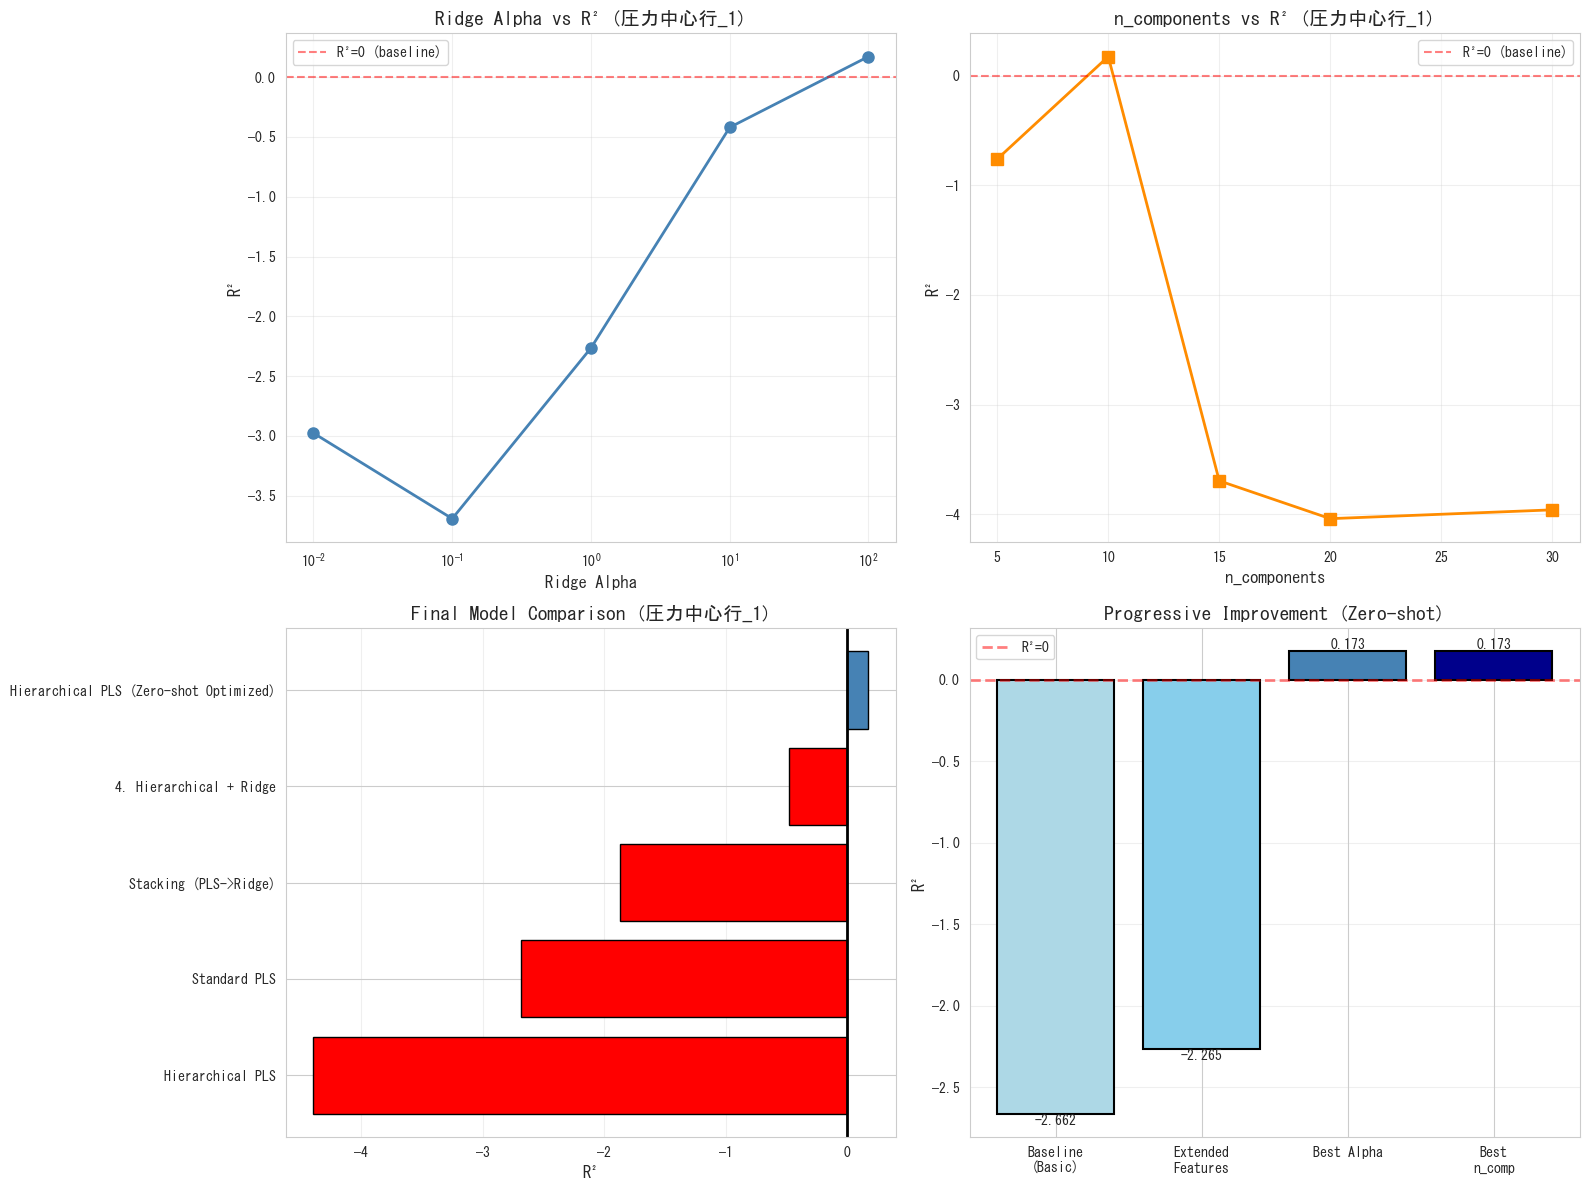


✅ Experiment Complete!

📊 Summary:
   baseline_r2: -2.6621707297000055
   extended_features_r2: -2.265049578210555
   best_alpha: 100.0
   best_alpha_r2: 0.17277877317097157
   best_n_components: 10
   best_n_components_r2: 0.17277877317097157
   final_best_r2: 0.17277877317097157
   final_best_model: Hierarchical PLS (Zero-shot Optimized)

📁 Files saved:
   - zeroshot_improvement_experiments.png
   - zeroshot_improvement_summary.csv


In [11]:
"""
圧力中心行_1に特化したZero-shot改善実験
目標: R²をプラスにする
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import r2_score, mean_squared_error

# ==========================================
# データ読み込み
# ==========================================

with open(r"C:\Users\youli\Desktop\code\20251118_COPモドキ\20251214home\modelA_df_proc.pkl", "rb") as f:
    df_all = pickle.load(f)

df_all['W_absolute'] = df_all['W']

# LR_balance と FB_balance を計算
if 'LR_balance' not in df_all.columns:
    df_all['LR_balance'] = (df_all['F1'] + df_all['F4'] - df_all['F2'] - df_all['F3']) / (df_all['W'] + 1e-8)

if 'FB_balance' not in df_all.columns:
    df_all['FB_balance'] = (df_all['F1'] + df_all['F2'] - df_all['F3'] - df_all['F4']) / (df_all['W'] + 1e-8)

df_all = df_all[~df_all['subject_id'].isin([20,24,25,26,27])].copy()

# 特徴量定義
mock_sensor_cols = [
    'subject_id',
    'F1', 'F2', 'F3', 'F4', 'steer', 'pedal', 'W', 
    'LR_balance', 'FB_balance',
    'F1_fnorm', 'F2_fnorm', 'F3_fnorm', 'F4_fnorm',
    'COP_X_phys', 'COP_Y_phys', 'phys_pitch', 'phys_roll', 'phys_torsion',
    'COP_radius', 'COP_angle', 'op_magnitude', 'interact_steer_pedal',
    'steer_COPx', 'steer_COPy', 'pedal_COPx', 'pedal_COPy',
    'COP_X_phys_vel', 'COP_Y_phys_vel', 'W_vel', 'phys_pitch_vel',
    'phys_roll_vel', 'steer_vel', 'pedal_vel', 'interact_steer_vel_COP',
    'F1_hysteresis', 'F2_hysteresis', 'F3_hysteresis', 'F4_hysteresis',
    'W_hysteresis', 'COP_X_phys_hysteresis', 'COP_Y_phys_hysteresis',
    'Interaction_COPX_W', 'Interaction_COPY_W', 
    'W_Power', 'COP_X_phys_Power', 'COP_Y_phys_Power',
    'COP_X_phys_vel_integ', 'COP_X_phys_vel_ma30', 
    'COP_Y_phys_vel_integ', 'COP_Y_phys_vel_ma30', 
    'W_vel_integ', 'W_vel_ma30',
    'phys_pitch_vel_integ', 'phys_pitch_vel_ma30', 
    'phys_roll_vel_integ', 'phys_roll_vel_ma30',
    'F1_init', 'F2_init', 'F3_init', 'F4_init',
    'W_init', 'LR_balance_init', 'FB_balance_init', 'W_absolute'
]

# ★ 圧力中心行_1のみ
target_features_A = ['圧力中心行_1']

available_cols = df_all.columns.tolist()
X_cols = [c for c in mock_sensor_cols if c in available_cols]
Y_cols = [c for c in target_features_A if c in available_cols]

df_raw = df_all[X_cols + Y_cols].dropna()
X_raw = df_raw[X_cols]
y_raw = df_raw[Y_cols]

print(f"✅ Data loaded: {len(df_raw)} samples")
print(f"   Target: {target_features_A[0]}")
print(f"   Subjects: {sorted(X_raw['subject_id'].unique())}")

# ==========================================
# 実験セットアップ
# ==========================================

import my_module4 as mm

SKIP_BIAS_KEYWORDS = [
    'subject_id', '_init', '_vel', '_hysteresis', '_CLR', '_Power', '_absolute'
]

# ==========================================
# 実験1: ベースライン（基本的な静的特徴量）
# ==========================================

print("\n" + "="*80)
print("🧪 Experiment 1: Baseline (Basic Static Features)")
print("="*80)

STATIC_FEATURES_BASIC = [
    'W_init', 'W_absolute',
    'F1_init', 'F2_init', 'F3_init', 'F4_init',
    'LR_balance_init', 'FB_balance_init'
]

PREPROCESSING_CONFIGS_BASE = {
    'hierarchical_pls': {'scale_x': False, 'n_components': 10},
    'hierarchical_zeroshot': {'scale_x': False, 'n_components': 10},
}

strategies_baseline = [
    mm.HierarchicalPLSStrategy(
        config=PREPROCESSING_CONFIGS_BASE['hierarchical_pls']
    ),
    
    mm.HierarchicalPLSStrategyZeroShot(
        name="Hierarchical PLS (Zero-shot)",
        config=PREPROCESSING_CONFIGS_BASE['hierarchical_zeroshot'],
        static_features_cols=STATIC_FEATURES_BASIC,
        ridge_alpha=1.0
    )
]

comparator_base = mm.ModelComparator(strategies_baseline, smooth_y=True, skip_bias_cols=SKIP_BIAS_KEYWORDS)

results_baseline = comparator_base.run_comparison(
    X_raw, y_raw, 
    target_col='圧力中心行_1', 
    holdout_subject_id=14
)

print("\n📊 Baseline Results:")
print(results_baseline[['Model', 'R2', 'RMSE']])

# ==========================================
# 実験2: 拡張版静的特徴量（すべての_init列）
# ==========================================

print("\n" + "="*80)
print("🧪 Experiment 2: Extended Static Features (All _init columns)")
print("="*80)

# 前処理して全ての_init列を取得
X_proc_temp = comparator_base.preprocess_common(X_raw)
STATIC_FEATURES_EXTENDED = [col for col in X_proc_temp.columns if '_init' in col and col in X_proc_temp.columns]

print(f"\n✅ Extended static features ({len(STATIC_FEATURES_EXTENDED)} features):")
for feat in STATIC_FEATURES_EXTENDED:
    print(f"   - {feat}")

strategies_extended = [
    mm.HierarchicalPLSStrategy(
        config=PREPROCESSING_CONFIGS_BASE['hierarchical_pls']
    ),
    
    mm.HierarchicalPLSStrategyZeroShot(
        name="Hierarchical PLS (Zero-shot Extended)",
        config={'scale_x': False, 'n_components': 10},
        static_features_cols=STATIC_FEATURES_EXTENDED,
        ridge_alpha=1.0
    )
]

comparator_ext = mm.ModelComparator(strategies_extended, smooth_y=True, skip_bias_cols=SKIP_BIAS_KEYWORDS)

results_extended = comparator_ext.run_comparison(
    X_raw, y_raw, 
    target_col='圧力中心行_1', 
    holdout_subject_id=14
)

print("\n📊 Extended Results:")
print(results_extended[['Model', 'R2', 'RMSE']])

# ==========================================
# 実験3: Ridge alphaのチューニング
# ==========================================

print("\n" + "="*80)
print("🧪 Experiment 3: Ridge Alpha Tuning")
print("="*80)

alpha_values = [0.01, 0.1, 1.0, 10.0, 100.0]
results_alpha_tuning = []

for alpha in alpha_values:
    print(f"\n   Testing alpha={alpha}...")
    
    strategies_alpha = [
        mm.HierarchicalPLSStrategy(
            config=PREPROCESSING_CONFIGS_BASE['hierarchical_pls']
        ),
        
        mm.HierarchicalPLSStrategyZeroShot(
            name=f"Zero-shot (alpha={alpha})",
            config={'scale_x': False, 'n_components': 10},
            static_features_cols=STATIC_FEATURES_EXTENDED,
            ridge_alpha=alpha
        )
    ]
    
    comparator_alpha = mm.ModelComparator(strategies_alpha, smooth_y=True, skip_bias_cols=SKIP_BIAS_KEYWORDS)
    
    results_alpha = comparator_alpha.run_comparison(
        X_raw, y_raw, 
        target_col='圧力中心行_1', 
        holdout_subject_id=14
    )
    
    # Zero-shotの結果だけ取得
    zeroshot_result = results_alpha[results_alpha['Model'].str.contains('Zero-shot')].iloc[0]
    
    results_alpha_tuning.append({
        'alpha': alpha,
        'R2': zeroshot_result['R2'],
        'RMSE': zeroshot_result['RMSE']
    })
    
    print(f"      R² = {zeroshot_result['R2']:.4f}, RMSE = {zeroshot_result['RMSE']:.4f}")

df_alpha_tuning = pd.DataFrame(results_alpha_tuning)

print("\n📊 Alpha Tuning Summary:")
print(df_alpha_tuning)

best_alpha_idx = df_alpha_tuning['R2'].idxmax()
best_alpha = df_alpha_tuning.loc[best_alpha_idx, 'alpha']
best_r2 = df_alpha_tuning.loc[best_alpha_idx, 'R2']

print(f"\n✅ Best alpha: {best_alpha} (R² = {best_r2:.4f})")

# ==========================================
# 実験4: n_componentsのチューニング
# ==========================================

print("\n" + "="*80)
print("🧪 Experiment 4: n_components Tuning")
print("="*80)

n_components_values = [5, 10, 15, 20, 30]
results_ncomp_tuning = []

for n_comp in n_components_values:
    print(f"\n   Testing n_components={n_comp}...")
    
    strategies_ncomp = [
        mm.HierarchicalPLSStrategy(
            config={'scale_x': False, 'n_components': n_comp}
        ),
        
        mm.HierarchicalPLSStrategyZeroShot(
            name=f"Zero-shot (n_comp={n_comp})",
            config={'scale_x': False, 'n_components': n_comp},
            static_features_cols=STATIC_FEATURES_EXTENDED,
            ridge_alpha=best_alpha  # 最良のalphaを使用
        )
    ]
    
    comparator_ncomp = mm.ModelComparator(strategies_ncomp, smooth_y=True, skip_bias_cols=SKIP_BIAS_KEYWORDS)
    
    try:
        results_ncomp = comparator_ncomp.run_comparison(
            X_raw, y_raw, 
            target_col='圧力中心行_1', 
            holdout_subject_id=14
        )
        
        zeroshot_result = results_ncomp[results_ncomp['Model'].str.contains('Zero-shot')].iloc[0]
        
        results_ncomp_tuning.append({
            'n_components': n_comp,
            'R2': zeroshot_result['R2'],
            'RMSE': zeroshot_result['RMSE']
        })
        
        print(f"      R² = {zeroshot_result['R2']:.4f}, RMSE = {zeroshot_result['RMSE']:.4f}")
    
    except Exception as e:
        print(f"      Error: {e}")
        results_ncomp_tuning.append({
            'n_components': n_comp,
            'R2': np.nan,
            'RMSE': np.nan
        })

df_ncomp_tuning = pd.DataFrame(results_ncomp_tuning)

print("\n📊 n_components Tuning Summary:")
print(df_ncomp_tuning)

best_ncomp_idx = df_ncomp_tuning['R2'].idxmax()
best_ncomp = df_ncomp_tuning.loc[best_ncomp_idx, 'n_components']
best_ncomp_r2 = df_ncomp_tuning.loc[best_ncomp_idx, 'R2']

print(f"\n✅ Best n_components: {best_ncomp} (R² = {best_ncomp_r2:.4f})")

# ==========================================
# 実験5: 最終モデル（最適パラメータ）
# ==========================================

print("\n" + "="*80)
print("🧪 Experiment 5: Final Model (Optimal Parameters)")
print("="*80)

print(f"\n🎯 Optimal parameters:")
print(f"   - Static features: Extended ({len(STATIC_FEATURES_EXTENDED)} features)")
print(f"   - Ridge alpha: {best_alpha}")
print(f"   - n_components: {best_ncomp}")

strategies_final = [
    mm.StandardPLSStrategy(
        config={'scale_x': True, 'n_components': best_ncomp}
    ),
    
    mm.HierarchicalPLSStrategy(
        config={'scale_x': False, 'n_components': best_ncomp}
    ),
    
    mm.StackingPLS2RidgeStrategy(
        config={'scale_x': True, 'n_components': best_ncomp, 'scale_state2': False},
        ridge_alpha=1.0,
        static_cols=STATIC_FEATURES_EXTENDED
    ),
    
    mm.HierarchicalRidgeHybridStrategy(
        config={'scale_x': False, 'n_components': best_ncomp, 'scale_stage2': False},
        static_cols=STATIC_FEATURES_EXTENDED
    ),
    
    mm.HierarchicalPLSStrategyZeroShot(
        name="Hierarchical PLS (Zero-shot Optimized)",
        config={'scale_x': False, 'n_components': best_ncomp},
        static_features_cols=STATIC_FEATURES_EXTENDED,
        ridge_alpha=best_alpha
    )
]

comparator_final = mm.ModelComparator(strategies_final, smooth_y=True, skip_bias_cols=SKIP_BIAS_KEYWORDS)

results_final = comparator_final.run_comparison(
    X_raw, y_raw, 
    target_col='圧力中心行_1', 
    holdout_subject_id=14
)

print("\n" + "="*80)
print("🏆 Final Results (圧力中心行_1)")
print("="*80)
print(results_final.sort_values('R2', ascending=False)[['Model', 'Best_N', 'R2', 'RMSE']])

# ==========================================
# 可視化: 実験結果の比較
# ==========================================

print("\n📊 Creating visualization...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 実験1: Alpha Tuning
ax = axes[0, 0]
ax.plot(df_alpha_tuning['alpha'], df_alpha_tuning['R2'], 
        marker='o', linewidth=2, markersize=8, color='steelblue')
ax.axhline(y=0, color='r', linestyle='--', alpha=0.5, label='R²=0 (baseline)')
ax.set_xscale('log')
ax.set_xlabel('Ridge Alpha', fontsize=12, fontweight='bold')
ax.set_ylabel('R²', fontsize=12, fontweight='bold')
ax.set_title('Ridge Alpha vs R² (圧力中心行_1)', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend()

# 実験2: n_components Tuning
ax = axes[0, 1]
ax.plot(df_ncomp_tuning['n_components'], df_ncomp_tuning['R2'], 
        marker='s', linewidth=2, markersize=8, color='darkorange')
ax.axhline(y=0, color='r', linestyle='--', alpha=0.5, label='R²=0 (baseline)')
ax.set_xlabel('n_components', fontsize=12, fontweight='bold')
ax.set_ylabel('R²', fontsize=12, fontweight='bold')
ax.set_title('n_components vs R² (圧力中心行_1)', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend()

# 実験3: 最終結果の比較
ax = axes[1, 0]
results_sorted = results_final.sort_values('R2', ascending=True)
colors = ['red' if r2 < 0 else 'steelblue' for r2 in results_sorted['R2']]
ax.barh(range(len(results_sorted)), results_sorted['R2'], color=colors, edgecolor='black')
ax.set_yticks(range(len(results_sorted)))
ax.set_yticklabels(results_sorted['Model'], fontsize=10)
ax.axvline(x=0, color='black', linestyle='-', linewidth=2)
ax.set_xlabel('R²', fontsize=12, fontweight='bold')
ax.set_title('Final Model Comparison (圧力中心行_1)', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# 実験4: 改善度の比較
ax = axes[1, 1]
improvement_data = [
    {'Method': 'Baseline\n(Basic)', 'R2': results_baseline[results_baseline['Model'].str.contains('Zero-shot')]['R2'].iloc[0]},
    {'Method': 'Extended\nFeatures', 'R2': results_extended[results_extended['Model'].str.contains('Zero-shot')]['R2'].iloc[0]},
    {'Method': 'Best Alpha', 'R2': best_r2},
    {'Method': 'Best\nn_comp', 'R2': best_ncomp_r2},
]
df_improvement = pd.DataFrame(improvement_data)

bars = ax.bar(df_improvement['Method'], df_improvement['R2'], 
              color=['lightblue', 'skyblue', 'steelblue', 'darkblue'], 
              edgecolor='black', linewidth=1.5)
ax.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.5, label='R²=0')
ax.set_ylabel('R²', fontsize=12, fontweight='bold')
ax.set_title('Progressive Improvement (Zero-shot)', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3, axis='y')
ax.legend()

# 値を表示
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}',
            ha='center', va='bottom' if height > 0 else 'top',
            fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('zeroshot_improvement_experiments.png', dpi=150, bbox_inches='tight')
print("✅ Saved: zeroshot_improvement_experiments.png")
plt.show()

# ==========================================
# 結果サマリーの保存
# ==========================================

summary = {
    'baseline_r2': results_baseline[results_baseline['Model'].str.contains('Zero-shot')]['R2'].iloc[0],
    'extended_features_r2': results_extended[results_extended['Model'].str.contains('Zero-shot')]['R2'].iloc[0],
    'best_alpha': best_alpha,
    'best_alpha_r2': best_r2,
    'best_n_components': best_ncomp,
    'best_n_components_r2': best_ncomp_r2,
    'final_best_r2': results_final['R2'].max(),
    'final_best_model': results_final.loc[results_final['R2'].idxmax(), 'Model']
}

df_summary = pd.DataFrame([summary])
df_summary.to_csv('zeroshot_improvement_summary.csv', index=False)

print("\n" + "="*80)
print("✅ Experiment Complete!")
print("="*80)

print("\n📊 Summary:")
for key, value in summary.items():
    print(f"   {key}: {value}")

print("\n📁 Files saved:")
print("   - zeroshot_improvement_experiments.png")
print("   - zeroshot_improvement_summary.csv")

✅ Data loaded: 79438 samples
   Target: 圧力中心行_1
   Subjects: [np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(21)]

🧪 Experiment 1: Baseline (Basic Static Features)

🥊 Comparison Start: Target = 圧力中心行_1
   Running Common Preprocessing (X)...
   ✨ Smoothing Target Variable: 圧力中心行_1
   Train: 70571 samples, Test: 8867 samples (Subject 14)
   🏃 Running: Hierarchical PLS...
      -> R2: -4.3946 (N=None)
   🏃 Running: Hierarchical PLS (Zero-shot)...
   🏃 Running: Hierarchical PLS (Zero-shot)...
      Dynamic features: 86 columns
      Static features: 8 columns

✅ Gain/Offset Predictors Trained:
   - Gain R²: 0.470
   - Offset R²: 0.460

📊 Feature Importance (Coefficients):
Feature                    Gain     Offset
------------------------------------------
W_init                   0.1560    -5.1886
W_absolute               0.1149    -4.6408
F1_init                  0.1041    -2.5394
F2_init                  0.1808   

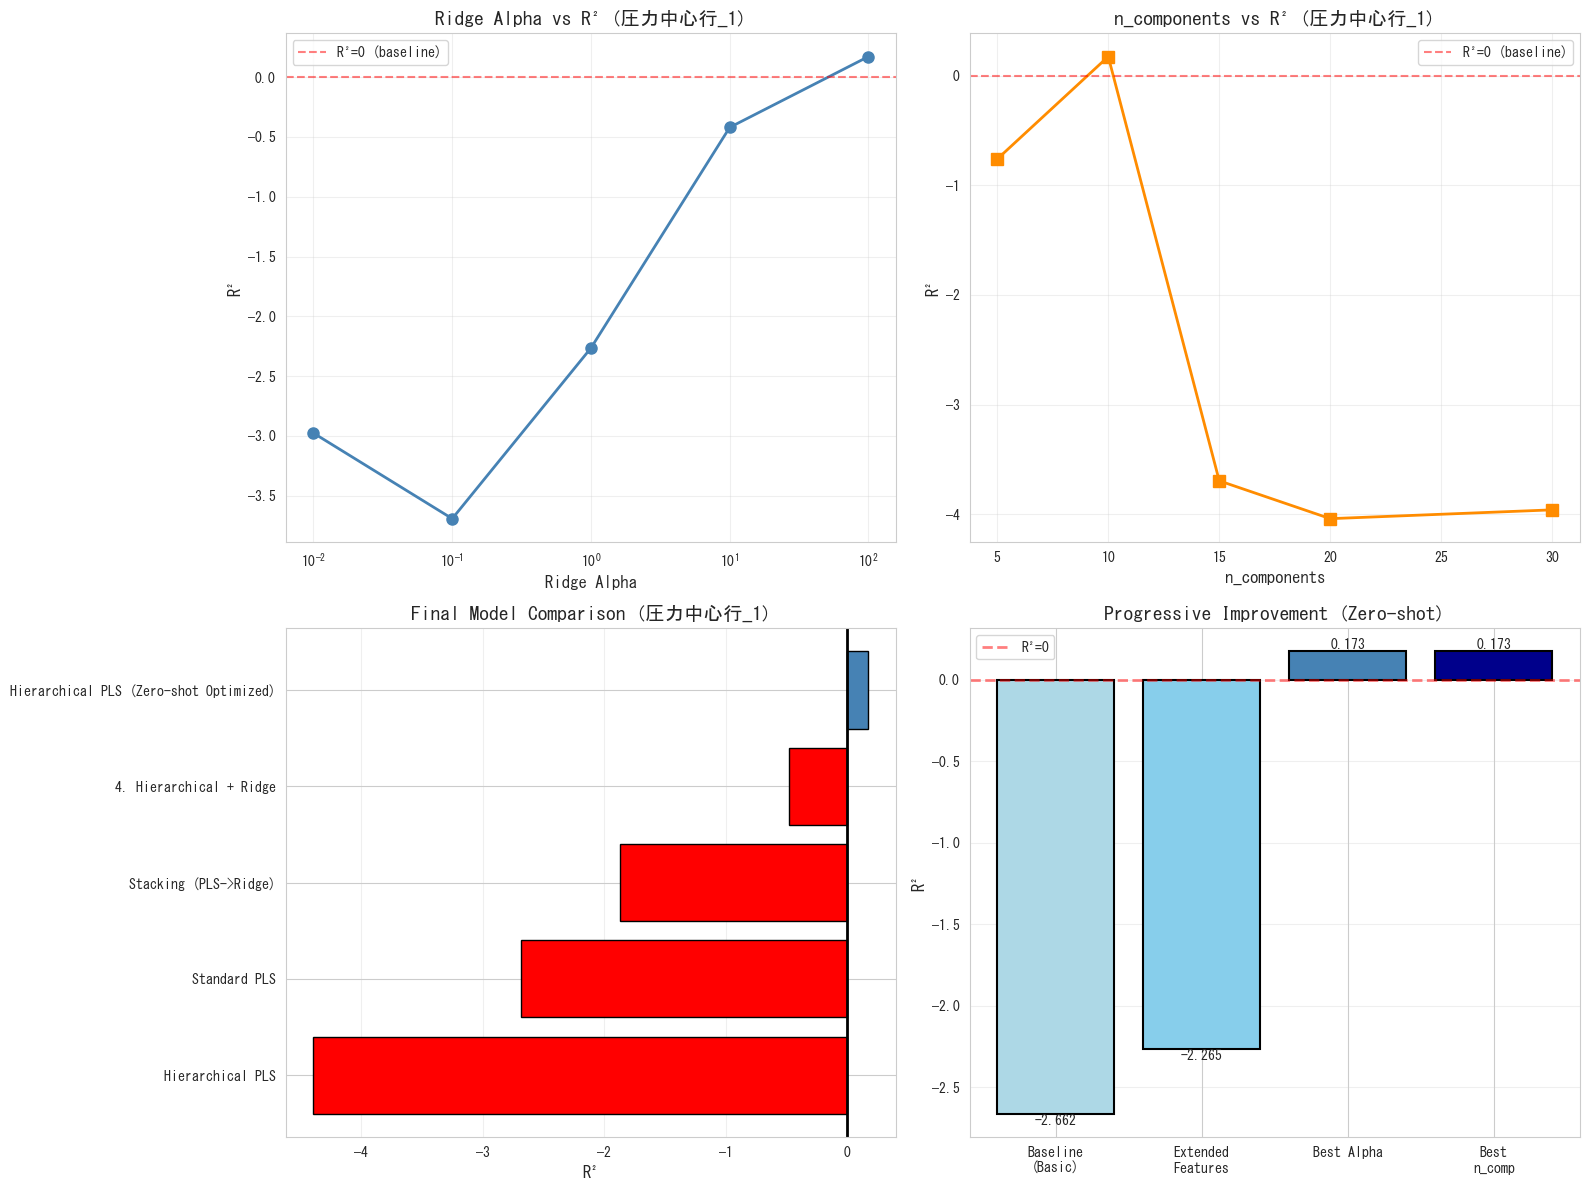


✅ Experiment Complete!

📊 Summary:
   baseline_r2: -2.6621707297000055
   extended_features_r2: -2.265049578210555
   best_alpha: 100.0
   best_alpha_r2: 0.17277877317097157
   best_n_components: 10
   best_n_components_r2: 0.17277877317097157
   final_best_r2: 0.17277877317097157
   final_best_model: Hierarchical PLS (Zero-shot Optimized)

📁 Files saved:
   - zeroshot_improvement_experiments.png
   - zeroshot_improvement_summary.csv


✅ Data loaded: 79438 samples
   Target: 圧力中心行_1
   Subjects: [np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(21)]

✅ HierarchicalPLSStrategyZeroShot found in my_module4

📊 Preprocessing to get extended static features
   Running Common Preprocessing (X)...

✅ Found 47 extended static features:
   1. F1_init
   2. F2_init
   3. F3_init
   4. F4_init
   5. steer_init
   6. pedal_init
   7. W_init
   8. LR_balance_init
   9. FB_balance_init
   10. F1_fnorm_init
   11. F2_fnorm_init
   12. F3_fnorm_init
   13. F4_fnorm_init
   14. COP_X_phys_init
   15. COP_Y_phys_init
   16. phys_pitch_init
   17. phys_roll_init
   18. phys_torsion_init
   19. COP_radius_init
   20. COP_angle_init
   21. op_magnitude_init
   22. interact_steer_pedal_init
   23. steer_COPx_init
   24. steer_COPy_init
   25. pedal_COPx_init
   26. pedal_COPy_init
   27. COP_X_phys_vel_init
   28. COP_Y_phys_vel_init
   29. W_vel_init
   30. phys_pitch

C:\Users\youli\AppData\Local\Temp\ipykernel_7992\3106341873.py:215: UserWarning: Glyph 22311 (\N{CJK UNIFIED IDEOGRAPH-5727}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_7992\3106341873.py:215: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_7992\3106341873.py:215: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_7992\3106341873.py:215: UserWarning: Glyph 24515 (\N{CJK UNIFIED IDEOGRAPH-5FC3}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_7992\3106341873.py:215: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_7992\3106341873.py:216: UserWarning: Glyph 22311 (\N{CJK UNIFIED IDEOGRAPH-5727})


✅ Saved: quick_comparison_extended_features.png


c:\Users\youli\Desktop\code\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22311 (\N{CJK UNIFIED IDEOGRAPH-5727}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\youli\Desktop\code\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\youli\Desktop\code\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\youli\Desktop\code\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24515 (\N{CJK UNIFIED IDEOGRAPH-5FC3}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\youli\Desktop\code\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing fr

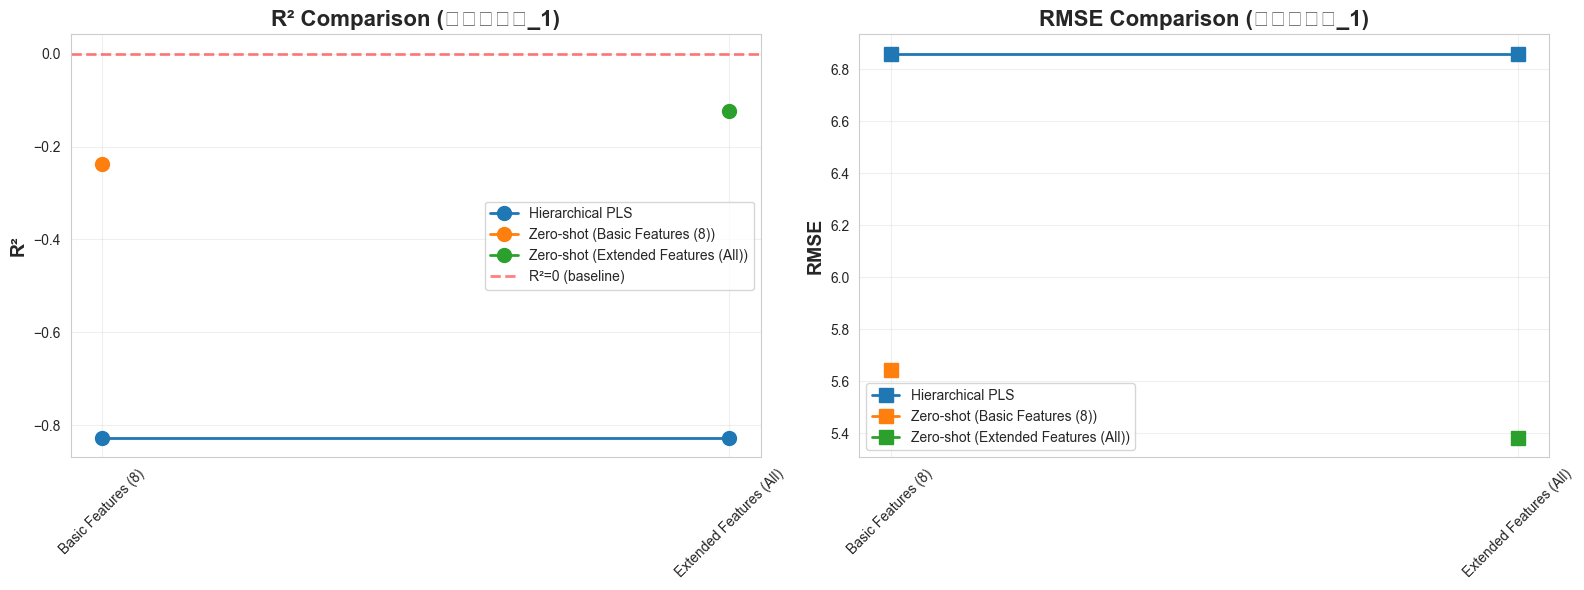


📈 Improvement Analysis

📊 Zero-shot Performance:
   Basic Features:    R² = -0.2366
   Extended Features: R² = -0.1243
   Improvement:       ΔR² = +0.1123

✅ Extended features IMPROVED the model!

⚠️  R² is still negative (-0.1243)
   → Need further improvements (alpha tuning, n_components, etc.)

📁 Saved: quick_experiment_results.csv

📊 Creating Gain/Offset Prediction Plots
   Running Common Preprocessing (X)...

   Training model with Basic features (8 features)...

✅ Gain/Offset Predictors Trained:
   - Gain R²: 0.434
   - Offset R²: 0.420

📊 Feature Importance (Coefficients):
Feature                    Gain     Offset
------------------------------------------
W_init                   0.2386    -6.8572
W_absolute               0.1774    -6.0818
F1_init                  0.1541    -4.0057
F2_init                  0.2381    -6.8113
F3_init                 -0.0684     1.8079
F4_init                 -0.0851     2.1519
LR_balance_init         -0.0124     0.6065
FB_balance_init          

C:\Users\youli\AppData\Local\Temp\ipykernel_7992\3106341873.py:415: UserWarning: Glyph 22311 (\N{CJK UNIFIED IDEOGRAPH-5727}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_7992\3106341873.py:415: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_7992\3106341873.py:415: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_7992\3106341873.py:415: UserWarning: Glyph 24515 (\N{CJK UNIFIED IDEOGRAPH-5FC3}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_7992\3106341873.py:415: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_7992\3106341873.py:416: UserWarning: Glyph 22311 (\N{CJK UNIFIED IDEOGRAPH-5727})


✅ Saved: gain_offset_comparison_basic_vs_extended.png


c:\Users\youli\Desktop\code\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22311 (\N{CJK UNIFIED IDEOGRAPH-5727}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\youli\Desktop\code\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\youli\Desktop\code\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\youli\Desktop\code\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24515 (\N{CJK UNIFIED IDEOGRAPH-5FC3}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\youli\Desktop\code\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing fr

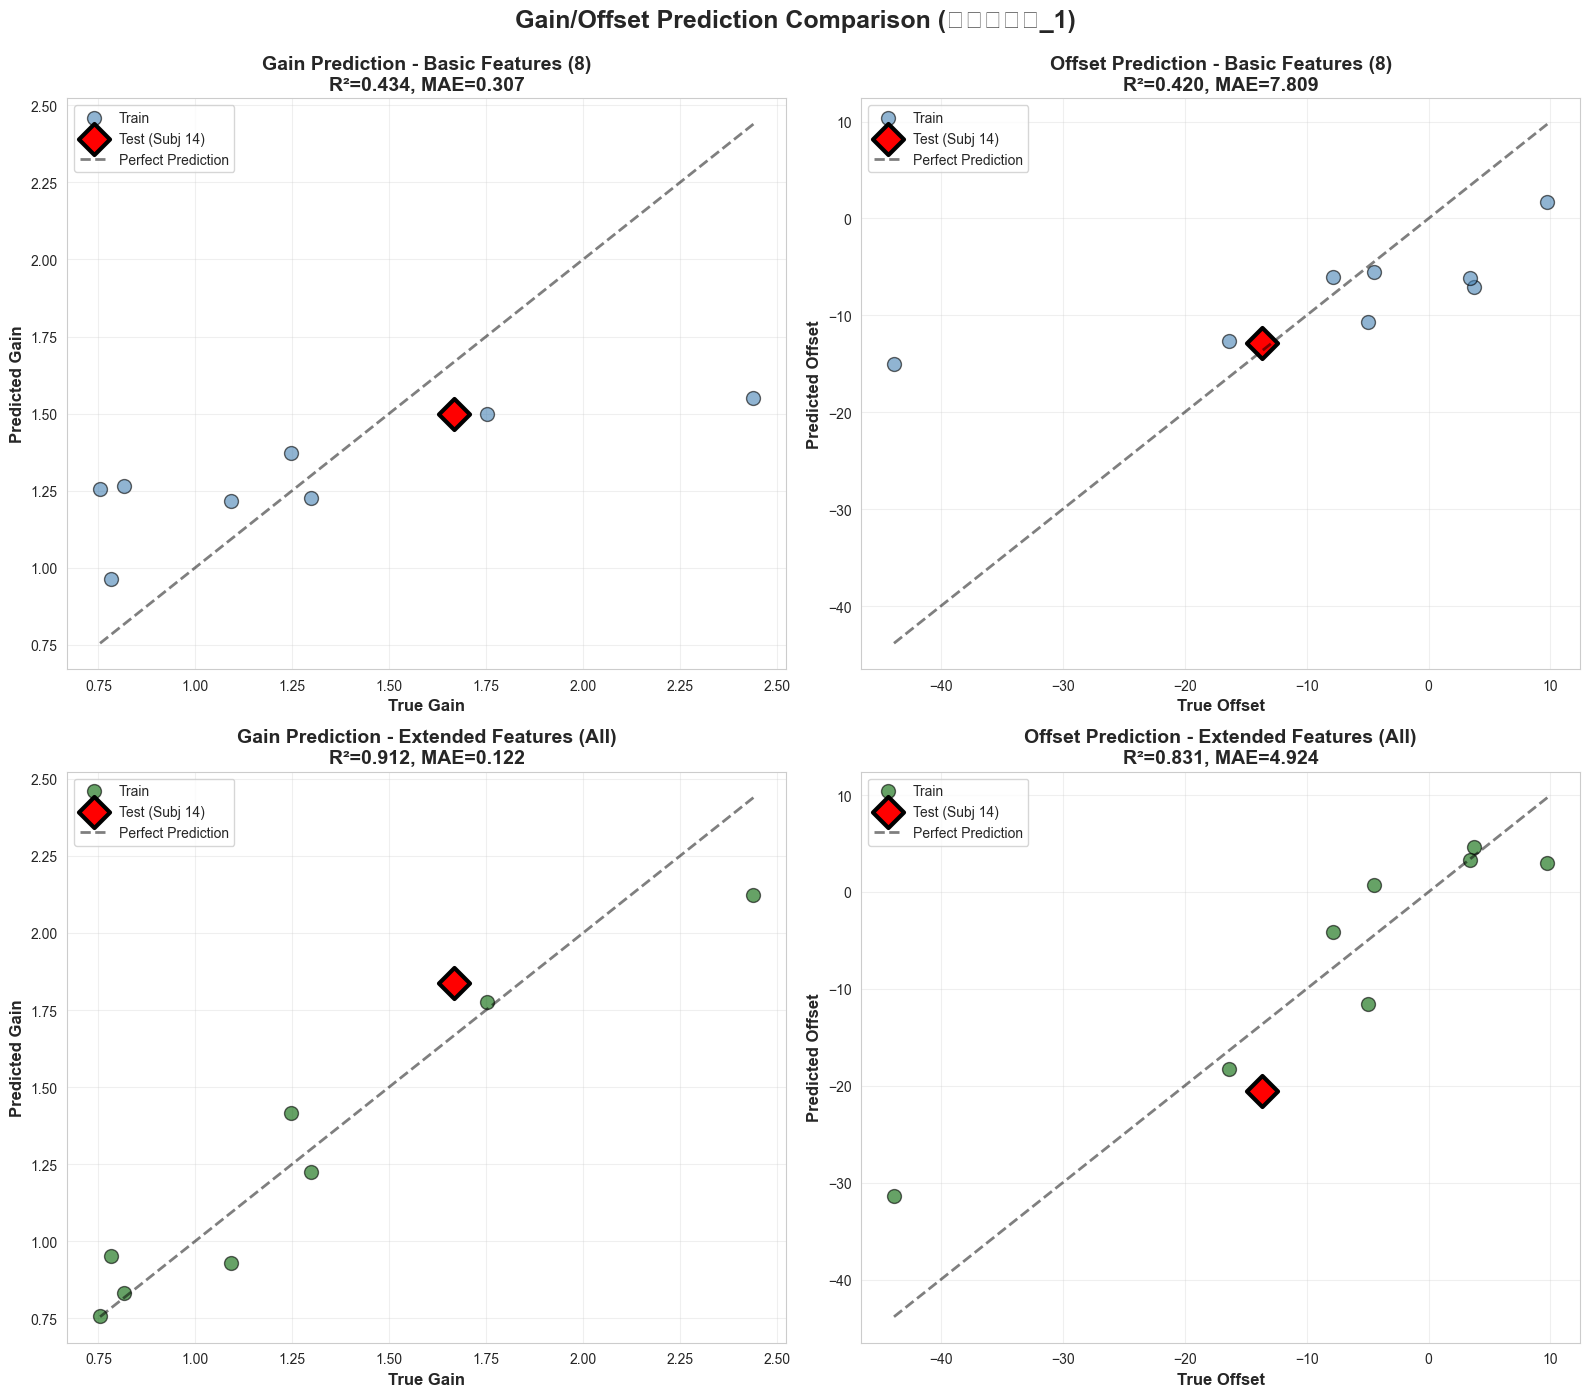


📊 Subject 14 (Test) - Gain/Offset Predictions

【Basic Features】
  Gain:
    True:      1.6668
    Predicted: 1.4969
    Error:     0.1699

  Offset:
    True:      -13.6192
    Predicted: -12.8457
    Error:     0.7735

【Extended Features】
  Gain:
    True:      1.6668
    Predicted: 1.8382
    Error:     0.1714

  Offset:
    True:      -13.6192
    Predicted: -20.5126
    Error:     6.8935

【Improvement (Error Reduction)】
  Gain error:   0.1699 → 0.1714 (Δ=-0.0015)
  Offset error: 0.7735 → 6.8935 (Δ=-6.1200)

  ⚠️  Gain prediction got WORSE by 0.0015
  ⚠️  Offset prediction got WORSE by 6.1200

📁 Saved: subject_gain_offset_predictions.csv

✅ Quick Experiment Complete!


In [18]:
"""
圧力中心行_1に特化したZero-shot改善実験（簡易版）
name引数の問題を回避
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import r2_score, mean_squared_error

# ==========================================
# データ読み込み
# ==========================================

with open(r"C:\Users\youli\Desktop\code\20251118_COPモドキ\20251214home\modelA_df_proc.pkl", "rb") as f:
    df_all = pickle.load(f)

df_all['W_absolute'] = df_all['W']

# LR_balance と FB_balance を計算
if 'LR_balance' not in df_all.columns:
    df_all['LR_balance'] = (df_all['F1'] + df_all['F4'] - df_all['F2'] - df_all['F3']) / (df_all['W'] + 1e-8)

if 'FB_balance' not in df_all.columns:
    df_all['FB_balance'] = (df_all['F1'] + df_all['F2'] - df_all['F3'] - df_all['F4']) / (df_all['W'] + 1e-8)

df_all = df_all[~df_all['subject_id'].isin([20,24,25,26,27])].copy()

# 特徴量定義
mock_sensor_cols = [
    'subject_id',
    'F1', 'F2', 'F3', 'F4', 'steer', 'pedal', 'W', 
    'LR_balance', 'FB_balance',
    'F1_fnorm', 'F2_fnorm', 'F3_fnorm', 'F4_fnorm',
    'COP_X_phys', 'COP_Y_phys', 'phys_pitch', 'phys_roll', 'phys_torsion',
    'COP_radius', 'COP_angle', 'op_magnitude', 'interact_steer_pedal',
    'steer_COPx', 'steer_COPy', 'pedal_COPx', 'pedal_COPy',
    'COP_X_phys_vel', 'COP_Y_phys_vel', 'W_vel', 'phys_pitch_vel',
    'phys_roll_vel', 'steer_vel', 'pedal_vel', 'interact_steer_vel_COP',
    'F1_hysteresis', 'F2_hysteresis', 'F3_hysteresis', 'F4_hysteresis',
    'W_hysteresis', 'COP_X_phys_hysteresis', 'COP_Y_phys_hysteresis',
    'Interaction_COPX_W', 'Interaction_COPY_W', 
    'W_Power', 'COP_X_phys_Power', 'COP_Y_phys_Power',
    'COP_X_phys_vel_integ', 'COP_X_phys_vel_ma30', 
    'COP_Y_phys_vel_integ', 'COP_Y_phys_vel_ma30', 
    'W_vel_integ', 'W_vel_ma30',
    'phys_pitch_vel_integ', 'phys_pitch_vel_ma30', 
    'phys_roll_vel_integ', 'phys_roll_vel_ma30',
    'F1_init', 'F2_init', 'F3_init', 'F4_init',
    'W_init', 'LR_balance_init', 'FB_balance_init', 'W_absolute'
]

target_features_A = ['圧力中心行_1']

available_cols = df_all.columns.tolist()
X_cols = [c for c in mock_sensor_cols if c in available_cols]
Y_cols = [c for c in target_features_A if c in available_cols]

df_raw = df_all[X_cols + Y_cols].dropna()
X_raw = df_raw[X_cols]
y_raw = df_raw[Y_cols]

print(f"✅ Data loaded: {len(df_raw)} samples")
print(f"   Target: {target_features_A[0]}")
print(f"   Subjects: {sorted(X_raw['subject_id'].unique())}")

# ==========================================
# 実験セットアップ
# ==========================================

import my_module4 as mm

# HierarchicalPLSStrategyZeroShot クラスを取得
# （my_module4.py に追加済みと仮定）
try:
    ZeroShotStrategy = mm.HierarchicalPLSStrategyZeroShot
    print("\n✅ HierarchicalPLSStrategyZeroShot found in my_module4")
except AttributeError:
    print("\n❌ HierarchicalPLSStrategyZeroShot not found in my_module4")
    print("   Please add the class to my_module4.py first")
    exit(1)

SKIP_BIAS_KEYWORDS = [
    'subject_id', '_init', '_vel', '_hysteresis', '_CLR', '_Power', '_absolute'
]

# ==========================================
# まず前処理して拡張静的特徴量を取得
# ==========================================

print("\n" + "="*80)
print("📊 Preprocessing to get extended static features")
print("="*80)

# ダミーの前処理実行
comparator_temp = mm.ModelComparator(
    [mm.HierarchicalPLSStrategy({'scale_x': False, 'n_components': 10})],
    smooth_y=True, 
    skip_bias_cols=SKIP_BIAS_KEYWORDS
)
X_proc_temp = comparator_temp.preprocess_common(X_raw)

# すべての _init 列を取得
STATIC_FEATURES_EXTENDED = [col for col in X_proc_temp.columns if '_init' in col]

print(f"\n✅ Found {len(STATIC_FEATURES_EXTENDED)} extended static features:")
for i, feat in enumerate(STATIC_FEATURES_EXTENDED):
    print(f"   {i+1}. {feat}")

# ==========================================
# クイック実験: 拡張静的特徴量の効果確認
# ==========================================

print("\n" + "="*80)
print("🧪 Quick Experiment: Extended Static Features Impact")
print("="*80)

# ベースライン（基本静的特徴量）
STATIC_FEATURES_BASIC = [
    'W_init', 'W_absolute',
    'F1_init', 'F2_init', 'F3_init', 'F4_init',
    'LR_balance_init', 'FB_balance_init'
]

configs = {
    'Basic Features (8)': STATIC_FEATURES_BASIC,
    'Extended Features (All)': STATIC_FEATURES_EXTENDED
}

results_comparison = []

for config_name, static_features in configs.items():
    print(f"\n   Testing: {config_name}...")
    print(f"   Static features: {len(static_features)}")
    
    # 利用可能な特徴量のみを使用
    available_static = [col for col in static_features if col in X_proc_temp.columns]
    print(f"   Available: {len(available_static)}/{len(static_features)}")
    
    strategies = [
        mm.HierarchicalPLSStrategy(
            config={'scale_x': False, 'n_components': 10}
        ),
        ZeroShotStrategy(
            name=f"Zero-shot ({config_name})",
            config={'scale_x': False, 'n_components': 10},
            static_features_cols=available_static,
            ridge_alpha=1.0
        )
    ]
    
    comparator = mm.ModelComparator(strategies, smooth_y=True, skip_bias_cols=SKIP_BIAS_KEYWORDS)
    
    results = comparator.run_comparison(
        X_raw, y_raw, 
        target_col='圧力中心行_1', 
        holdout_subject_id=18
    )
    
    # 結果を保存
    for _, row in results.iterrows():
        results_comparison.append({
            'Config': config_name,
            'Model': row['Model'],
            'R2': row['R2'],
            'RMSE': row['RMSE']
        })
    
    print(f"\n   Results:")
    print(results[['Model', 'R2', 'RMSE']].to_string(index=False))

# ==========================================
# 結果の可視化
# ==========================================

df_comparison = pd.DataFrame(results_comparison)

print("\n" + "="*80)
print("📊 Comparison Results")
print("="*80)
print(df_comparison.to_string(index=False))

# プロット
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: R² comparison
ax = axes[0]
for model in df_comparison['Model'].unique():
    mask = df_comparison['Model'] == model
    data = df_comparison[mask]
    ax.plot(data['Config'], data['R2'], marker='o', linewidth=2, markersize=10, label=model)

ax.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.5, label='R²=0 (baseline)')
ax.set_ylabel('R²', fontsize=14, fontweight='bold')
ax.set_title('R² Comparison (圧力中心行_1)', fontsize=16, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# Right: RMSE comparison
ax = axes[1]
for model in df_comparison['Model'].unique():
    mask = df_comparison['Model'] == model
    data = df_comparison[mask]
    ax.plot(data['Config'], data['RMSE'], marker='s', linewidth=2, markersize=10, label=model)

ax.set_ylabel('RMSE', fontsize=14, fontweight='bold')
ax.set_title('RMSE Comparison (圧力中心行_1)', fontsize=16, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('quick_comparison_extended_features.png', dpi=150, bbox_inches='tight')
print("\n✅ Saved: quick_comparison_extended_features.png")
plt.show()

# ==========================================
# 改善度の計算
# ==========================================

print("\n" + "="*80)
print("📈 Improvement Analysis")
print("="*80)

# Zero-shotモデルのみ抽出
df_zeroshot = df_comparison[df_comparison['Model'].str.contains('Zero-shot')]

if len(df_zeroshot) == 2:
    basic_r2 = df_zeroshot[df_zeroshot['Config'] == 'Basic Features (8)']['R2'].iloc[0]
    extended_r2 = df_zeroshot[df_zeroshot['Config'] == 'Extended Features (All)']['R2'].iloc[0]
    
    improvement = extended_r2 - basic_r2
    
    print(f"\n📊 Zero-shot Performance:")
    print(f"   Basic Features:    R² = {basic_r2:.4f}")
    print(f"   Extended Features: R² = {extended_r2:.4f}")
    print(f"   Improvement:       ΔR² = {improvement:+.4f}")
    
    if improvement > 0:
        print(f"\n✅ Extended features IMPROVED the model!")
    elif improvement < 0:
        print(f"\n⚠️  Extended features made it WORSE")
    else:
        print(f"\n➖ No change")
    
    if extended_r2 > 0:
        print(f"\n🎉 SUCCESS! R² is now POSITIVE ({extended_r2:.4f})")
    else:
        print(f"\n⚠️  R² is still negative ({extended_r2:.4f})")
        print(f"   → Need further improvements (alpha tuning, n_components, etc.)")

# 結果保存
df_comparison.to_csv('quick_experiment_results.csv', index=False)
print("\n📁 Saved: quick_experiment_results.csv")

# ==========================================
# Gain/Offset散布図の追加可視化
# ==========================================

print("\n" + "="*80)
print("📊 Creating Gain/Offset Prediction Plots")
print("="*80)

# 前処理実行
comparator_viz = mm.ModelComparator(
    [mm.HierarchicalPLSStrategy({'scale_x': False, 'n_components': 10})],
    smooth_y=True,
    skip_bias_cols=SKIP_BIAS_KEYWORDS
)

X_proc = comparator_viz.preprocess_common(X_raw)
y_target = y_raw['圧力中心行_1'].values
subjects = X_raw['subject_id'].values

# 静的・動的特徴量に分離
available_static = [col for col in STATIC_FEATURES_EXTENDED if col in X_proc.columns]
static_features = X_proc[available_static].values

drop_cols = available_static + ['subject_id']
X_dynamic = X_proc.drop(columns=drop_cols, errors='ignore').values

# 2つの設定でモデル学習
models = {}

for config_name, static_feats in [('Basic', STATIC_FEATURES_BASIC), ('Extended', STATIC_FEATURES_EXTENDED)]:
    available = [col for col in static_feats if col in X_proc.columns]
    static_feat_subset = X_proc[available].values
    
    print(f"\n   Training model with {config_name} features ({len(available)} features)...")
    
    model = mm.HierarchicalPLSModelZeroShot(n_components=10, ridge_alpha=1.0)
    model.fit(X_dynamic, y_target, subjects, static_feat_subset, available)
    
    models[config_name] = {
        'model': model,
        'features': available,
        'static_data': static_feat_subset
    }

# 被験者ごとのデータ収集
unique_subjects = np.unique(subjects)
subject_data_list = []

for subj in unique_subjects:
    mask = (subjects == subj)
    
    row = {'subject_id': subj, 'is_test': (subj == 18)}
    
    for config_name, model_dict in models.items():
        model = model_dict['model']
        static_feat = model_dict['static_data'][mask].mean(axis=0)
        
        # True values
        gain_true = model.subject_gains[subj]
        offset_true = model.subject_offsets[subj]
        
        # Predicted values
        gain_pred = model.gain_predictor.predict([static_feat])[0]
        offset_pred = model.offset_predictor.predict([static_feat])[0]
        
        row[f'gain_true_{config_name}'] = gain_true
        row[f'gain_pred_{config_name}'] = gain_pred
        row[f'offset_true_{config_name}'] = offset_true
        row[f'offset_pred_{config_name}'] = offset_pred
    
    subject_data_list.append(row)

df_subjects = pd.DataFrame(subject_data_list)

# 可視化
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

configs_plot = ['Basic', 'Extended']
colors_train = ['steelblue', 'darkgreen']
titles = ['Basic Features (8)', 'Extended Features (All)']

for idx, (config_name, color, title) in enumerate(zip(configs_plot, colors_train, titles)):
    # Gain
    ax = axes[idx, 0]
    
    train_mask = ~df_subjects['is_test']
    test_mask = df_subjects['is_test']
    
    # 訓練データ
    ax.scatter(df_subjects.loc[train_mask, f'gain_true_{config_name}'],
               df_subjects.loc[train_mask, f'gain_pred_{config_name}'],
               s=100, alpha=0.6, label='Train', color=color, edgecolors='black')
    
    # テストデータ (Subject 14)
    if test_mask.sum() > 0:
        ax.scatter(df_subjects.loc[test_mask, f'gain_true_{config_name}'],
                   df_subjects.loc[test_mask, f'gain_pred_{config_name}'],
                   s=250, alpha=1.0, label='Test (Subj 14)', color='red',
                   edgecolors='black', linewidths=3, marker='D')
    
    # 対角線
    min_val = min(df_subjects[f'gain_true_{config_name}'].min(),
                  df_subjects[f'gain_pred_{config_name}'].min())
    max_val = max(df_subjects[f'gain_true_{config_name}'].max(),
                  df_subjects[f'gain_pred_{config_name}'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, alpha=0.5, label='Perfect Prediction')
    
    # R²とMAE
    r2_gain = r2_score(df_subjects[f'gain_true_{config_name}'],
                       df_subjects[f'gain_pred_{config_name}'])
    mae_gain = np.mean(np.abs(df_subjects[f'gain_true_{config_name}'] -
                              df_subjects[f'gain_pred_{config_name}']))
    
    ax.set_xlabel('True Gain', fontsize=12, fontweight='bold')
    ax.set_ylabel('Predicted Gain', fontsize=12, fontweight='bold')
    ax.set_title(f'Gain Prediction - {title}\nR²={r2_gain:.3f}, MAE={mae_gain:.3f}',
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=10, loc='upper left')
    ax.grid(alpha=0.3)
    
    # Offset
    ax = axes[idx, 1]
    
    # 訓練データ
    ax.scatter(df_subjects.loc[train_mask, f'offset_true_{config_name}'],
               df_subjects.loc[train_mask, f'offset_pred_{config_name}'],
               s=100, alpha=0.6, label='Train', color=color, edgecolors='black')
    
    # テストデータ
    if test_mask.sum() > 0:
        ax.scatter(df_subjects.loc[test_mask, f'offset_true_{config_name}'],
                   df_subjects.loc[test_mask, f'offset_pred_{config_name}'],
                   s=250, alpha=1.0, label='Test (Subj 14)', color='red',
                   edgecolors='black', linewidths=3, marker='D')
    
    # 対角線
    min_val = min(df_subjects[f'offset_true_{config_name}'].min(),
                  df_subjects[f'offset_pred_{config_name}'].min())
    max_val = max(df_subjects[f'offset_true_{config_name}'].max(),
                  df_subjects[f'offset_pred_{config_name}'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, alpha=0.5, label='Perfect Prediction')
    
    # R²とMAE
    r2_offset = r2_score(df_subjects[f'offset_true_{config_name}'],
                         df_subjects[f'offset_pred_{config_name}'])
    mae_offset = np.mean(np.abs(df_subjects[f'offset_true_{config_name}'] -
                                df_subjects[f'offset_pred_{config_name}']))
    
    ax.set_xlabel('True Offset', fontsize=12, fontweight='bold')
    ax.set_ylabel('Predicted Offset', fontsize=12, fontweight='bold')
    ax.set_title(f'Offset Prediction - {title}\nR²={r2_offset:.3f}, MAE={mae_offset:.3f}',
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=10, loc='upper left')
    ax.grid(alpha=0.3)

plt.suptitle('Gain/Offset Prediction Comparison (圧力中心行_1)', fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('gain_offset_comparison_basic_vs_extended.png', dpi=150, bbox_inches='tight')
print("\n✅ Saved: gain_offset_comparison_basic_vs_extended.png")
plt.show()

# Subject 14 の詳細表示
if test_mask.sum() > 0:
    print("\n" + "="*80)
    print("📊 Subject 14 (Test) - Gain/Offset Predictions")
    print("="*80)
    
    subj14 = df_subjects[df_subjects['subject_id'] == 18].iloc[0]
    
    print("\n【Basic Features】")
    print(f"  Gain:")
    print(f"    True:      {subj14['gain_true_Basic']:.4f}")
    print(f"    Predicted: {subj14['gain_pred_Basic']:.4f}")
    print(f"    Error:     {abs(subj14['gain_true_Basic'] - subj14['gain_pred_Basic']):.4f}")
    
    print(f"\n  Offset:")
    print(f"    True:      {subj14['offset_true_Basic']:.4f}")
    print(f"    Predicted: {subj14['offset_pred_Basic']:.4f}")
    print(f"    Error:     {abs(subj14['offset_true_Basic'] - subj14['offset_pred_Basic']):.4f}")
    
    print("\n【Extended Features】")
    print(f"  Gain:")
    print(f"    True:      {subj14['gain_true_Extended']:.4f}")
    print(f"    Predicted: {subj14['gain_pred_Extended']:.4f}")
    print(f"    Error:     {abs(subj14['gain_true_Extended'] - subj14['gain_pred_Extended']):.4f}")
    
    print(f"\n  Offset:")
    print(f"    True:      {subj14['offset_true_Extended']:.4f}")
    print(f"    Predicted: {subj14['offset_pred_Extended']:.4f}")
    print(f"    Error:     {abs(subj14['offset_true_Extended'] - subj14['offset_pred_Extended']):.4f}")
    
    # 改善度の計算
    gain_error_basic = abs(subj14['gain_true_Basic'] - subj14['gain_pred_Basic'])
    gain_error_extended = abs(subj14['gain_true_Extended'] - subj14['gain_pred_Extended'])
    gain_improvement = gain_error_basic - gain_error_extended
    
    offset_error_basic = abs(subj14['offset_true_Basic'] - subj14['offset_pred_Basic'])
    offset_error_extended = abs(subj14['offset_true_Extended'] - subj14['offset_pred_Extended'])
    offset_improvement = offset_error_basic - offset_error_extended
    
    print("\n【Improvement (Error Reduction)】")
    print(f"  Gain error:   {gain_error_basic:.4f} → {gain_error_extended:.4f} (Δ={gain_improvement:+.4f})")
    print(f"  Offset error: {offset_error_basic:.4f} → {offset_error_extended:.4f} (Δ={offset_improvement:+.4f})")
    
    if gain_improvement > 0:
        print(f"\n  ✅ Gain prediction IMPROVED by {gain_improvement:.4f}")
    elif gain_improvement < 0:
        print(f"\n  ⚠️  Gain prediction got WORSE by {abs(gain_improvement):.4f}")
    
    if offset_improvement > 0:
        print(f"  ✅ Offset prediction IMPROVED by {offset_improvement:.4f}")
    elif offset_improvement < 0:
        print(f"  ⚠️  Offset prediction got WORSE by {abs(offset_improvement):.4f}")

# データフレーム保存
df_subjects.to_csv('subject_gain_offset_predictions.csv', index=False)
print("\n📁 Saved: subject_gain_offset_predictions.csv")

print("\n" + "="*80)
print("✅ Quick Experiment Complete!")
print("="*80)

✅ Data loaded: 79438 samples
   Target: 圧力中心行_1
   Running Common Preprocessing (X)...

📊 Using 47 extended static features

🔬 Training and Predicting
   Running Common Preprocessing (X)...

📊 Dataset split:
   Train: 70571 samples
   Test:  8867 samples (Subject 14)

   🏃 Training: Hierarchical PLS...
      Train: R² = 0.7127, RMSE = 2.7612
      Test:  R² = -5.1595, RMSE = 7.1983

   🏃 Training: Hierarchical PLS (Zero-shot)...
   🏃 Running: Hierarchical PLS (Zero-shot)...
      Dynamic features: 47 columns
      Static features: 47 columns

✅ Gain/Offset Predictors Trained:
   - Gain R²: 0.961
   - Offset R²: 0.908

📊 Feature Importance (Coefficients):
Feature                    Gain     Offset
------------------------------------------
F1_init                  0.0037    -0.1012
F2_init                  0.0340    -1.3694
F3_init                  0.0212    -1.0045
F4_init                  0.0005    -0.2082
steer_init               0.0249     0.0251
pedal_init              -0.0091     

C:\Users\youli\AppData\Local\Temp\ipykernel_7992\611563318.py:211: UserWarning: Glyph 22311 (\N{CJK UNIFIED IDEOGRAPH-5727}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_7992\611563318.py:211: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_7992\611563318.py:211: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_7992\611563318.py:211: UserWarning: Glyph 24515 (\N{CJK UNIFIED IDEOGRAPH-5FC3}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_7992\611563318.py:211: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_7992\611563318.py:212: UserWarning: Glyph 22311 (\N{CJK UNIFIED IDEOGRAPH-5727}) missi

✅ Saved: zeroshot_vs_default_scatter.png


c:\Users\youli\Desktop\code\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22311 (\N{CJK UNIFIED IDEOGRAPH-5727}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\youli\Desktop\code\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\youli\Desktop\code\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\youli\Desktop\code\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24515 (\N{CJK UNIFIED IDEOGRAPH-5FC3}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\youli\Desktop\code\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing fr

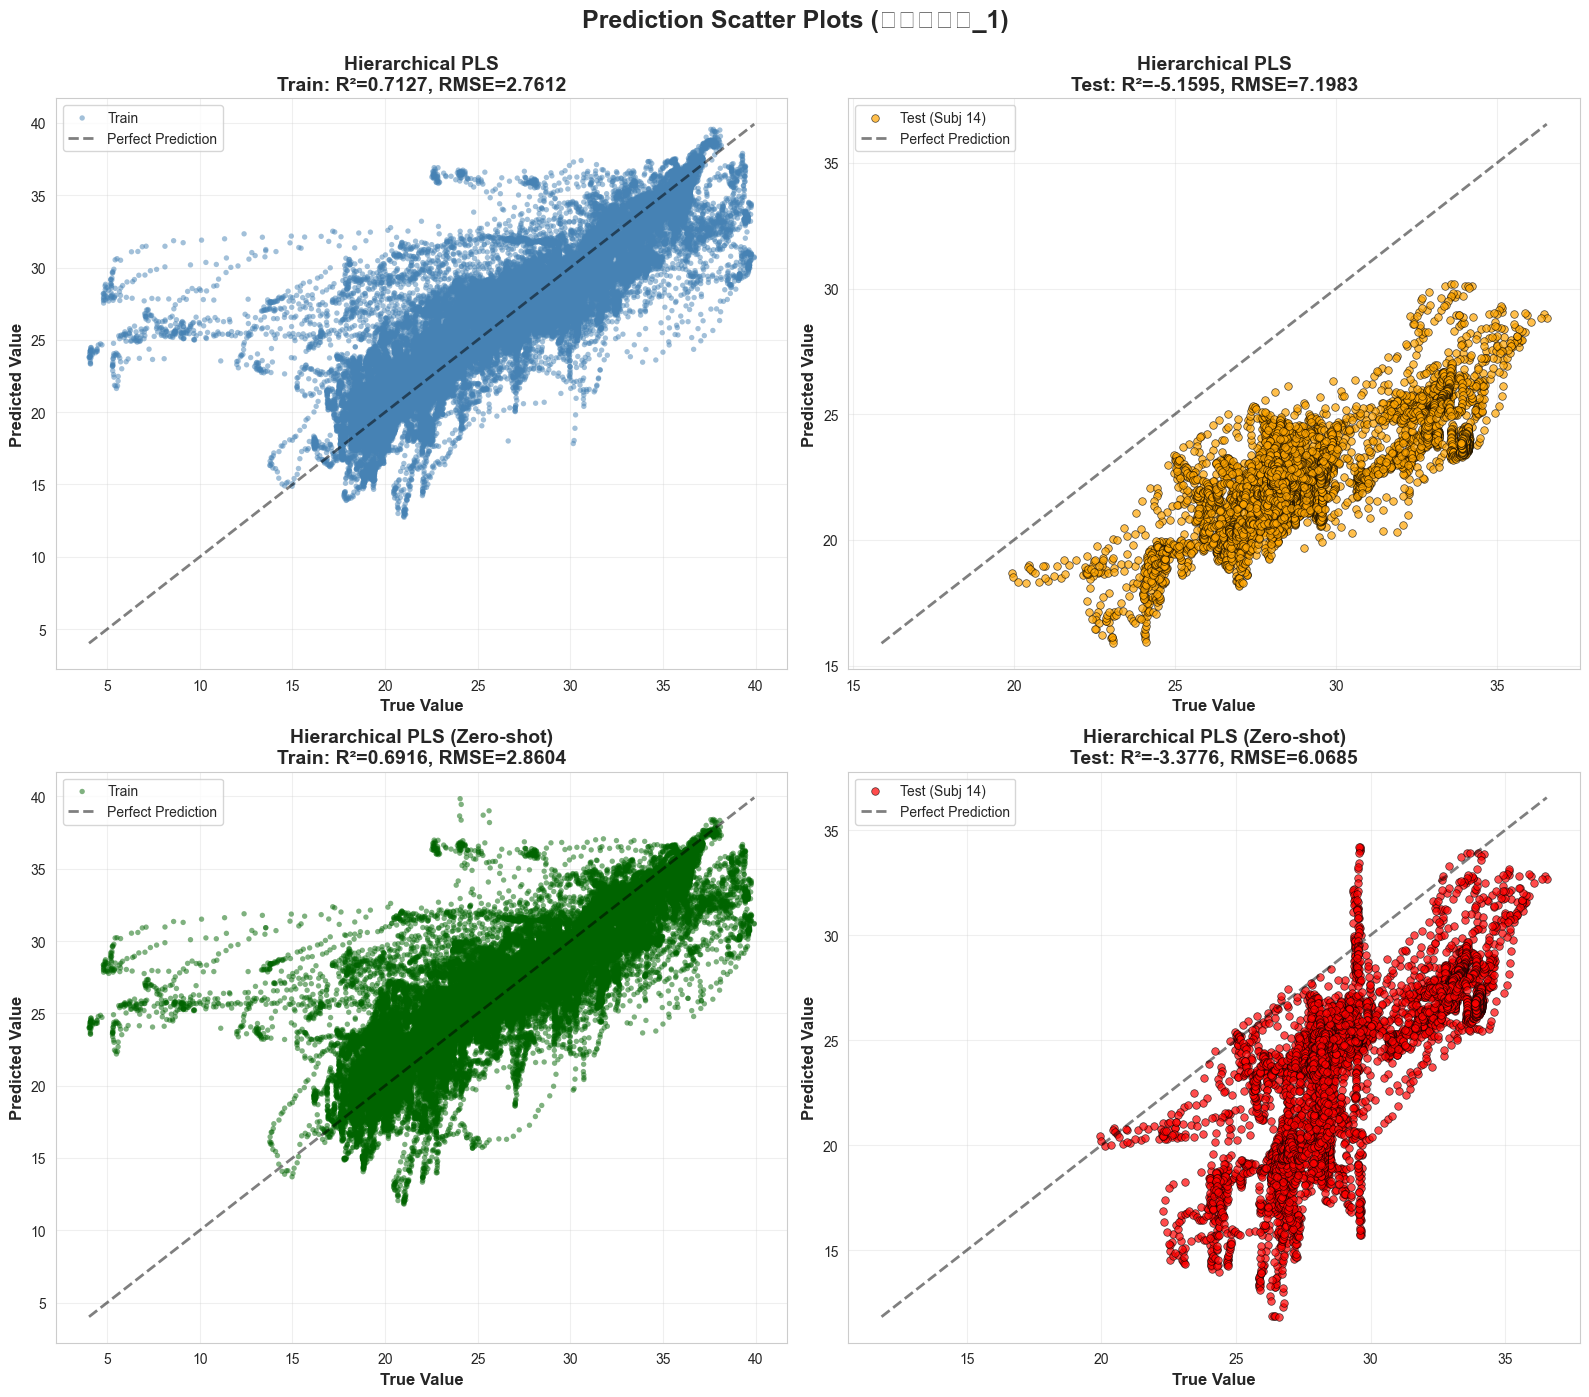

C:\Users\youli\AppData\Local\Temp\ipykernel_7992\611563318.py:249: UserWarning: Glyph 22311 (\N{CJK UNIFIED IDEOGRAPH-5727}) missing from font(s) Arial.
  plt.tight_layout()



📊 Creating time series plot for Subject 14...


C:\Users\youli\AppData\Local\Temp\ipykernel_7992\611563318.py:249: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_7992\611563318.py:249: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_7992\611563318.py:249: UserWarning: Glyph 24515 (\N{CJK UNIFIED IDEOGRAPH-5FC3}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_7992\611563318.py:249: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_7992\611563318.py:250: UserWarning: Glyph 22311 (\N{CJK UNIFIED IDEOGRAPH-5727}) missing from font(s) Arial.
  plt.savefig('zeroshot_vs_default_timeseries.png', dpi=150, bbox_inches='tight')
C:\Users\youli\AppData\Local\Temp\ipykernel_7992\611563318.py:250: Us

✅ Saved: zeroshot_vs_default_timeseries.png


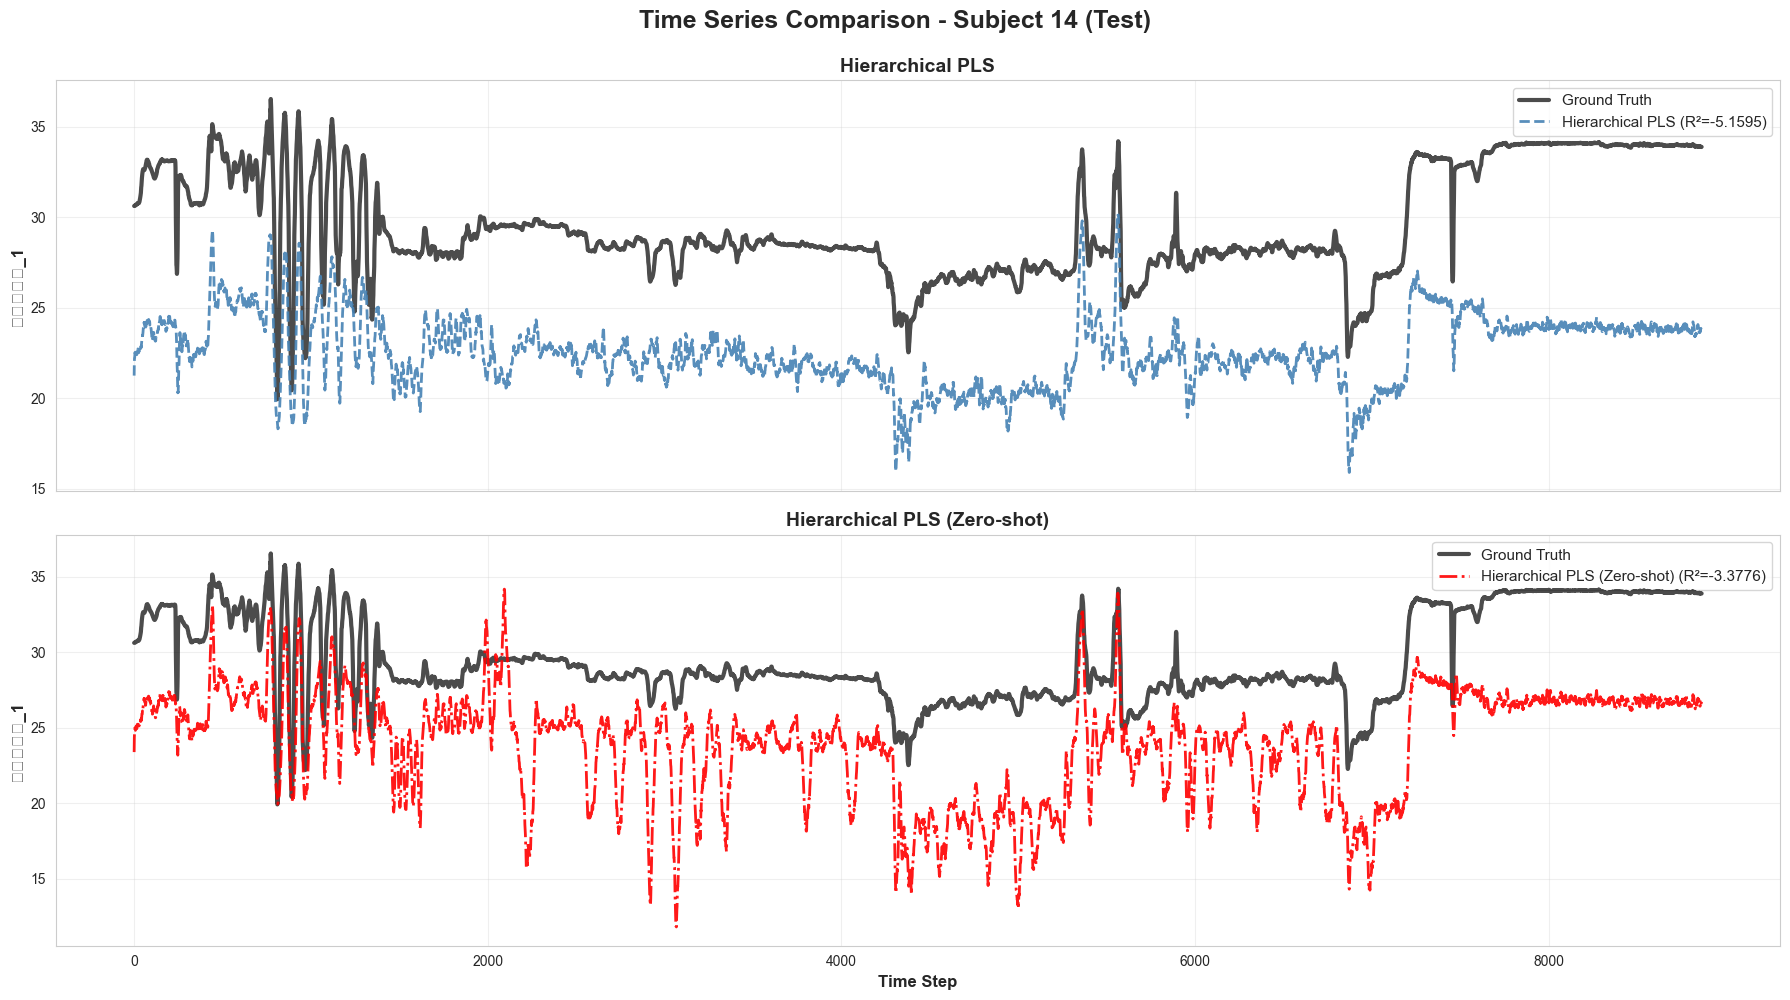


📊 Creating Gain/Offset comparison for Subject 14...

📊 Subject 14 Gain/Offset:
   中央値デフォルト: Gain=1.1249, Offset=-5.2864
   Zero-shot予測:    Gain=1.4260, Offset=-12.8981
✅ Saved: gain_offset_comparison_subject14.png


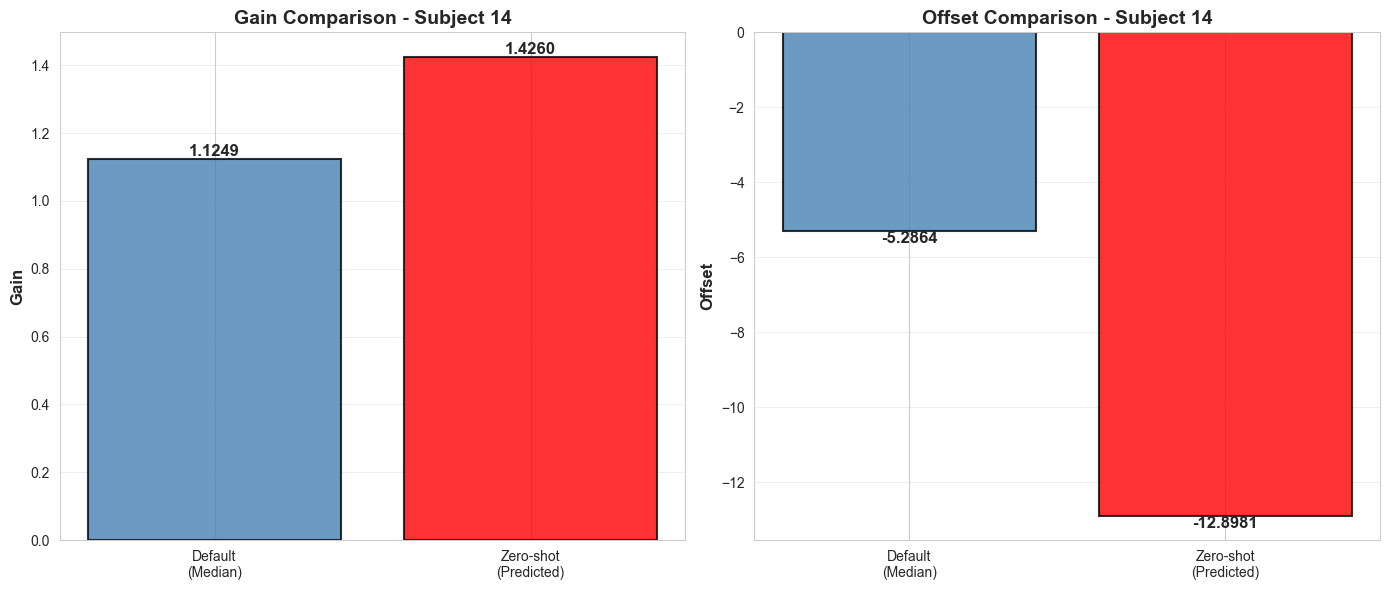


📊 Final Summary

                    Strategy  Train R²  Train RMSE   Test R²  Test RMSE
            Hierarchical PLS  0.712673    2.761168 -5.159480   7.198306
Hierarchical PLS (Zero-shot)  0.691644    2.860426 -3.377645   6.068461

📈 Improvement (Zero-shot vs Default):
   ΔR²:   +1.7818
   ΔRMSE: +1.1298 (negative = worse)

✅ Zero-shot IMPROVED the model by 1.7818 R²!

⚠️  Zero-shot R² is still negative (-3.3776)

📁 Saved: zeroshot_comparison_summary.csv

✅ Visualization Complete!

📁 Output files:
   1. zeroshot_vs_default_scatter.png       - 散布図（Train & Test）
   2. zeroshot_vs_default_timeseries.png    - 時系列（Subject 14）
   3. gain_offset_comparison_subject14.png  - Gain/Offset比較
   4. zeroshot_comparison_summary.csv       - 結果サマリー


In [19]:
"""
Zero-shot vs 中央値デフォルトの詳細比較可視化
圧力中心行_1に特化
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import r2_score, mean_squared_error

# ==========================================
# データ読み込み
# ==========================================

with open(r"C:\Users\youli\Desktop\code\20251118_COPモドキ\20251214home\modelA_df_proc.pkl", "rb") as f:
    df_all = pickle.load(f)

df_all['W_absolute'] = df_all['W']

if 'LR_balance' not in df_all.columns:
    df_all['LR_balance'] = (df_all['F1'] + df_all['F4'] - df_all['F2'] - df_all['F3']) / (df_all['W'] + 1e-8)

if 'FB_balance' not in df_all.columns:
    df_all['FB_balance'] = (df_all['F1'] + df_all['F2'] - df_all['F3'] - df_all['F4']) / (df_all['W'] + 1e-8)

df_all = df_all[~df_all['subject_id'].isin([20,24,25,26,27])].copy()

# 特徴量定義
mock_sensor_cols = [
    'subject_id',
    'F1', 'F2', 'F3', 'F4', 'steer', 'pedal', 'W', 
    'LR_balance', 'FB_balance',
    'F1_fnorm', 'F2_fnorm', 'F3_fnorm', 'F4_fnorm',
    'COP_X_phys', 'COP_Y_phys', 'phys_pitch', 'phys_roll', 'phys_torsion',
    'COP_radius', 'COP_angle', 'op_magnitude', 'interact_steer_pedal',
    'steer_COPx', 'steer_COPy', 'pedal_COPx', 'pedal_COPy',
    'COP_X_phys_vel', 'COP_Y_phys_vel', 'W_vel', 'phys_pitch_vel',
    'phys_roll_vel', 'steer_vel', 'pedal_vel', 'interact_steer_vel_COP',
    'F1_hysteresis', 'F2_hysteresis', 'F3_hysteresis', 'F4_hysteresis',
    'W_hysteresis', 'COP_X_phys_hysteresis', 'COP_Y_phys_hysteresis',
    'Interaction_COPX_W', 'Interaction_COPY_W', 
    'W_Power', 'COP_X_phys_Power', 'COP_Y_phys_Power',
    'COP_X_phys_vel_integ', 'COP_X_phys_vel_ma30', 
    'COP_Y_phys_vel_integ', 'COP_Y_phys_vel_ma30', 
    'W_vel_integ', 'W_vel_ma30',
    'phys_pitch_vel_integ', 'phys_pitch_vel_ma30', 
    'phys_roll_vel_integ', 'phys_roll_vel_ma30',
    'F1_init', 'F2_init', 'F3_init', 'F4_init',
    'W_init', 'LR_balance_init', 'FB_balance_init', 'W_absolute'
]

target_features_A = ['圧力中心行_1']

available_cols = df_all.columns.tolist()
X_cols = [c for c in mock_sensor_cols if c in available_cols]
Y_cols = [c for c in target_features_A if c in available_cols]

df_raw = df_all[X_cols + Y_cols].dropna()
X_raw = df_raw[X_cols]
y_raw = df_raw[Y_cols]

print(f"✅ Data loaded: {len(df_raw)} samples")
print(f"   Target: {target_features_A[0]}")

# ==========================================
# モデル設定
# ==========================================

import my_module4 as mm

SKIP_BIAS_KEYWORDS = [
    'subject_id', '_init', '_vel', '_hysteresis', '_CLR', '_Power', '_absolute'
]+ ['F1', 'F2', 'F3', 'F4', 'W']


# 拡張静的特徴量（すべての_init列）
comparator_temp = mm.ModelComparator(
    [mm.HierarchicalPLSStrategy({'scale_x': False, 'n_components': 10})],
    smooth_y=True,
    skip_bias_cols=SKIP_BIAS_KEYWORDS
)

X_proc_temp = comparator_temp.preprocess_common(X_raw)
STATIC_FEATURES_EXTENDED = [col for col in X_proc_temp.columns if '_init' in col]

print(f"\n📊 Using {len(STATIC_FEATURES_EXTENDED)} extended static features")

# 2つの戦略
strategies = [
    mm.HierarchicalPLSStrategy(
        config={'scale_x': False, 'n_components': 10}
    ),
    mm.HierarchicalPLSStrategyZeroShot(
        name="Hierarchical PLS (Zero-shot)",
        config={'scale_x': False, 'n_components': 10},
        static_features_cols=STATIC_FEATURES_EXTENDED,
        ridge_alpha=1.0
    )
]

# ==========================================
# 前処理と学習・予測
# ==========================================

print("\n" + "="*80)
print("🔬 Training and Predicting")
print("="*80)

comparator = mm.ModelComparator(strategies, smooth_y=False, skip_bias_cols=SKIP_BIAS_KEYWORDS)

X_proc = comparator.preprocess_common(X_raw)
y_target = comparator._get_y_target(y_raw, X_raw, '圧力中心行_1')
subjects = X_raw['subject_id'].values

holdout_subject_id = 14

mask_test = subjects == holdout_subject_id
mask_train = ~mask_test

X_train, X_test = X_proc[mask_train], X_proc[mask_test]
y_train, y_test = y_target[mask_train], y_target[mask_test]
sub_train, sub_test = subjects[mask_train], subjects[mask_test]

print(f"\n📊 Dataset split:")
print(f"   Train: {len(X_train)} samples")
print(f"   Test:  {len(X_test)} samples (Subject {holdout_subject_id})")

# 学習と予測
results = {}

for strategy in strategies:
    print(f"\n   🏃 Training: {strategy.name}...")
    
    strategy.fit(X_train, y_train, sub_train)
    
    # 訓練データでの予測
    y_pred_train = strategy.predict(X_train, sub_train)
    
    # テストデータでの予測
    y_pred_test = strategy.predict(X_test, sub_test)
    
    # 評価指標
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    
    results[strategy.name] = {
        'y_pred_train': y_pred_train,
        'y_pred_test': y_pred_test,
        'r2_train': r2_train,
        'r2_test': r2_test,
        'rmse_train': rmse_train,
        'rmse_test': rmse_test,
    }
    
    print(f"      Train: R² = {r2_train:.4f}, RMSE = {rmse_train:.4f}")
    print(f"      Test:  R² = {r2_test:.4f}, RMSE = {rmse_test:.4f}")

# ==========================================
# 可視化1: 散布図 (Train & Test)
# ==========================================

print("\n📊 Creating scatter plots...")

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

strategy_names = list(results.keys())
colors_train = ['steelblue', 'darkgreen']
colors_test = ['orange', 'red']

for idx, strategy_name in enumerate(strategy_names):
    res = results[strategy_name]
    
    # Train (左列)
    ax = axes[idx, 0]
    ax.scatter(y_train, res['y_pred_train'], 
               s=15, alpha=0.5, color=colors_train[idx], edgecolors='none', label='Train')
    
    min_val = min(y_train.min(), res['y_pred_train'].min())
    max_val = max(y_train.max(), res['y_pred_train'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, alpha=0.5, label='Perfect Prediction')
    
    ax.set_xlabel('True Value', fontsize=12, fontweight='bold')
    ax.set_ylabel('Predicted Value', fontsize=12, fontweight='bold')
    ax.set_title(f'{strategy_name}\nTrain: R²={res["r2_train"]:.4f}, RMSE={res["rmse_train"]:.4f}',
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    
    # Test (右列)
    ax = axes[idx, 1]
    ax.scatter(y_test, res['y_pred_test'],
               s=30, alpha=0.7, color=colors_test[idx], edgecolors='black', linewidths=0.5, 
               label=f'Test (Subj {holdout_subject_id})')
    
    min_val = min(y_test.min(), res['y_pred_test'].min())
    max_val = max(y_test.max(), res['y_pred_test'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, alpha=0.5, label='Perfect Prediction')
    
    ax.set_xlabel('True Value', fontsize=12, fontweight='bold')
    ax.set_ylabel('Predicted Value', fontsize=12, fontweight='bold')
    ax.set_title(f'{strategy_name}\nTest: R²={res["r2_test"]:.4f}, RMSE={res["rmse_test"]:.4f}',
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle('Prediction Scatter Plots (圧力中心行_1)', fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('zeroshot_vs_default_scatter.png', dpi=150, bbox_inches='tight')
print("✅ Saved: zeroshot_vs_default_scatter.png")
plt.show()

# ==========================================
# 可視化2: 時系列 (Test Subject 14 のみ)
# ==========================================

print("\n📊 Creating time series plot for Subject 14...")

fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# Ground Truth
for idx, ax in enumerate(axes):
    ax.plot(y_test, label='Ground Truth', color='black', linewidth=3, alpha=0.7, zorder=10)

# 各戦略の予測
colors = ['steelblue', 'red']
line_styles = ['--', '-.']

for idx, strategy_name in enumerate(strategy_names):
    res = results[strategy_name]
    
    ax = axes[idx]
    ax.plot(res['y_pred_test'], 
            label=f'{strategy_name} (R²={res["r2_test"]:.4f})',
            color=colors[idx], linestyle=line_styles[idx], linewidth=2, alpha=0.9, zorder=11)
    
    ax.set_ylabel('圧力中心行_1', fontsize=12, fontweight='bold')
    ax.set_title(f'{strategy_name}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11, loc='upper right')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Time Step', fontsize=12, fontweight='bold')

plt.suptitle(f'Time Series Comparison - Subject {holdout_subject_id} (Test)', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('zeroshot_vs_default_timeseries.png', dpi=150, bbox_inches='tight')
print("✅ Saved: zeroshot_vs_default_timeseries.png")
plt.show()

# ==========================================
# 可視化3: Gain/Offset 比較（Subject 14）
# ==========================================

print("\n📊 Creating Gain/Offset comparison for Subject 14...")

# Zero-shot戦略からGain/Offsetを取得
zeroshot_strategy = strategies[1]  # HierarchicalPLSStrategyZeroShot
default_strategy = strategies[0]   # HierarchicalPLSStrategy

gain_default = default_strategy.model.subject_gains.get(holdout_subject_id, 
                                                         default_strategy.model.default_gain)
offset_default = default_strategy.model.subject_offsets.get(holdout_subject_id,
                                                             default_strategy.model.default_offset)

gain_zeroshot = zeroshot_strategy.model.subject_gains.get(holdout_subject_id)
offset_zeroshot = zeroshot_strategy.model.subject_offsets.get(holdout_subject_id)

print(f"\n📊 Subject {holdout_subject_id} Gain/Offset:")
print(f"   中央値デフォルト: Gain={gain_default:.4f}, Offset={offset_default:.4f}")
print(f"   Zero-shot予測:    Gain={gain_zeroshot:.4f}, Offset={offset_zeroshot:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gain comparison
ax = axes[0]
methods = ['Default\n(Median)', 'Zero-shot\n(Predicted)']
gains = [gain_default, gain_zeroshot]
colors_bar = ['steelblue', 'red']

bars = ax.bar(methods, gains, color=colors_bar, edgecolor='black', linewidth=1.5, alpha=0.8)
ax.set_ylabel('Gain', fontsize=12, fontweight='bold')
ax.set_title(f'Gain Comparison - Subject {holdout_subject_id}', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

# 値を表示
for bar, val in zip(bars, gains):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# Offset comparison
ax = axes[1]
offsets = [offset_default, offset_zeroshot]

bars = ax.bar(methods, offsets, color=colors_bar, edgecolor='black', linewidth=1.5, alpha=0.8)
ax.set_ylabel('Offset', fontsize=12, fontweight='bold')
ax.set_title(f'Offset Comparison - Subject {holdout_subject_id}', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

# 値を表示
for bar, val in zip(bars, offsets):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}',
            ha='center', va='bottom' if height > 0 else 'top', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('gain_offset_comparison_subject14.png', dpi=150, bbox_inches='tight')
print("✅ Saved: gain_offset_comparison_subject14.png")
plt.show()

# ==========================================
# サマリー表示
# ==========================================

print("\n" + "="*80)
print("📊 Final Summary")
print("="*80)

summary_data = []
for strategy_name, res in results.items():
    summary_data.append({
        'Strategy': strategy_name,
        'Train R²': res['r2_train'],
        'Train RMSE': res['rmse_train'],
        'Test R²': res['r2_test'],
        'Test RMSE': res['rmse_test']
    })

df_summary = pd.DataFrame(summary_data)
print("\n" + df_summary.to_string(index=False))

# 改善度の計算
r2_improvement = results['Hierarchical PLS (Zero-shot)']['r2_test'] - results['Hierarchical PLS']['r2_test']
rmse_improvement = results['Hierarchical PLS']['rmse_test'] - results['Hierarchical PLS (Zero-shot)']['rmse_test']

print(f"\n📈 Improvement (Zero-shot vs Default):")
print(f"   ΔR²:   {r2_improvement:+.4f}")
print(f"   ΔRMSE: {rmse_improvement:+.4f} (negative = worse)")

if r2_improvement > 0:
    print(f"\n✅ Zero-shot IMPROVED the model by {r2_improvement:.4f} R²!")
elif r2_improvement < 0:
    print(f"\n⚠️  Zero-shot made it WORSE by {abs(r2_improvement):.4f} R²")
else:
    print(f"\n➖ No change in R²")

if results['Hierarchical PLS (Zero-shot)']['r2_test'] > 0:
    print(f"\n🎉 SUCCESS! Zero-shot R² is POSITIVE ({results['Hierarchical PLS (Zero-shot)']['r2_test']:.4f})")
else:
    print(f"\n⚠️  Zero-shot R² is still negative ({results['Hierarchical PLS (Zero-shot)']['r2_test']:.4f})")

# 結果保存
df_summary.to_csv('zeroshot_comparison_summary.csv', index=False)
print(f"\n📁 Saved: zeroshot_comparison_summary.csv")

print("\n" + "="*80)
print("✅ Visualization Complete!")
print("="*80)

print("\n📁 Output files:")
print("   1. zeroshot_vs_default_scatter.png       - 散布図（Train & Test）")
print("   2. zeroshot_vs_default_timeseries.png    - 時系列（Subject 14）")
print("   3. gain_offset_comparison_subject14.png  - Gain/Offset比較")
print("   4. zeroshot_comparison_summary.csv       - 結果サマリー")

✅ Data loaded: 79438 samples
   Running Common Preprocessing (X)...

🔍 Diagnosis 1: Scaling Check
   Running Common Preprocessing (X)...
   ✨ Smoothing Target Variable: 圧力中心行_1

📊 Data statistics:
   y_train: mean=27.06, std=5.13, range=[4.07, 39.73]
   y_test:  mean=29.54, std=2.88, range=[20.66, 35.85]

📊 X_dynamic statistics (first 5 features):
   Feature 0: mean=-0.03, std=0.13
   Feature 1: mean=-0.06, std=0.16
   Feature 2: mean=0.02, std=0.12
   Feature 3: mean=0.01, std=0.10
   Feature 4: mean=-1.80, std=69.79

✅ Gain/Offset Predictors Trained:
   - Gain R²: 0.960
   - Offset R²: 0.905

📊 Feature Importance (Coefficients):
Feature                    Gain     Offset
------------------------------------------
F1_init                  0.0101    -0.2188
F2_init                  0.0364    -1.4885
F3_init                  0.0138    -0.9573
F4_init                 -0.0029    -0.1894
steer_init               0.0325    -0.0237
pedal_init              -0.0201     1.3359
W_init           

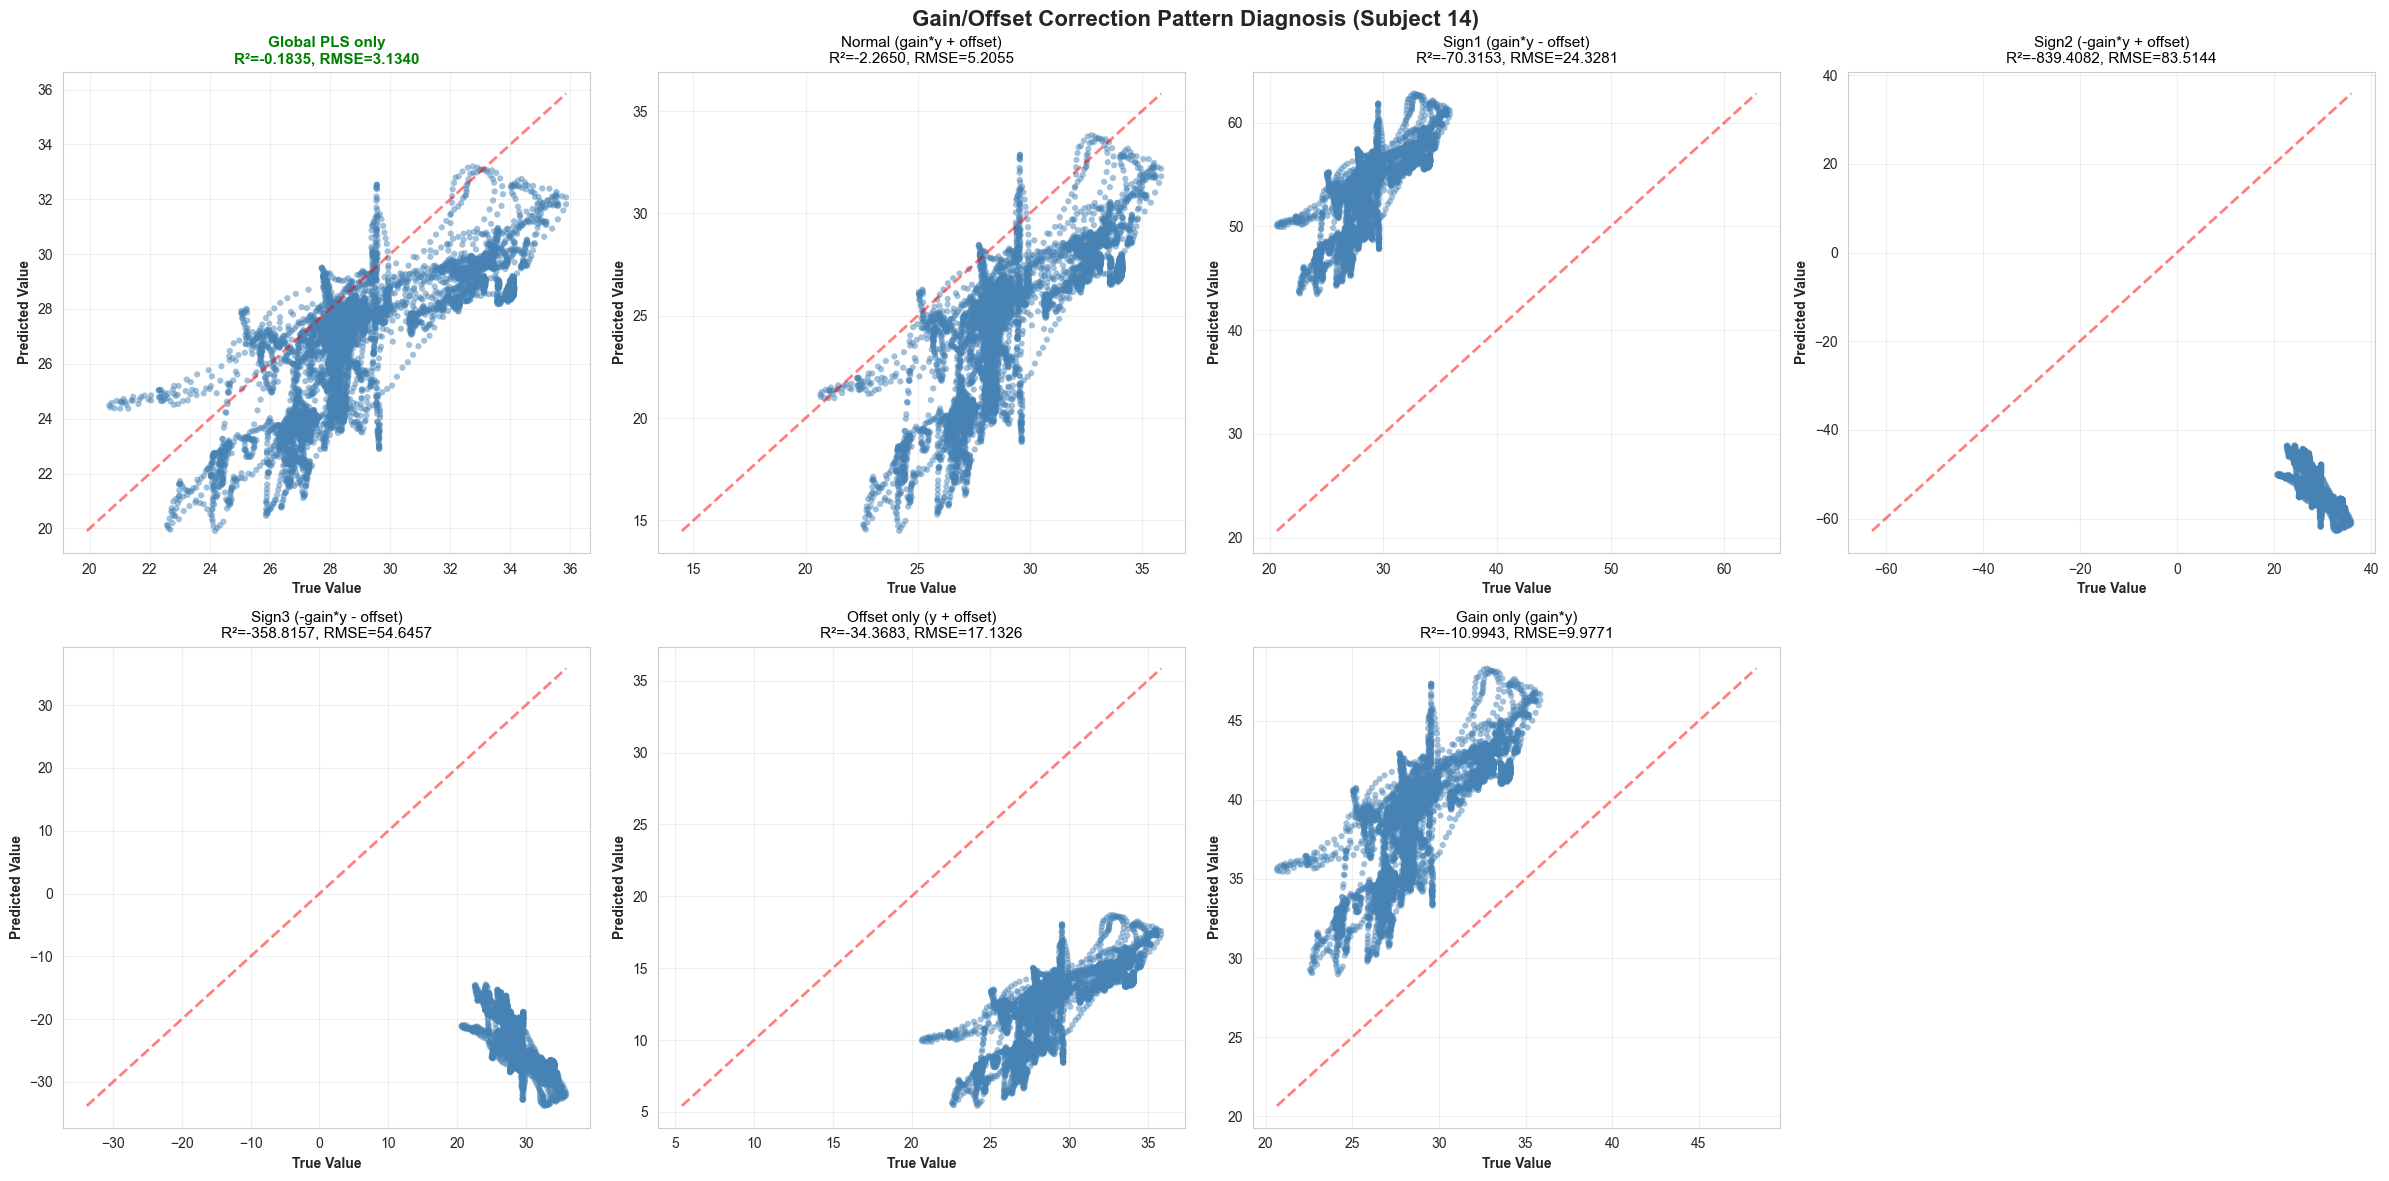


📊 Creating time series comparison...
✅ Saved: gain_offset_timeseries_diagnosis.png


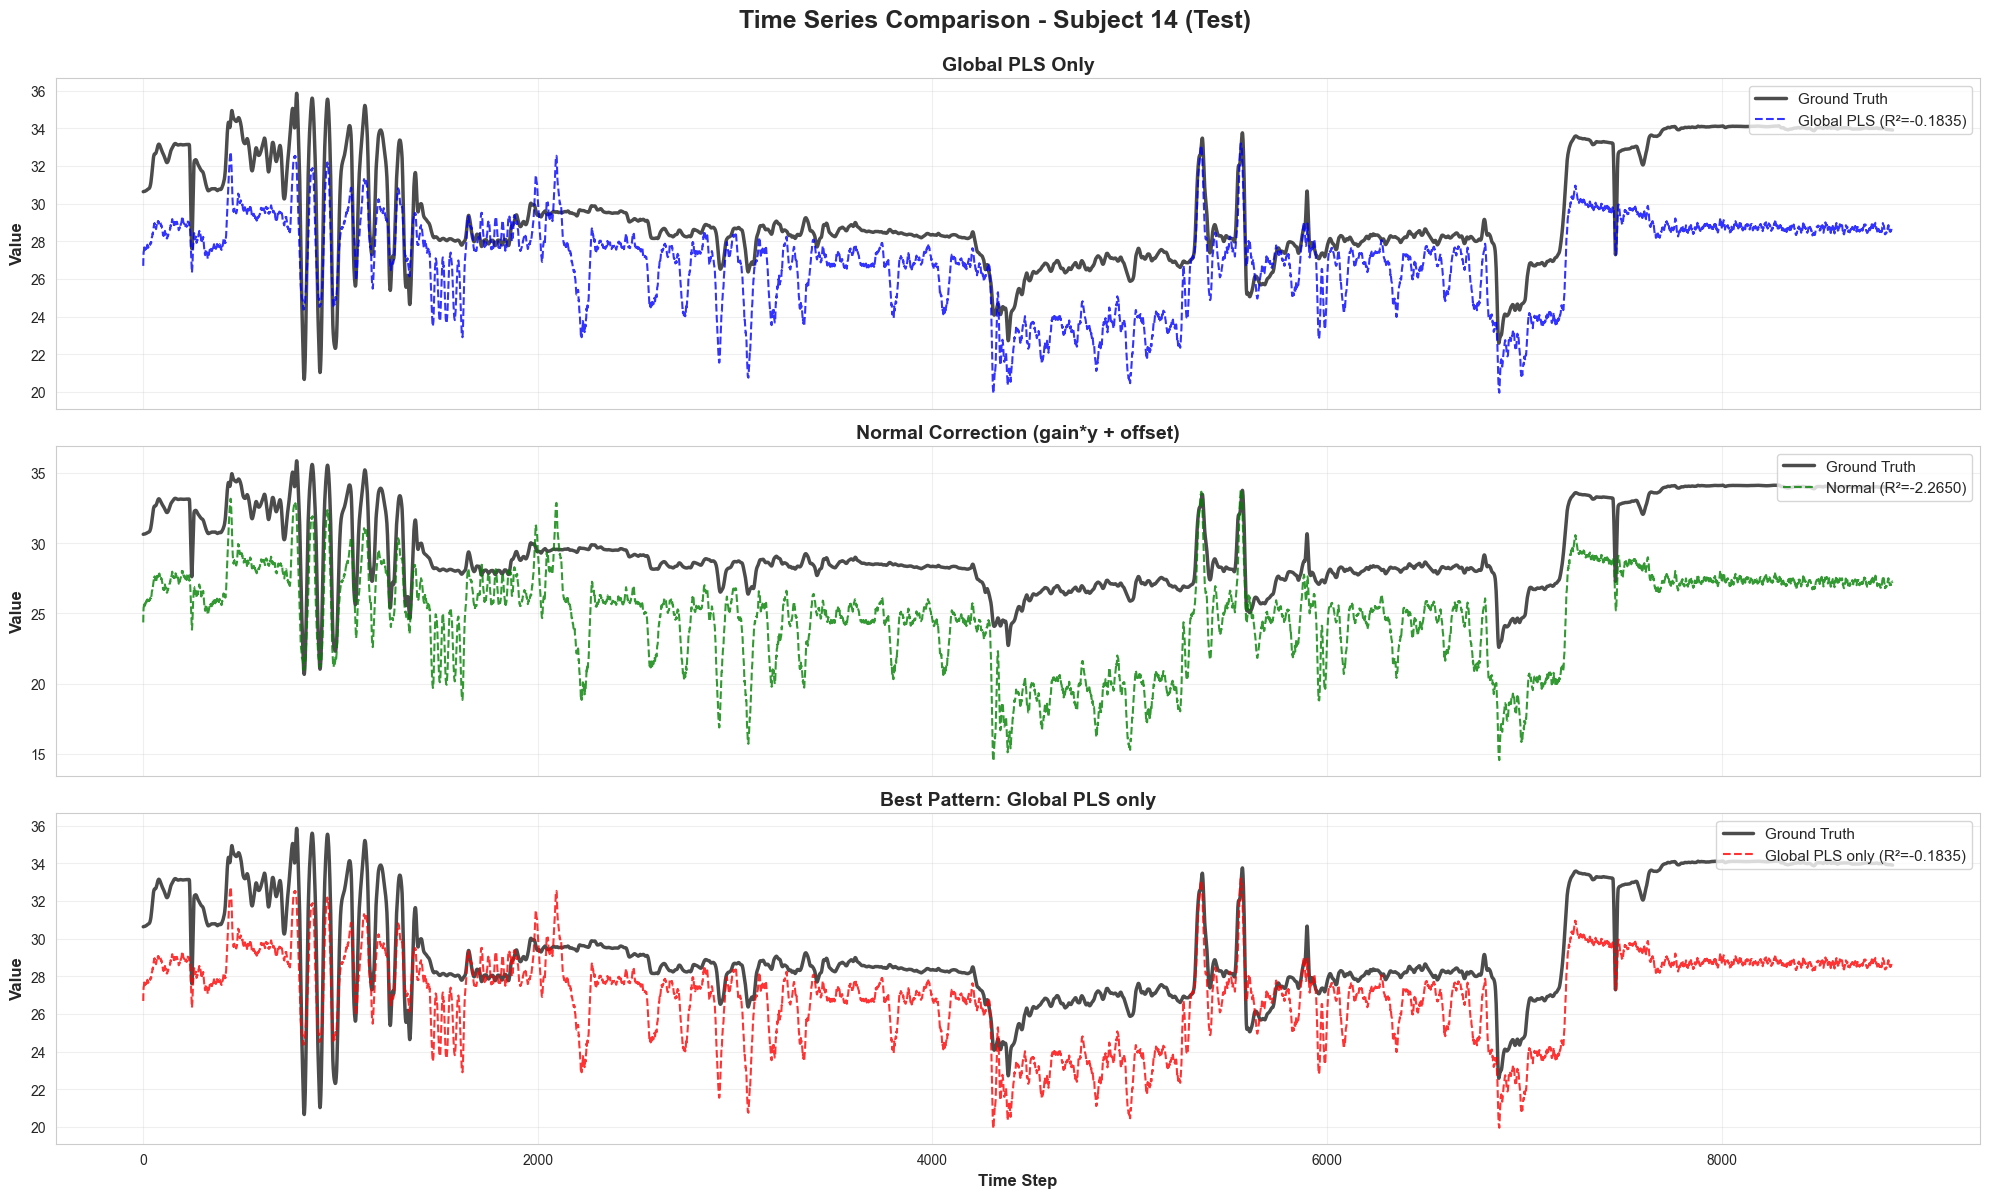


🔍 Diagnosis 7: Scaling Issue Check

📊 Checking y_train vs y_global relationship:

   Subject 12:
      Calculated:  gain=0.7425, offset=11.0386
      Stored:      gain=0.7425, offset=11.0386
      Match: ✅ YES

   Subject 13:
      Calculated:  gain=2.1165, offset=-33.4731
      Stored:      gain=2.1165, offset=-33.4731
      Match: ✅ YES

   Subject 15:
      Calculated:  gain=0.9112, offset=0.8040
      Stored:      gain=0.9112, offset=0.8040
      Match: ✅ YES

   Subject 16:
      Calculated:  gain=1.3191, offset=-7.8751
      Stored:      gain=1.3191, offset=-7.8751
      Match: ✅ YES

   Subject 17:
      Calculated:  gain=1.7833, offset=-17.3597
      Stored:      gain=1.7833, offset=-17.3597
      Match: ✅ YES

📊 Diagnosis Summary

✅ Best correction pattern: Global PLS only
   R² = -0.1835

🚨 ALERT: Best pattern is NOT normal!
   → There might be a sign reversal or scaling issue
   → Check the implementation of gain/offset correction

📁 Output files:
   - gain_offset_pattern_d

In [20]:
"""
ゲイン・オフセット予測の問題診断
スケーリング不整合と符号問題の検証
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import r2_score, mean_squared_error

# ==========================================
# データ読み込み
# ==========================================

with open(r"C:\Users\youli\Desktop\code\20251118_COPモドキ\20251214home\modelA_df_proc.pkl", "rb") as f:
    df_all = pickle.load(f)

df_all['W_absolute'] = df_all['W']

if 'LR_balance' not in df_all.columns:
    df_all['LR_balance'] = (df_all['F1'] + df_all['F4'] - df_all['F2'] - df_all['F3']) / (df_all['W'] + 1e-8)

if 'FB_balance' not in df_all.columns:
    df_all['FB_balance'] = (df_all['F1'] + df_all['F2'] - df_all['F3'] - df_all['F4']) / (df_all['W'] + 1e-8)

df_all = df_all[~df_all['subject_id'].isin([20,24,25,26,27])].copy()

# 特徴量定義
mock_sensor_cols = [
    'subject_id',
    'F1', 'F2', 'F3', 'F4', 'steer', 'pedal', 'W', 
    'LR_balance', 'FB_balance',
    'F1_fnorm', 'F2_fnorm', 'F3_fnorm', 'F4_fnorm',
    'COP_X_phys', 'COP_Y_phys', 'phys_pitch', 'phys_roll', 'phys_torsion',
    'COP_radius', 'COP_angle', 'op_magnitude', 'interact_steer_pedal',
    'steer_COPx', 'steer_COPy', 'pedal_COPx', 'pedal_COPy',
    'COP_X_phys_vel', 'COP_Y_phys_vel', 'W_vel', 'phys_pitch_vel',
    'phys_roll_vel', 'steer_vel', 'pedal_vel', 'interact_steer_vel_COP',
    'F1_hysteresis', 'F2_hysteresis', 'F3_hysteresis', 'F4_hysteresis',
    'W_hysteresis', 'COP_X_phys_hysteresis', 'COP_Y_phys_hysteresis',
    'Interaction_COPX_W', 'Interaction_COPY_W', 
    'W_Power', 'COP_X_phys_Power', 'COP_Y_phys_Power',
    'COP_X_phys_vel_integ', 'COP_X_phys_vel_ma30', 
    'COP_Y_phys_vel_integ', 'COP_Y_phys_vel_ma30', 
    'W_vel_integ', 'W_vel_ma30',
    'phys_pitch_vel_integ', 'phys_pitch_vel_ma30', 
    'phys_roll_vel_integ', 'phys_roll_vel_ma30',
    'F1_init', 'F2_init', 'F3_init', 'F4_init',
    'W_init', 'LR_balance_init', 'FB_balance_init', 'W_absolute'
]

target_features_A = ['圧力中心行_1']

available_cols = df_all.columns.tolist()
X_cols = [c for c in mock_sensor_cols if c in available_cols]
Y_cols = [c for c in target_features_A if c in available_cols]

df_raw = df_all[X_cols + Y_cols].dropna()
X_raw = df_raw[X_cols]
y_raw = df_raw[Y_cols]

print(f"✅ Data loaded: {len(df_raw)} samples")

# ==========================================
# モデル設定
# ==========================================

import my_module4 as mm

SKIP_BIAS_KEYWORDS = [
    'subject_id', '_init', '_vel', '_hysteresis', '_CLR', '_Power', '_absolute'
]

comparator_temp = mm.ModelComparator(
    [mm.HierarchicalPLSStrategy({'scale_x': False, 'n_components': 10})],
    smooth_y=True,
    skip_bias_cols=SKIP_BIAS_KEYWORDS
)

X_proc_temp = comparator_temp.preprocess_common(X_raw)
STATIC_FEATURES_EXTENDED = [col for col in X_proc_temp.columns if '_init' in col]

# ==========================================
# 診断1: スケーリングの確認
# ==========================================

print("\n" + "="*80)
print("🔍 Diagnosis 1: Scaling Check")
print("="*80)

# 前処理実行
comparator = mm.ModelComparator(
    [mm.HierarchicalPLSStrategy({'scale_x': False, 'n_components': 10})],
    smooth_y=True,
    skip_bias_cols=SKIP_BIAS_KEYWORDS
)

X_proc = comparator.preprocess_common(X_raw)
y_target = comparator._get_y_target(y_raw, X_raw, '圧力中心行_1')
subjects = X_raw['subject_id'].values

holdout_subject_id = 14
mask_test = subjects == holdout_subject_id
mask_train = ~mask_test

X_train, X_test = X_proc[mask_train], X_proc[mask_test]
y_train, y_test = y_target[mask_train], y_target[mask_test]
sub_train, sub_test = subjects[mask_train], subjects[mask_test]

# 静的・動的特徴量に分離
available_static = [col for col in STATIC_FEATURES_EXTENDED if col in X_proc.columns]
static_features_train = X_train[available_static].values
static_features_test = X_test[available_static].values

drop_cols = available_static + ['subject_id']
X_dynamic_train = X_train.drop(columns=drop_cols, errors='ignore').values
X_dynamic_test = X_test.drop(columns=drop_cols, errors='ignore').values

print(f"\n📊 Data statistics:")
print(f"   y_train: mean={y_train.mean():.2f}, std={y_train.std():.2f}, range=[{y_train.min():.2f}, {y_train.max():.2f}]")
print(f"   y_test:  mean={y_test.mean():.2f}, std={y_test.std():.2f}, range=[{y_test.min():.2f}, {y_test.max():.2f}]")

print(f"\n📊 X_dynamic statistics (first 5 features):")
for i in range(min(5, X_dynamic_train.shape[1])):
    print(f"   Feature {i}: mean={X_dynamic_train[:, i].mean():.2f}, std={X_dynamic_train[:, i].std():.2f}")

# HierarchicalPLSModelZeroShotで学習
model = mm.HierarchicalPLSModelZeroShot(n_components=10, ridge_alpha=1.0)
model.fit(X_dynamic_train, y_train, sub_train, static_features_train, available_static)

# ==========================================
# 診断2: Global PLSの予測を確認
# ==========================================

print("\n" + "="*80)
print("🔍 Diagnosis 2: Global PLS Prediction")
print("="*80)

# Global PLSのみの予測
y_global_train = model.get_global_prediction(X_dynamic_train)
y_global_test = model.get_global_prediction(X_dynamic_test)

print(f"\n📊 Global PLS predictions:")
print(f"   y_global_train: mean={y_global_train.mean():.2f}, std={y_global_train.std():.2f}, range=[{y_global_train.min():.2f}, {y_global_train.max():.2f}]")
print(f"   y_global_test:  mean={y_global_test.mean():.2f}, std={y_global_test.std():.2f}, range=[{y_global_test.min():.2f}, {y_global_test.max():.2f}]")

r2_global_train = r2_score(y_train, y_global_train)
r2_global_test = r2_score(y_test, y_global_test)

print(f"\n📊 Global PLS R²:")
print(f"   Train: {r2_global_train:.4f}")
print(f"   Test:  {r2_global_test:.4f}")

# ==========================================
# 診断3: Gain/Offsetの確認
# ==========================================

print("\n" + "="*80)
print("🔍 Diagnosis 3: Gain/Offset Analysis")
print("="*80)

# 訓練データの被験者のGain/Offsetを確認
print(f"\n📊 Learned Gain/Offset for training subjects:")
print(f"{'Subject':>10} {'Gain':>10} {'Offset':>10} {'y_true_mean':>12} {'y_global_mean':>14}")
print("-" * 60)

for subj in sorted(model.subject_gains.keys())[:5]:  # 最初の5被験者のみ表示
    mask = (sub_train == subj)
    gain = model.subject_gains[subj]
    offset = model.subject_offsets[subj]
    y_true_mean = y_train[mask].mean()
    y_global_mean = y_global_train[mask].mean()
    
    print(f"{subj:>10} {gain:>10.4f} {offset:>10.4f} {y_true_mean:>12.2f} {y_global_mean:>14.2f}")

# デフォルト値（中央値）
print(f"\n📊 Default Gain/Offset (median):")
print(f"   Gain:   {model.default_gain:.4f}")
print(f"   Offset: {model.default_offset:.4f}")

# Subject 14のZero-shot予測
static_feat_14 = static_features_test.mean(axis=0).reshape(1, -1)
gain_pred_14 = model.gain_predictor.predict(static_feat_14)[0]
offset_pred_14 = model.offset_predictor.predict(static_feat_14)[0]

print(f"\n📊 Subject 14 (Zero-shot prediction):")
print(f"   Gain:   {gain_pred_14:.4f}")
print(f"   Offset: {offset_pred_14:.4f}")

# ==========================================
# 診断4: 手動でGain/Offset適用
# ==========================================

print("\n" + "="*80)
print("🔍 Diagnosis 4: Manual Gain/Offset Application")
print("="*80)

# パターン1: 正常（gain * y + offset）
y_corrected_normal = gain_pred_14 * y_global_test + offset_pred_14

# パターン2: 符号反転の可能性1（gain * y - offset）
y_corrected_sign1 = gain_pred_14 * y_global_test - offset_pred_14

# パターン3: 符号反転の可能性2（-gain * y + offset）
y_corrected_sign2 = -gain_pred_14 * y_global_test + offset_pred_14

# パターン4: 完全反転（-gain * y - offset）
y_corrected_sign3 = -gain_pred_14 * y_global_test - offset_pred_14

# パターン5: offset のみ（gain=1）
y_corrected_offset_only = y_global_test + offset_pred_14

# パターン6: gain のみ（offset=0）
y_corrected_gain_only = gain_pred_14 * y_global_test

patterns = {
    'Global PLS only': y_global_test,
    'Normal (gain*y + offset)': y_corrected_normal,
    'Sign1 (gain*y - offset)': y_corrected_sign1,
    'Sign2 (-gain*y + offset)': y_corrected_sign2,
    'Sign3 (-gain*y - offset)': y_corrected_sign3,
    'Offset only (y + offset)': y_corrected_offset_only,
    'Gain only (gain*y)': y_corrected_gain_only,
}

print(f"\n📊 Testing different correction patterns:")
print(f"{'Pattern':<30} {'R²':>10} {'RMSE':>10} {'Mean':>10} {'Std':>10}")
print("-" * 70)

best_r2 = float('-inf')
best_pattern = None

for name, y_pred in patterns.items():
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mean = y_pred.mean()
    std = y_pred.std()
    
    marker = "  ← BEST" if r2 > best_r2 else ""
    if r2 > best_r2:
        best_r2 = r2
        best_pattern = name
    
    print(f"{name:<30} {r2:>10.4f} {rmse:>10.4f} {mean:>10.2f} {std:>10.2f}{marker}")

print(f"\n✅ Best pattern: {best_pattern} (R² = {best_r2:.4f})")

# ==========================================
# 診断5: 可視化
# ==========================================

print("\n📊 Creating diagnostic plots...")

fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

for idx, (name, y_pred) in enumerate(patterns.items()):
    ax = axes[idx]
    
    # 散布図
    ax.scatter(y_test, y_pred, s=20, alpha=0.5, color='steelblue', edgecolors='none')
    
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, alpha=0.5)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    color = 'green' if name == best_pattern else 'black'
    weight = 'bold' if name == best_pattern else 'normal'
    
    ax.set_xlabel('True Value', fontsize=10, fontweight='bold')
    ax.set_ylabel('Predicted Value', fontsize=10, fontweight='bold')
    ax.set_title(f'{name}\nR²={r2:.4f}, RMSE={rmse:.4f}', 
                 fontsize=11, fontweight=weight, color=color)
    ax.grid(alpha=0.3)

# 余ったサブプロットを非表示
for j in range(len(patterns), len(axes)):
    axes[j].axis('off')

plt.suptitle('Gain/Offset Correction Pattern Diagnosis (Subject 14)', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('gain_offset_pattern_diagnosis.png', dpi=150, bbox_inches='tight')
print("✅ Saved: gain_offset_pattern_diagnosis.png")
plt.show()

# ==========================================
# 診断6: 時系列比較
# ==========================================

print("\n📊 Creating time series comparison...")

fig, axes = plt.subplots(3, 1, figsize=(20, 12), sharex=True)

# 上段: Global PLS vs True
ax = axes[0]
ax.plot(y_test, label='Ground Truth', color='black', linewidth=2.5, alpha=0.7)
ax.plot(y_global_test, label=f'Global PLS (R²={r2_global_test:.4f})', 
        color='blue', linestyle='--', linewidth=1.5, alpha=0.8)
ax.set_ylabel('Value', fontsize=12, fontweight='bold')
ax.set_title('Global PLS Only', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(alpha=0.3)

# 中段: Normal correction vs True
ax = axes[1]
ax.plot(y_test, label='Ground Truth', color='black', linewidth=2.5, alpha=0.7)
ax.plot(patterns['Normal (gain*y + offset)'], 
        label=f'Normal (R²={r2_score(y_test, patterns["Normal (gain*y + offset)"]):.4f})', 
        color='green', linestyle='--', linewidth=1.5, alpha=0.8)
ax.set_ylabel('Value', fontsize=12, fontweight='bold')
ax.set_title('Normal Correction (gain*y + offset)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(alpha=0.3)

# 下段: Best pattern vs True
ax = axes[2]
ax.plot(y_test, label='Ground Truth', color='black', linewidth=2.5, alpha=0.7)
ax.plot(patterns[best_pattern], 
        label=f'{best_pattern} (R²={best_r2:.4f})', 
        color='red', linestyle='--', linewidth=1.5, alpha=0.8)
ax.set_ylabel('Value', fontsize=12, fontweight='bold')
ax.set_xlabel('Time Step', fontsize=12, fontweight='bold')
ax.set_title(f'Best Pattern: {best_pattern}', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(alpha=0.3)

plt.suptitle('Time Series Comparison - Subject 14 (Test)', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('gain_offset_timeseries_diagnosis.png', dpi=150, bbox_inches='tight')
print("✅ Saved: gain_offset_timeseries_diagnosis.png")
plt.show()

# ==========================================
# 診断7: スケーリング問題のチェック
# ==========================================

print("\n" + "="*80)
print("🔍 Diagnosis 7: Scaling Issue Check")
print("="*80)

# y_trainとy_globalの関係を確認（全訓練データ）
print(f"\n📊 Checking y_train vs y_global relationship:")

# 各被験者のy_trueとy_globalの相関
for subj in sorted(model.subject_gains.keys())[:5]:
    mask = (sub_train == subj)
    y_true_s = y_train[mask]
    y_global_s = y_global_train[mask]
    
    # 回帰で gain/offset を計算
    A = np.column_stack([y_global_s, np.ones(len(y_global_s))])
    params = np.linalg.lstsq(A, y_true_s, rcond=None)[0]
    gain_calc = params[0]
    offset_calc = params[1]
    
    # 保存されている gain/offset
    gain_stored = model.subject_gains[subj]
    offset_stored = model.subject_offsets[subj]
    
    print(f"\n   Subject {subj}:")
    print(f"      Calculated:  gain={gain_calc:.4f}, offset={offset_calc:.4f}")
    print(f"      Stored:      gain={gain_stored:.4f}, offset={offset_stored:.4f}")
    print(f"      Match: {'✅ YES' if np.isclose(gain_calc, gain_stored, rtol=0.01) else '❌ NO'}")

# ==========================================
# サマリー
# ==========================================

print("\n" + "="*80)
print("📊 Diagnosis Summary")
print("="*80)

print(f"\n✅ Best correction pattern: {best_pattern}")
print(f"   R² = {best_r2:.4f}")

if best_pattern == 'Normal (gain*y + offset)':
    print(f"\n✅ Good news: Normal pattern works best!")
    print(f"   → No sign reversal issue")
    print(f"   → Scaling seems consistent")
    print(f"\n⚠️  But R² is still negative ({best_r2:.4f})")
    print(f"   → Problem is NOT in gain/offset application")
    print(f"   → Problem is in Global PLS prediction quality")
else:
    print(f"\n🚨 ALERT: Best pattern is NOT normal!")
    print(f"   → There might be a sign reversal or scaling issue")
    print(f"   → Check the implementation of gain/offset correction")

print("\n📁 Output files:")
print("   - gain_offset_pattern_diagnosis.png")
print("   - gain_offset_timeseries_diagnosis.png")

In [21]:
import my_module4 as mm4  # 上記を保存したファイル

# ------------------------------------------------
# 戦略の定義 (Zero-shot版を使う)
# ------------------------------------------------

# 静的特徴量のリスト (全_init列など)
STATIC_FEATURES_EXTENDED = [col for col in X_proc.columns if '_init' in col]

strategies = [
    # 比較対象: 通常のHierarchical (未知の人は平均値になる)
    mm.HierarchicalPLSStrategy(
        config={'scale_x': False, 'n_components': 10}
    ),
    
    # 本命: Zero-shot版 (未知の人を静的特徴量から推定)
    mm4.HierarchicalPLSStrategyZeroShot(
        name="Hierarchical PLS (Zero-shot)",
        config={'scale_x': False, 'n_components': 10},
        static_features_cols=STATIC_FEATURES_EXTENDED, # ここに重要な静的特徴量を渡す
        ridge_alpha=1.0
    )
]

# ------------------------------------------------
# 実行 (Comparatorは既存のままでOK)
# ------------------------------------------------
comparator = mm.ModelComparator(strategies, smooth_y=False, skip_bias_cols=SKIP_BIAS_KEYWORDS)

results = comparator.run_comparison(
    X_raw, 
    y_raw, 
    target_col=target_features_A, 
    holdout_subject_id=14  # 未知の被験者
)


🥊 Comparison Start: Target = 圧力中心行_1
   Running Common Preprocessing (X)...
   Train: 70571 samples, Test: 8867 samples (Subject 14)
   🏃 Running: Hierarchical PLS...
      -> R2: -4.1499 (N=None)
   🏃 Running: Hierarchical PLS (Zero-shot)...
   🏃 Running: Hierarchical PLS (Zero-shot)...
      Dynamic features: 47 columns
      Static features: 47 columns

✅ Gain/Offset Predictors Trained:
   - Gain R²: 0.959
   - Offset R²: 0.903

📊 Feature Importance (Coefficients):
Feature                    Gain     Offset
------------------------------------------
F1_init                  0.0088    -0.1837
F2_init                  0.0355    -1.4641
F3_init                  0.0135    -0.9490
F4_init                 -0.0036    -0.1709
steer_init               0.0323    -0.0251
pedal_init              -0.0220     1.3859
W_init                   0.0542    -2.7677
LR_balance_init         -0.0191     0.8734
FB_balance_init          0.0506    -1.3753
F1_fnorm_init            0.0067    -0.0618
F2_fnorm_i

📊 Visualizing Comparison for Subject 14...
   Running Common Preprocessing (X)...
   🏃 Predicting with: Hierarchical PLS...
   🏃 Predicting with: Hierarchical PLS (Zero-shot)...
   🏃 Running: Hierarchical PLS (Zero-shot)...
      Dynamic features: 47 columns
      Static features: 47 columns

✅ Gain/Offset Predictors Trained:
   - Gain R²: 0.959
   - Offset R²: 0.903

📊 Feature Importance (Coefficients):
Feature                    Gain     Offset
------------------------------------------
F1_init                  0.0088    -0.1837
F2_init                  0.0355    -1.4641
F3_init                  0.0135    -0.9490
F4_init                 -0.0036    -0.1709
steer_init               0.0323    -0.0251
pedal_init              -0.0220     1.3859
W_init                   0.0542    -2.7677
LR_balance_init         -0.0191     0.8734
FB_balance_init          0.0506    -1.3753
F1_fnorm_init            0.0067    -0.0618
F2_fnorm_init            0.0186    -0.6258
F3_fnorm_init           -0.0091  

C:\Users\youli\AppData\Local\Temp\ipykernel_7992\705139234.py:75: UserWarning: Glyph 22311 (\N{CJK UNIFIED IDEOGRAPH-5727}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_7992\705139234.py:75: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_7992\705139234.py:75: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_7992\705139234.py:75: UserWarning: Glyph 24515 (\N{CJK UNIFIED IDEOGRAPH-5FC3}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_7992\705139234.py:75: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\youli\Desktop\code\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22311 (\N{CJK UNIFIED IDEOGRAPH-

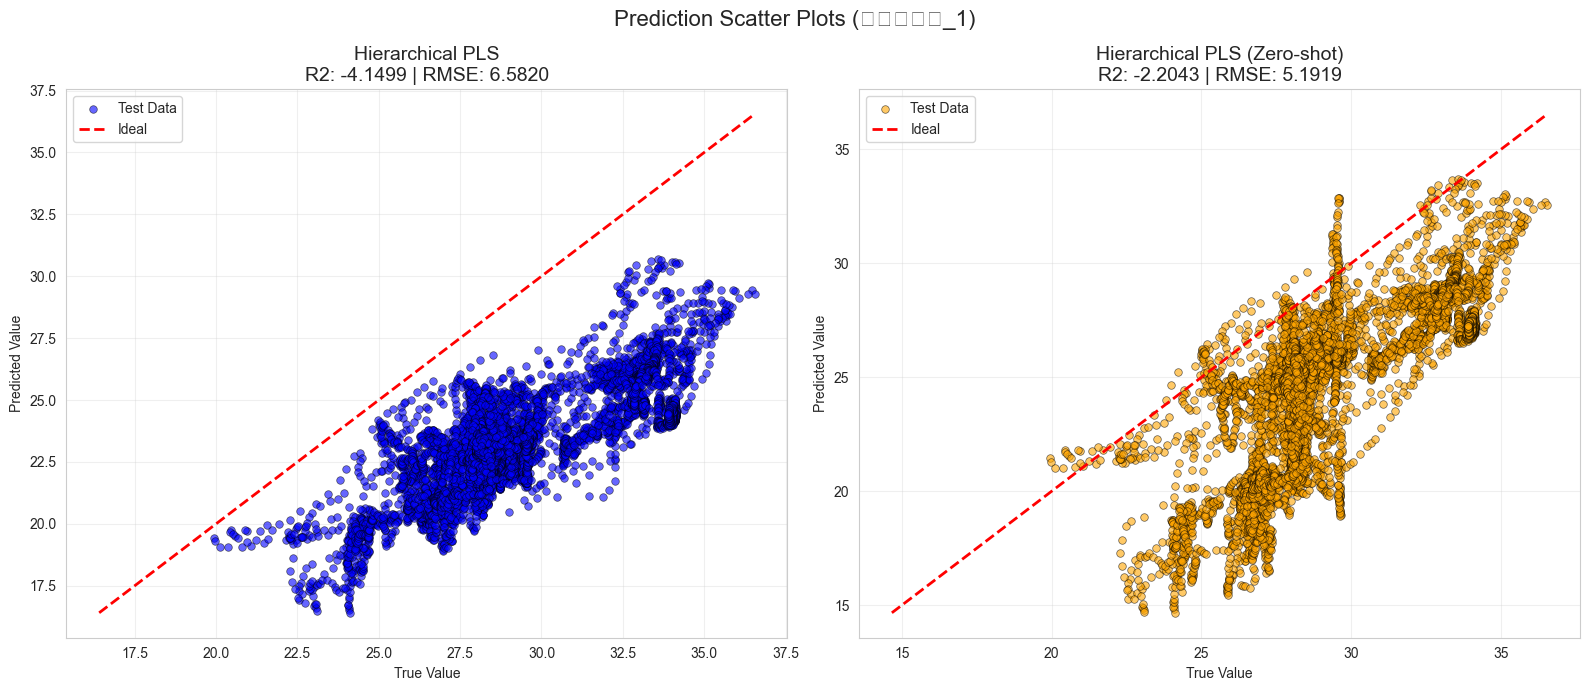

C:\Users\youli\AppData\Local\Temp\ipykernel_7992\705139234.py:100: UserWarning: Glyph 22311 (\N{CJK UNIFIED IDEOGRAPH-5727}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_7992\705139234.py:100: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_7992\705139234.py:100: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_7992\705139234.py:100: UserWarning: Glyph 24515 (\N{CJK UNIFIED IDEOGRAPH-5FC3}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_7992\705139234.py:100: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) Arial.
  plt.tight_layout()


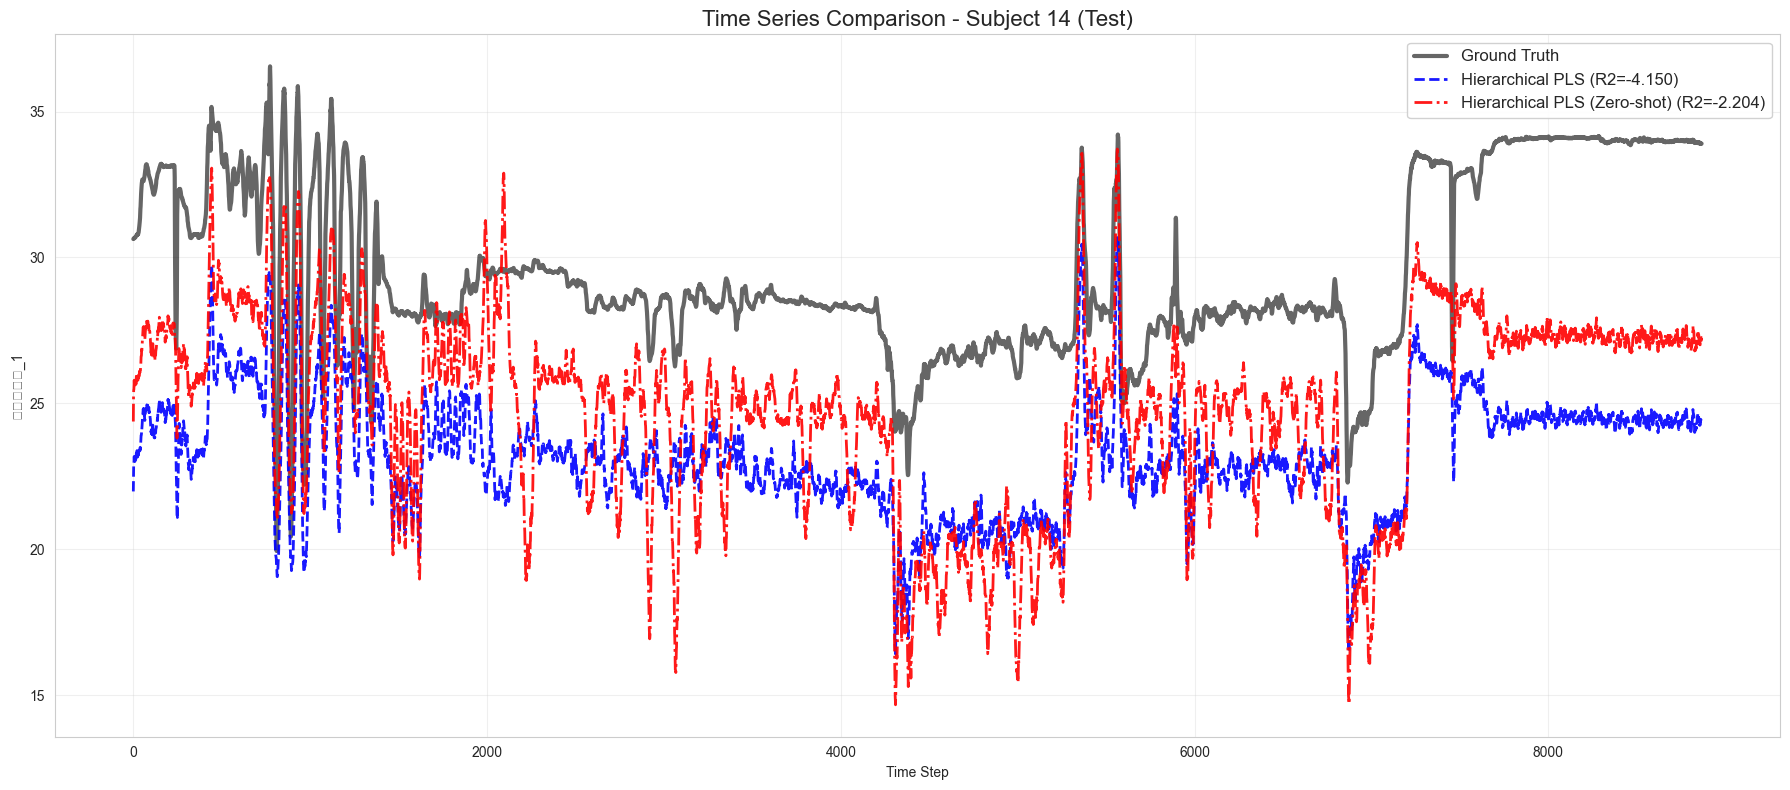

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error

def visualize_zeroshot_comparison(strategies, comparator, X_raw, y_raw, target_col, holdout_subject_id):
    """
    Zero-shotモデルと通常モデルの予測結果を比較可視化する関数
    """
    print(f"📊 Visualizing Comparison for Subject {holdout_subject_id}...")
    
    # -------------------------------------------------
    # 1. データ準備 (再取得)
    # -------------------------------------------------
    X_proc = comparator.preprocess_common(X_raw)
    y_target = comparator._get_y_target(y_raw, X_raw, target_col)
    subjects = X_raw['subject_id'].values
    
    # Train/Test Split
    mask_test = subjects == holdout_subject_id
    mask_train = ~mask_test
    
    X_train, X_test = X_proc[mask_train], X_proc[mask_test]
    y_train, y_test = y_target[mask_train], y_target[mask_test]
    sub_train, sub_test = subjects[mask_train], subjects[mask_test]
    
    # -------------------------------------------------
    # 2. 推論実行 & 結果格納
    # -------------------------------------------------
    results = {}
    
    for strategy in strategies:
        print(f"   🏃 Predicting with: {strategy.name}...")
        strategy.fit(X_train, y_train, sub_train)
        
        # Testデータに対する予測
        y_pred = strategy.predict(X_test, sub_test)
        
        # 評価スコア
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        results[strategy.name] = {
            'y_pred': y_pred,
            'r2': r2,
            'rmse': rmse
        }

    # -------------------------------------------------
    # 3. プロット作成
    # -------------------------------------------------
    
    # --- A. 散布図 (Scatter Plot) ---
    fig_sc, axes_sc = plt.subplots(1, 2, figsize=(16, 7))
    
    for i, (name, res) in enumerate(results.items()):
        ax = axes_sc[i] if i < 2 else axes_sc[-1] # 2つ以上ある場合は適宜
        
        # 散布図
        ax.scatter(y_test, res['y_pred'], alpha=0.6, s=30, 
                   color='orange' if 'Zero-shot' in name else 'blue', 
                   edgecolor='black', linewidth=0.5, label='Test Data')
        
        # 理想線
        min_val = min(y_test.min(), res['y_pred'].min())
        max_val = max(y_test.max(), res['y_pred'].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal')
        
        ax.set_title(f"{name}\nR2: {res['r2']:.4f} | RMSE: {res['rmse']:.4f}", fontsize=14)
        ax.set_xlabel("True Value")
        ax.set_ylabel("Predicted Value")
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.suptitle(f"Prediction Scatter Plots ({target_col})", fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # --- B. 時系列波形 (Time Series) ---
    plt.figure(figsize=(18, 8))
    
    # True
    plt.plot(y_test, label='Ground Truth', color='black', linewidth=3, alpha=0.6)
    
    # Predictions
    colors = ['blue', 'red', 'green']
    line_styles = ['--', '-.', ':']
    
    for i, (name, res) in enumerate(results.items()):
        plt.plot(res['y_pred'], 
                 label=f"{name} (R2={res['r2']:.3f})", 
                 color=colors[i % len(colors)], 
                 linestyle=line_styles[i % len(line_styles)],
                 linewidth=2, alpha=0.9)
        
    plt.title(f"Time Series Comparison - Subject {holdout_subject_id} (Test)", fontsize=16)
    plt.xlabel("Time Step")
    plt.ylabel(target_col)
    plt.legend(fontsize=12, loc='upper right', framealpha=0.9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ==========================================
# 実行
# ==========================================
visualize_zeroshot_comparison(
    strategies,        # 定義済みの戦略リスト
    comparator,        # 定義済みのcomparator (前処理用)
    X_raw, 
    y_raw, 
    target_col=target_features_A[0], 
    holdout_subject_id=14
)